## Initialize

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shutil

sns.reset_defaults()
# matplotlib.use("Agg")
if shutil.which("latex"):
    matplotlib.rc("text", usetex=True)
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "dejavuserif"
plt.rcParams["figure.autolayout"] = True


global_palette = ["#166135","#50b9aa","#0d5a9b","#6a77ac","#322051","#c24135","#aa602d","#eea86f","#c56f9c","#cd552e","#ebde4e","#96235d","#2caf91","#f8b68a","#c0e3df","#000000","#662b3d","#eb3882","#1a8e7c","#a89351","#a6cf79","#f6d761","#50abde",]

global_marker = ["o", "v", "^", "<", ">", "s", "p", "P", "*", "h", "H", "D", "d"]

plot_root = "plots"
os.makedirs(plot_root, exist_ok=True)

In [2]:
import pyvista
def get_phi_x_max(path, crack_tip:float, cycle_per_file=10, ylim = None, infer_cycle_by_name=False, direction="right", read_every=1):
    from tqdm.auto import tqdm
    pvtus = [x for x in os.listdir(path) if ".pvtu" in x]
    sort_key = lambda x: int(os.path.splitext(x)[0].split("_")[-1])
    pvtus = list(sorted(pvtus, key=sort_key))
    pvtus = pvtus[0:-1:read_every] + [pvtus[-1]]
    thres = 0.95
    n_cycles = []
    crack_lengths = []

    bar = tqdm(total=len(pvtus))
    for i, pvtu_name in enumerate(pvtus):
        if not infer_cycle_by_name:
            i_cycle = cycle_per_file * i * read_every
        else:
            i_cycle = int(pvtu_name.split(".pvtu")[0].split("_")[-1])
        
        mesh = pyvista.read(os.path.join(path, pvtu_name))
        
        points = mesh.points
        try:
            phasefield = mesh.get_array("Phase_field")
        except:
            print(f"Phase field not found in {pvtu_name}")
            continue
        above_thres = np.where(phasefield>thres)[0]
        if ylim is not None:
            within_range = np.intersect1d(np.where(points[:, 1]<ylim[1])[0], np.where(points[:, 1]>ylim[0])[0])
            # print(points[within_range])
            above_thres = np.intersect1d(within_range, above_thres)
        if len(above_thres) == 0:
            crack_lengths.append(0)
            n_cycles.append(i_cycle)
            bar.update(1)
            continue
        else:
            crack_points = points[above_thres]
            order_func = (np.argmax if direction in ["right", "up"] else np.argmin)
            order_idx = (0 if direction in ["right", "left"] else 1)
            compare_func = (np.greater if direction in ["right", "up"] else np.less)
            arg = order_func(crack_points[:, order_idx])
            selected_point = points[above_thres[arg], :]
            selected_point_phasefield = phasefield[above_thres[arg]]
            selected_point_pos = points[above_thres[arg], order_idx]
            other_points_idx = np.intersect1d(np.where(points[:, order_idx]!=selected_point[order_idx])[0], np.where(compare_func(points[:, order_idx],selected_point[order_idx]))[0])
            other_points = points[other_points_idx, :]
            nearest_points_idx = np.argsort(np.sqrt(np.sum((other_points - selected_point)**2, axis=1)))[:10]
            try:
                next_point_idx = other_points_idx[nearest_points_idx[order_func(other_points[nearest_points_idx, order_idx])]]
            except:
                print("Reaching the end of the mesh.")
                continue
            next_point_phasefield = phasefield[next_point_idx]
            next_point_pos = points[next_point_idx, order_idx]
            # print(selected_point_pos, next_point_pos)
            length = selected_point_pos-crack_tip + (0.95-selected_point_phasefield)*(next_point_pos-selected_point_pos)/(next_point_phasefield-selected_point_phasefield)
            crack_lengths.append(length)
            n_cycles.append(i_cycle)
            # print(pvtu_name, points[above_thres], np.max(crack_points[:, 0]))
            bar.update(1)
            bar.set_description(f"Crack length = {crack_lengths[-1]}")
        # bar.set_description(f"Crack length = {crack_lengths[-1]}")
    return n_cycles, crack_lengths


import pyvista
def get_cell_value(path, cell_id, field_name):
    from tqdm.auto import tqdm
    pvtus = [x for x in os.listdir(path) if ".pvtu" in x]
    sort_key = lambda x: int(os.path.splitext(x)[0].split("_")[-1])
    pvtus = list(sorted(pvtus, key=sort_key))
    values = []

    bar = tqdm(total=len(pvtus))
    for i, pvtu_name in enumerate(pvtus):
        mesh = pyvista.read(os.path.join(path, pvtu_name))
        field = mesh.get_array(field_name)
        cell = mesh.get_cell(cell_id)
        cell_points = cell.point_ids
        # print(i, field[cell_points])
        values.append(np.mean(field[cell_points]))
        bar.update(1)
        bar.set_description(f"{field_name}={values[-1]}")
    return values

def incremental_growth(n_cycles, crack_lengths, delta_p, T, W):
    Y = lambda x: (2+x)/(np.power(1-x, 3/2))*(0.886+4.64*x-13.32*x**2+14.72*x**3-5.6*x**4)
    recorded_cycle = []
    lengths = []
    da_dn = []
    delta_k = []
    accumulated_da = 0
    accumulated_dn = 0
    for i in range(1, len(crack_lengths)):
        da = (crack_lengths[i]-crack_lengths[i-1])
        dn = n_cycles[i]-n_cycles[i-1]
        accumulated_da += da
        accumulated_dn += dn
        # print(accumulated_da, accumulated_dn)
        if accumulated_da > 0.25:
            da_dn.append(accumulated_da/accumulated_dn)
            a_avg = crack_lengths[i] - accumulated_da/2
            delta_k.append(delta_p/(T*np.sqrt(W))*Y((a_avg+0.22*W)/W)*np.sqrt(0.001))
            recorded_cycle.append((n_cycles[i]+n_cycles[i-1])/2)
            lengths.append(a_avg)
            # print(accumulated_da/accumulated_dn, delta_k[-1])
            accumulated_da=0
            accumulated_dn=0
    return recorded_cycle, lengths, da_dn, delta_k


# https://stackoverflow.com/questions/37765197/darken-or-lighten-a-color-in-matplotlib
def lighten_color(color, amount=0.5):
    """
    Lightens the given color by multiplying (1-luminosity) by the given amount.
    Input can be matplotlib color string, hex string, or RGB tuple.

    Examples:
    >> lighten_color('g', 0.3)
    >> lighten_color('#F034A3', 0.6)
    >> lighten_color((.3,.55,.1), 0.5)
    """
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])

In [3]:
from typing import List
import math

SMOOTH_WINDOW = 10

def window_slope_variance(n_cycles, data: List[float], pos: int, window: int) -> float:
    slopes = []
    start = max(0, pos - window + 1)
    for i in range(start, pos + 1):
        if i > 0:
            slopes.append((data[i] - data[i-1])/(n_cycles[i]-n_cycles[i-1]))
    if not slopes:
        return 0.0
    mean = sum(slopes) / len(slopes)
    variance = sum((d - mean)**2 for d in slopes) / len(slopes)
    return variance

def is_last_point_rough(n_cycles, data: List[float]) -> bool:
    
    base_data = data[-10:-2]
    base_x = n_cycles[-10:-2]
    slopes = []
    for i in range(1, len(base_data)):
        slopes.append((base_data[i]-base_data[i-1])/(base_x[i]-base_x[i-1]))
    
    mean_val = sum(slopes) / len(slopes)
    variance = sum((x - mean_val)**2 for x in slopes) / len(slopes)

    
    z_score_1 = abs((data[-2]-data[-3])/(n_cycles[-2]-n_cycles[-3]) - mean_val) / (math.sqrt(variance)+1e-50)
    z_score_2 = abs((data[-1]-data[-2])/(n_cycles[-1]-n_cycles[-2]) - mean_val) / (math.sqrt(variance)+1e-50)
    return z_score_1 > 20 and z_score_2 > 20

def has_last_point_spike(n_cycles, data: List[float]) -> bool:
    
    base_data = data[:-2]
    base_x = n_cycles[:-2]
    slopes = []
    for i in range(1, len(base_data)):
        base_data[i]
        base_data[i-1]
        base_x[i]
        base_x[i-1]
        slopes.append((base_data[i]-base_data[i-1])/(base_x[i]-base_x[i-1]))
    
    mean_val = sum(slopes) / len(slopes)
    variance = sum((x - mean_val)**2 for x in slopes) / len(slopes)
    
    z_score_1 = abs((data[-2]-data[-3])/(n_cycles[-2]-n_cycles[-3]) - mean_val) / (math.sqrt(variance)+1e-50)
    z_score_2 = abs((data[-1]-data[-2])/(n_cycles[-1]-n_cycles[-2]) - mean_val) / (math.sqrt(variance)+1e-50)

    return z_score_1 > 20 and z_score_2 > 20 and z_score_2 > z_score_1

def is_stationary_failed(n_cycles, data: List[float]) -> bool:
    check_window = SMOOTH_WINDOW
    if len(data) < check_window + 1:
        return False

    window_data = data[-check_window:]
    window_x = n_cycles[-check_window:]
    if not all([window_data[i]>window_data[i-1] for i in range(1, len(window_data))]): 
        # Not monotonically increasing. Happens when correcting residual after multiple cycle jumps
        return False
    sum_x = sum_y = sum_xy = sum_xx = 0.0
    for x, y in zip(window_x, window_data):
        sum_x += x
        sum_y += y
        sum_xy += x * y
        sum_xx += x * x
    
    denominator = check_window * sum_xx - sum_x ** 2
    
    slope = (check_window * sum_xy - sum_x * sum_y) / (denominator+1e-50)
    return slope < 1e-5 * data[-1] / n_cycles[-1]

def is_last_point_anomaly(n_cycles: List[float], data: List[float]) -> bool:
    if not data:
        return False
    if (is_last_point_rough(n_cycles, data)):
        print("Rough")
    if has_last_point_spike(n_cycles, data):
        print("Spike")
    if is_stationary_failed(n_cycles, data):
        print("Stationary")
    return (is_last_point_rough(n_cycles, data) or 
            has_last_point_spike(n_cycles, data) or 
            is_stationary_failed(n_cycles, data))

def enumerate_crack_lengths(n_cycles, data):
    for i in range([x>1e-9 for x in data].index(True)+SMOOTH_WINDOW, len(data)):
        # print(i, n_cycles[:i], data[:i])
        res = is_last_point_anomaly(n_cycles[:i], data[:i])
        if res:
            print(i, res, len(data), n_cycles[i-10:i], data[i-10:i])

## Miehe tension

In [56]:
ref_df = pd.read_csv("ref/singleNotchTension-0015.txt", names=["displacement", "load"])
ref_mypaper_df = pd.read_csv("ref/singleNotchTension-mypaper.dat")
no_x_constraint_iterative = pd.read_csv("output/singleNotchTension-2024-08-02-01-46-38-no-lower-x-constraint/statistics.txt", delim_whitespace=True)
x_constraint_direct = pd.read_csv("output/singleNotchTension-2024-08-02-02-06-56-x-constraint-direct/statistics.txt", delim_whitespace=True)
no_x_constraint_direct = pd.read_csv("output/singleNotchTension-2024-08-02-10-31-09-no-x-constraint-direct/statistics.txt", delim_whitespace=True)
x_constraint_linear_interative = pd.read_csv("output/singleNotchTension-2024-08-02-12-06-44-x-constraint-linear/statistics.txt", delim_whitespace=True)
x_constraint_newton_direct_adaptive = pd.read_csv("output/singleNotchTension-2024-08-02-20-50-17-x-constraint-direct-adaptive/statistics.txt", delim_whitespace=True)

x_constraint_newton_interative = pd.read_csv("output/singleNotchTension-2024-08-02-22-36-31-fix-mesh/statistics.txt", delim_whitespace=True)
x_constraint_newton_interative_adaptive = pd.read_csv("output/singleNotchTension-2024-08-02-22-08-26-adaptive-mesh/statistics.txt", delim_whitespace=True)

x_constraint_newton_interative_raw_mesh = pd.read_csv("output/singleNotchTension-2024-08-02-19-22-54-x-constraint-newton-iterative-rawmesh/statistics.txt", delim_whitespace=True)

x_constraint_newton_interative_raw_mesh_hybrid = pd.read_csv("output/singleNotchTension-2024-08-03-02-11-18-x-constraint-newton-iterative-rawmesh-hybrid/statistics.txt", delim_whitespace=True)
x_constraint_newton_interative_dense_hybrid = pd.read_csv("output/singleNotchTension-2024-08-03-08-51-32-x-constraint-newton-iterative-dense-hybrid/log-results.txt", delim_whitespace=True)
x_constraint_newton_direct_raw_mesh_hybrid_multipass = pd.read_csv("output/singleNotchTension-2024-08-15-08-16-15-adaptive-multipass/log-results.txt", delim_whitespace=True)

In [3]:
ref_mypaper_df.columns

Index(['iLoad', ' totalDisp', ' Reaction-1', ' Reaction-2', ' Reaction-3'], dtype='object')

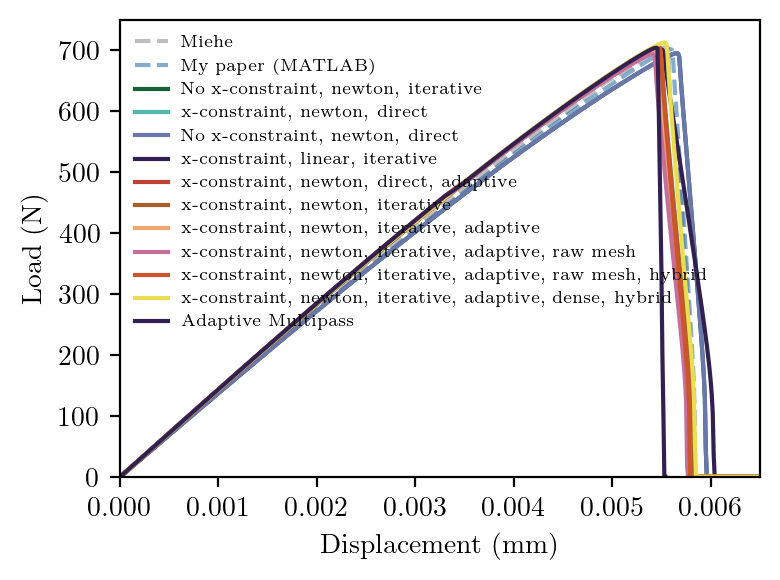

In [53]:
plt.figure(figsize=(4,3), dpi=200)

ax = plt.subplot(111)
ax.plot(ref_df["displacement"], ref_df["load"]*1e3, ls="--", color="grey", label="Miehe", alpha=0.5)
ax.plot(ref_mypaper_df[" totalDisp"], ref_mypaper_df[" Reaction-1"], ls="--", color=global_palette[2], alpha=0.5, label="My paper (MATLAB)")
ax.plot(no_x_constraint_iterative["Time"], no_x_constraint_iterative["Boundary-2-Dir-1"], ls="-", color=global_palette[0], label="No x-constraint, newton, iterative")
ax.plot(x_constraint_direct["Time"], x_constraint_direct["Boundary-2-Dir-1"], ls="-", color=global_palette[1], label="x-constraint, newton, direct")
ax.plot(no_x_constraint_direct["Time"], no_x_constraint_direct["Boundary-2-Dir-1"], ls="-", color=global_palette[3], label="No x-constraint, newton, direct")
ax.plot(x_constraint_linear_interative["Time"], x_constraint_linear_interative["Boundary-2-Dir-1"], ls="-", color=global_palette[4], label="x-constraint, linear, iterative")
ax.plot(x_constraint_newton_direct_adaptive["Time"], x_constraint_newton_direct_adaptive["Boundary-2-Dir-1"], ls="-", color=global_palette[5], label="x-constraint, newton, direct, adaptive")
ax.plot(x_constraint_newton_interative["Time"], x_constraint_newton_interative["Boundary-2-Dir-1"], ls="-", color=global_palette[6], label="x-constraint, newton, iterative")
ax.plot(x_constraint_newton_interative_adaptive["Time"], x_constraint_newton_interative_adaptive["Boundary-2-Dir-1"], ls="-", color=global_palette[7], label="x-constraint, newton, iterative, adaptive")

ax.plot(x_constraint_newton_interative_raw_mesh["Time"], x_constraint_newton_interative_raw_mesh["Boundary-2-Dir-1"], ls="-", color=global_palette[8], label="x-constraint, newton, iterative, adaptive, raw mesh")

ax.plot(x_constraint_newton_interative_raw_mesh_hybrid["Time"], x_constraint_newton_interative_raw_mesh_hybrid["Boundary-2-Dir-1"], ls="-", color=global_palette[9], label="x-constraint, newton, iterative, adaptive, raw mesh, hybrid")
ax.plot(x_constraint_newton_interative_dense_hybrid["Time"], x_constraint_newton_interative_dense_hybrid["Boundary-2-Dir-1"], ls="-", color=global_palette[10], label="x-constraint, newton, iterative, adaptive, dense, hybrid")
ax.plot(x_constraint_newton_direct_raw_mesh_hybrid_multipass["Time"], x_constraint_newton_direct_raw_mesh_hybrid_multipass["Boundary-1-Dir-1"], ls="-", color=global_palette[4], label="Adaptive Multipass")
ax.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.6)
ax.set_xlim([0, 0.0065])
ax.set_ylim([0, 750])
ax.set_xlabel("Displacement (mm)")
ax.set_ylabel("Load (N)")
plt.show()
plt.close()

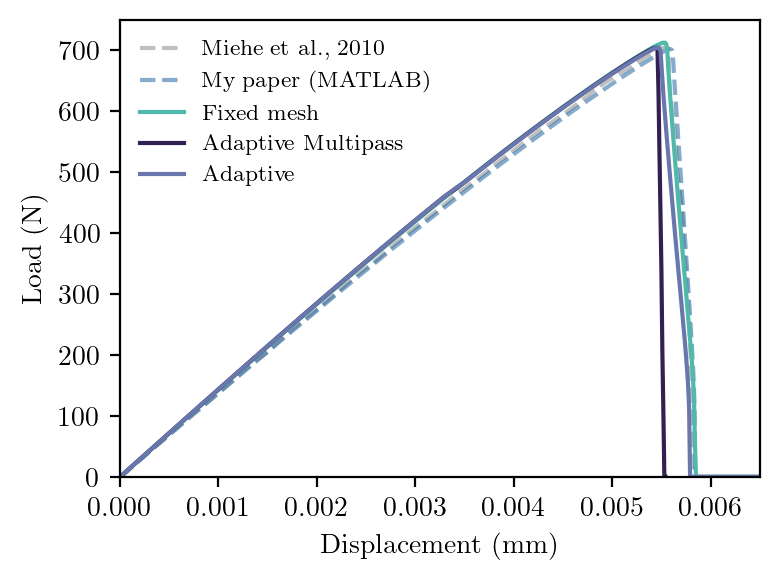

In [55]:
plt.figure(figsize=(4,3), dpi=200)

ax = plt.subplot(111)
ax.plot(ref_df["displacement"], ref_df["load"]*1e3, ls="--", color="grey", label="Miehe et al., 2010", alpha=0.5)
ax.plot(ref_mypaper_df[" totalDisp"], ref_mypaper_df[" Reaction-1"], ls="--", color=global_palette[2], alpha=0.5, label="My paper (MATLAB)")
# ax.plot(no_x_constraint_iterative["Time"], no_x_constraint_iterative["Boundary-2-Dir-1"], ls="-", color=global_palette[0], label="No x-constraint, newton, iterative")
ax.plot(x_constraint_newton_interative_dense_hybrid["Time"], x_constraint_newton_interative_dense_hybrid["Boundary-1-Dir-1"]*-1, ls="-", color=global_palette[1], label="Fixed mesh")
# ax.plot(no_x_constraint_direct["Time"], no_x_constraint_direct["Boundary-2-Dir-1"], ls="-", color=global_palette[3], label="No x-constraint, newton, direct")
# ax.plot(x_constraint_linear_interative["Time"], x_constraint_linear_interative["Boundary-2-Dir-1"], ls="-", color=global_palette[4], label="x-constraint, linear, iterative")
ax.plot(x_constraint_newton_direct_raw_mesh_hybrid_multipass["Time"], x_constraint_newton_direct_raw_mesh_hybrid_multipass["Boundary-1-Dir-1"], ls="-", color=global_palette[4], label="Adaptive Multipass")
ax.plot(x_constraint_newton_interative_raw_mesh_hybrid["Time"], x_constraint_newton_interative_raw_mesh_hybrid["Boundary-1-Dir-1"]*-1, ls="-", color=global_palette[3], label="Adaptive")

ax.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.8)
ax.set_xlim([0, 0.0065])
ax.set_ylim([0, 750])
ax.set_xlabel("Displacement (mm)")
ax.set_ylabel("Load (N)")
plt.savefig(os.path.join(plot_root, "miehe-tension-0015.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()

In [12]:
x_constraint_newton_direct_raw_mesh_hybrid_monolithic

,Step,Step.1,Out,Time,Boundary-1-Dir-0,Boundary-1-Dir-1,Boundary-2-Dir-0,Boundary-2-Dir-1,Boundary-3-Dir-0,Boundary-3-Dir-1,Boundary-4-Dir-0,Boundary-4-Dir-1
0,0,0,0.000010,0.011669,1.440997,0.011681,-1.442427,0.002629,-0.000002,0.037083,-0.000022,NaN
1,9,9,0.000100,0.116643,14.423239,0.116890,-14.423562,0.026287,-0.000003,0.370885,-0.000203,NaN
2,19,19,0.000200,0.233203,28.843994,0.233803,-28.844659,0.052586,-0.000005,0.741512,-0.000548,NaN
3,29,29,0.000300,0.349674,43.259744,0.350732,-43.260771,0.078906,-0.000008,1.111719,-0.001036,NaN
4,39,39,0.000400,0.466049,57.667970,0.467669,-57.669378,0.105256,-0.000010,1.481345,-0.001667,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
122,1219,1219,0.005729,6.168752,456.485891,6.229393,-456.484495,2.698583,0.005184,13.721482,-0.008315,NaN
123,1229,1229,0.005739,6.119014,445.157263,6.176216,-445.155840,2.715028,0.005043,13.551248,-0.008104,NaN
124,1239,1239,0.005749,6.064691,433.826789,6.118624,-433.825337,2.729547,0.004913,13.372181,-0.007892,NaN
125,1249,1249,0.005759,6.005553,422.468955,6.056320,-422.467470,2.742002,0.004792,13.183556,-0.007677,NaN


## Miehe shear

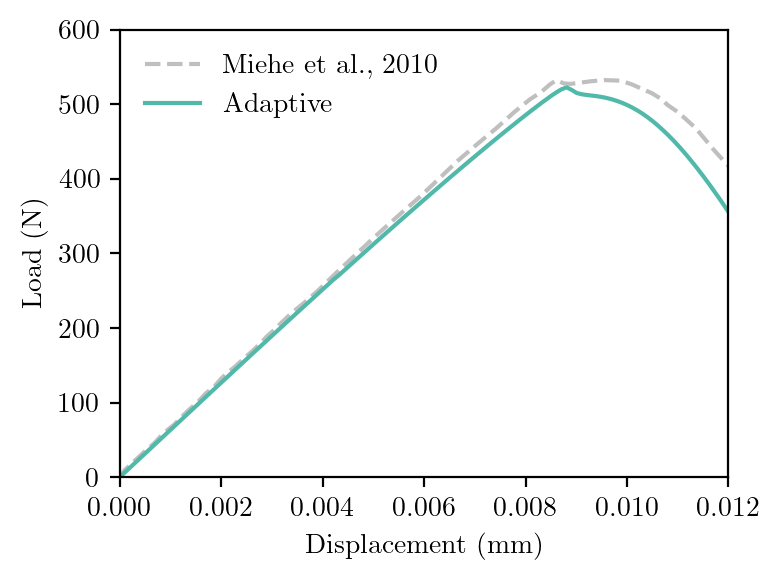

In [33]:
ref_df = pd.read_csv("ref/miehe-shear-0015.csv")
shear_adaptive = pd.read_csv("output/singleNotchShear-2024-08-02-18-49-04-hybrid/statistics.txt", delim_whitespace=True)

plt.figure(figsize=(4,3), dpi=200)

ax = plt.subplot(111)
ax.plot(ref_df["x"], ref_df[" y"]*1e3, ls="--", color="grey", label="Miehe et al., 2010", alpha=0.5)
ax.plot(shear_adaptive["Time"], shear_adaptive["Boundary-1-Dir-0"]*-1, ls="-", color=global_palette[1], label="Adaptive")
ax.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*1)
ax.set_xlim([0, 0.012])
ax.set_ylim([0, 600])
ax.set_xlabel("Displacement (mm)")
ax.set_ylabel("Load (N)")
plt.savefig(os.path.join(plot_root, "miehe-shear-0015.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()

In [27]:
ref_df.columns

Index(['x', ' y'], dtype='object')

## Carrara 2020

In [54]:
values_spectral = get_cell_value("output/singleNotchTensionFatigueCarrara-2024-08-14-13-11-14-4cycle-spectral", 6308, "Fatigue_history")
values_notension = get_cell_value("output/singleNotchTensionFatigueCarrara-2024-08-14-13-26-00-4cycle-notension", 6308, "Fatigue_history")

values_nosplit = get_cell_value("output/singleNotchTensionFatigueCarrara-2024-08-14-13-36-56-4cycle-nosplit", 6308, "Fatigue_history")

  0%|          | 0/401 [00:00<?, ?it/s]

  0%|          | 0/401 [00:00<?, ?it/s]

  0%|          | 0/401 [00:00<?, ?it/s]

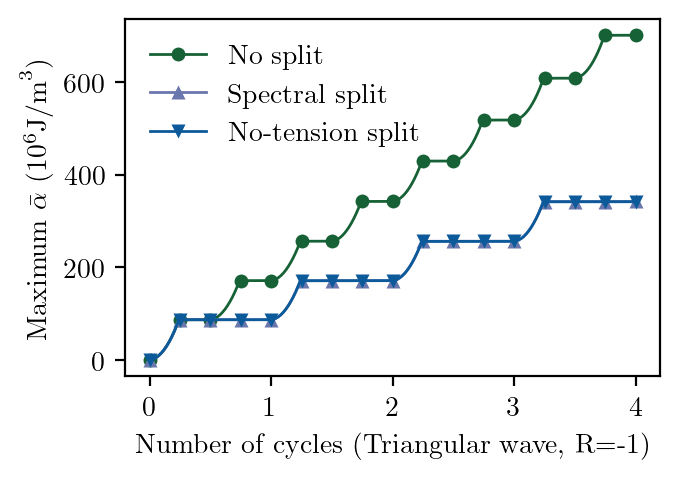

In [58]:

plt.figure(figsize=(3.5,2.5), dpi=200)

ax = plt.subplot(111)

ax.plot(np.arange(len(values_nosplit))/100, values_nosplit, ls="-", color=global_palette[0], marker="o", markevery=25, markeredgecolor='none', markersize=5, label="No split", lw=1)

ax.plot(np.arange(len(values_spectral))/100, values_spectral, ls="-", color=global_palette[3], marker="^", markevery=25, markeredgecolor='none', markersize=5, label="Spectral split", lw=1)

ax.plot(np.arange(len(values_notension))/100, values_notension, ls="-", color=global_palette[2], marker="v", markevery=25, markeredgecolor='none', markersize=5, label="No-tension split", lw=1)



ax.set_xlabel("Number of cycles (Triangular wave, R=-1)")
ax.set_ylabel(r"Maximum $\bar{\alpha}$ ($10^{6}\mathrm{J/m}^3$)")


# ax = ax.twinx()
# x = np.linspace(0, np.max(len(values_notension)/100), int(np.max(len(values_notension)/100)*4)+1)
# ax.plot(x, np.sin(2*np.pi*1*x)*0.002, ls="--", color="grey", alpha=0.5, label="Loading", zorder=0)
# ax.set_ylim([-0.003, 0.003])
ax.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*1)

# ax.set_ylabel("Displacement (mm)")
plt.savefig(os.path.join(plot_root, "singlenotchtension_4cycles_differentsplit.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()

In [214]:
ref_df = pd.read_csv("ref/carrara-singlenotch-spectral.csv")
ref_no_split_df = pd.read_csv("ref/carrara-singlenotch-nosplit.csv")
n_cycles_no_split, crack_lengths_no_split = get_phi_x_max("output/singleNotchTensionFatigueCarrara-2024-08-15-07-43-53-nosplit", crack_tip=0.5, cycle_per_file=1)
n_cycles, crack_lengths = get_phi_x_max("output/singleNotchTensionFatigueCarrara-2024-08-15-07-43-18-spectral", crack_tip=0.5, cycle_per_file=1)

  0%|          | 0/401 [00:00<?, ?it/s]

  0%|          | 0/401 [00:00<?, ?it/s]

In [255]:
enumerate_crack_lengths(n_cycles_no_split, crack_lengths_no_split)

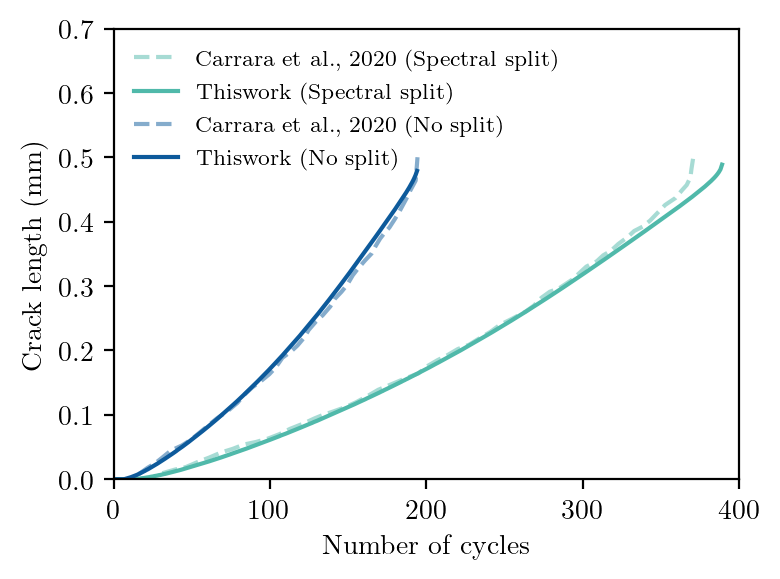

In [479]:
plt.figure(figsize=(4,3), dpi=200)

ax = plt.subplot(111)
ax.plot(ref_df["x"], ref_df[" y"], ls="--", color=global_palette[1], label="Carrara et al., 2020 (Spectral split)", alpha=0.5)
ax.plot(np.array(n_cycles)[:390], np.array(crack_lengths)[:390], ls="-", color=global_palette[1], label="Thiswork (Spectral split)")
# ax.plot(np.array(n_cycles_no_tension), np.array(crack_lengths_no_tension), ls="-", color=global_palette[1], label="My code (No-tension split)")
ax.plot(ref_no_split_df["x"], ref_no_split_df[" y"], ls="--", color=global_palette[2], label="Carrara et al., 2020 (No split)", alpha=0.5)
ax.plot(np.array(n_cycles_no_split)[:195], np.array(crack_lengths_no_split)[:195], ls="-", color=global_palette[2], label="Thiswork (No split)")
# ax.plot(n_cycles_no_split_iterative, crack_lengths_no_split_iterative, ls="-", color=global_palette[3], label="My code (No split, iter)", alpha=0.5)
ax.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.8)
ax.set_xlim([0, 400])
ax.set_ylim([0, 0.7])
ax.set_xlabel("Number of cycles")
ax.set_ylabel("Crack length (mm)")
plt.savefig(os.path.join(plot_root, "carrara-singlenotch-spectral.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()

In [217]:
delta_p = 40
T = 1
W = 50
Y = lambda x: (2+x)/(np.power(1-x, 3/2))*(0.886+4.64*x-13.32*x**2+14.72*x**3-5.6*x**4)

n_cycles, crack_lengths = get_phi_x_max("output/CarraraCTParis-2024-08-20-12-16-48-goodgood-fixedmesh", crack_tip=(0.25+0.22)*W, cycle_per_file=1)



  0%|          | 0/773 [00:00<?, ?it/s]

In [256]:
enumerate_crack_lengths(n_cycles, crack_lengths)

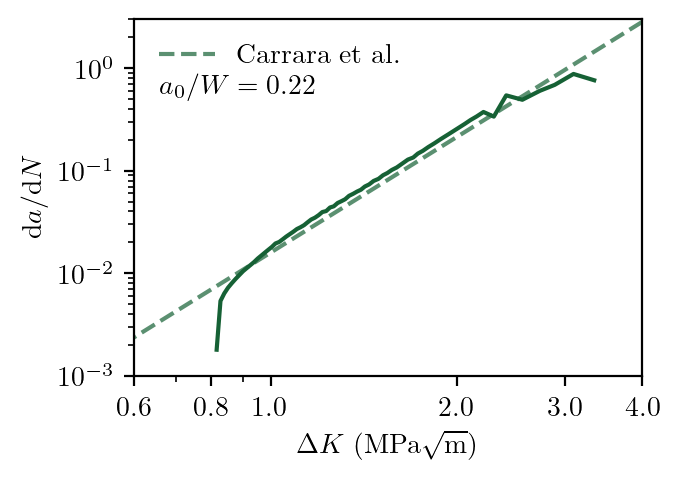

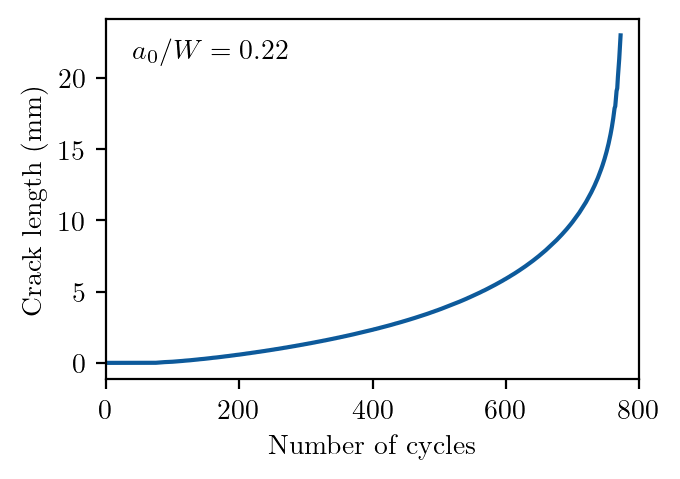

In [306]:

recorded_cycle = []
lengths = []
da_dn = []
delta_k = []
accumulated_da = 0
accumulated_dn = 0
for i in range(1, len(crack_lengths)):
    da = (crack_lengths[i]-crack_lengths[i-1])
    dn = n_cycles[i]-n_cycles[i-1]
    accumulated_da += da
    accumulated_dn += dn
    # print(accumulated_da, accumulated_dn)
    if accumulated_da > 0.25:
        da_dn.append(accumulated_da/accumulated_dn)
        a_avg = crack_lengths[i] - accumulated_da/2
        delta_k.append(delta_p/(T*np.sqrt(W))*Y((a_avg+0.22*W)/W)*np.sqrt(0.001))
        recorded_cycle.append((n_cycles[i]+n_cycles[i-1])/2)
        lengths.append(a_avg)
        # print(accumulated_da/accumulated_dn, delta_k[-1])
        accumulated_da=0
        accumulated_dn=0

plt.figure(figsize=(3.5,2.5), dpi=200)

ax = plt.subplot(111)
ax.plot(delta_k, da_dn, color=global_palette[0])

ax.text(0.05, 0.85, r"$a_0/W=0.22$", ha="left", va="top", transform=ax.transAxes)


delta_k_paris = np.linspace(0.5, 4.0, 100)
da_dn_paris = 0.016*(delta_k_paris)**3.73
ax.plot(delta_k_paris, da_dn_paris, color=global_palette[0], ls="--", alpha=0.7, label=r"Carrara et al.") #$\frac{\mathrm{d}a}{\mathrm{d}N}=0.016(\Delta K)^{3.73}$ 


ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim([0.6, 4.0])
# xlim = ax.get_xlim()
# ax.plot(ax.get_xlim(), [0.04, 0.04], ls="--", lw=0.5, color="grey")
# ax.text(xlim[0]+(xlim[1]-xlim[0])*0.001, 0.04, r"$\frac{\mathrm{d}a}{\mathrm{d}N}=0.04$", ha="left", va="bottom")

# ax.set_xlim(xlim)
ax.set_ylim([1e-3, 3])
ax.set_xticks([ 0.6, 0.8, 1.0, 2.0, 3.0, 4.0])
ax.set_xticklabels([0.6, 0.8, 1.0, 2.0, 3.0, 4.0])
ax.set_ylabel(r"$\mathrm{d}a/\mathrm{d}N$")
ax.set_xlabel(r"$\Delta K$ (MPa$\sqrt{\mathrm{m}}$)")
# ax.spines["left"].set_color(global_palette[0])
# ax.spines["right"].set_color(global_palette[2])
# ax.tick_params(axis="y", colors=global_palette[0], which="both")
# ax.yaxis.label.set_color(global_palette[0])
ax.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"])

# ax = ax.twinx()
# ax.plot(delta_k, lengths, color=global_palette[2], ls="-")
# ax.set_ylabel("Crack length (mm)")
# ax.spines["left"].set_color(global_palette[0])
# ax.spines["right"].set_color(global_palette[2])
# ax.tick_params(axis="y", colors=global_palette[2])
# ax.yaxis.label.set_color(global_palette[2])

plt.savefig(os.path.join(plot_root, "carrara-paris.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()


plt.figure(figsize=(3.5,2.5), dpi=200)

ax = plt.subplot(111)
ax.text(0.05, 0.95, r"$a_0/W=0.22$", ha="left", va="top", transform=ax.transAxes)


# ax.plot(recorded_cycle, da_dn, color=global_palette[0], ls="-")

# ax.set_ylabel(r"$\mathrm{d}a/\mathrm{d}N$")
ax.set_xlabel("Number of cycles")
# ax.spines["left"].set_color(global_palette[0])
# ax.spines["right"].set_color(global_palette[2])
# ax.tick_params(axis="y", colors=global_palette[0], which="both")
# ax.yaxis.label.set_color(global_palette[0])
# ax.set_yscale("log")
ax.set_xlim([0, 800])
# ax.set_ylim([1e-3, 3])
# xlim = ax.get_xlim()
# ax.plot(ax.get_xlim(), [0.04, 0.04], ls="--", lw=0.5, color="grey")
# ax.text(xlim[0]+(xlim[1]-xlim[0])*0.01, 0.04, r"$\frac{\mathrm{d}a}{\mathrm{d}N}=0.04$", ha="left", va="bottom")

# ax.set_xlim(xlim)
# ax = ax.twinx()
ax.plot(n_cycles, crack_lengths, color=global_palette[2], ls="-")
ax.set_ylabel("Crack length (mm)")
# ax.spines["left"].set_color(global_palette[0])
# ax.spines["right"].set_color(global_palette[2])
# ax.tick_params(axis="y", colors=global_palette[2])
# ax.yaxis.label.set_color(global_palette[2])
# ax.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.8)
plt.savefig(os.path.join(plot_root, "carrara-paris-crack-growth-rate.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()



In [39]:
delta_k, da_dn

NameError: name 'delta_k' is not defined

## Kristensen

In [108]:
n_cycles_nosplit, crack_lengths_nosplit = get_phi_x_max("output/singleNotchTensionFatigueKristensen-2024-08-07-17-07-56-nosplit", crack_tip=0.5, cycle_per_file=50, ylim=[0.3, 0.7])

  0%|          | 0/2401 [00:00<?, ?it/s]

In [109]:
n_cycles_split, crack_lengths_split = get_phi_x_max("output/singleNotchTensionFatigueKristensen-2024-08-07-17-06-52-notension", crack_tip=0.5, cycle_per_file=50, ylim=[0.3, 0.7])

  0%|          | 0/2401 [00:00<?, ?it/s]

In [257]:
enumerate_crack_lengths(n_cycles_split, crack_lengths_split)

In [258]:
enumerate_crack_lengths(n_cycles_nosplit, crack_lengths_nosplit)

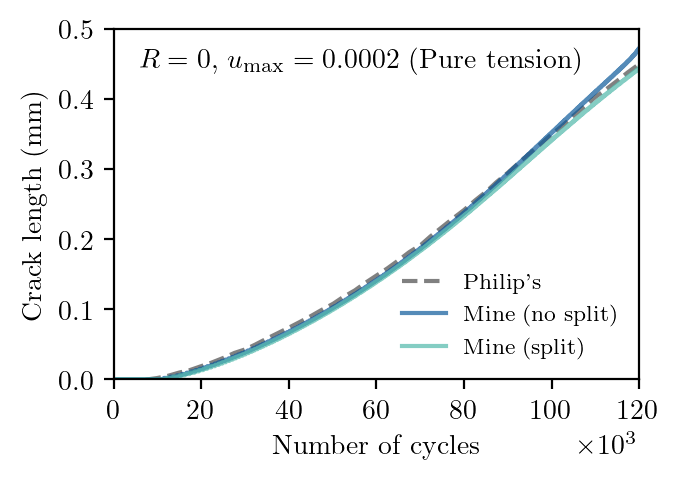

In [ ]:
ref_df = pd.read_csv("ref/kristensen-singlenotch.csv")

plt.figure(figsize=(3.5,2.5), dpi=200)

ax = plt.subplot(111)
ax.ticklabel_format(axis='x', style='sci', scilimits=(3,3))

ax.text(0.05, 0.95, r"$R=0$, $u_{\max}=0.0002$ (Pure tension)", ha="left", va="top", transform=ax.transAxes)

ax.plot(ref_df["x"], ref_df[" y"], ls="--", color="grey", label="Philip's")

# ax.plot(np.array(n_cycles), crack_lengths, ls="-", color=global_palette[0], label="Mine (R=-1)")
# ax.plot(np.array(n_cycles)*2, crack_lengths, ls="-", color=global_palette[1], label=r"Mine (R=-1, cycles$\times$2)")
ax.plot(np.array(n_cycles_nosplit), crack_lengths_nosplit, ls="-", color=global_palette[2], label=r"Mine (no split)", alpha=0.7)
ax.plot(np.array(n_cycles_split), crack_lengths_split, ls="-", color=global_palette[1], label=r"Mine (split)", alpha=0.7)
# ax.plot(np.array(n_cycles_half), crack_lengths_half, ls="-")
ax.legend(loc="lower right", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.8)
ax.set_xlim([0, 120000])
ax.set_ylim([0, 0.5])
ax.set_xlabel("Number of cycles")
ax.set_ylabel("Crack length (mm)")

plt.savefig(os.path.join(plot_root, "kristensen-singlenotchtension.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()

In [116]:
n_cycles_baseline, crack_lengths_baseline = get_phi_x_max("output/singleNotchTensionFatigueKristensen-2024-08-10-14-43-51-baseline", crack_tip=0.5, cycle_per_file=50, ylim=[0.3, 0.7])

  0%|          | 0/2401 [00:00<?, ?it/s]

In [117]:
n_cycles_cla, crack_lengths_cla = get_phi_x_max("output/singleNotchTensionFatigueKristensen-2024-08-10-14-45-11-cla", crack_tip=0.5, cycle_per_file=50, ylim=[0.3, 0.7])

  0%|          | 0/2401 [00:00<?, ?it/s]

In [118]:
n_cycles_mn, crack_lengths_mn = get_phi_x_max("output/singleNotchTensionFatigueKristensen-2024-08-10-22-23-17-mn", crack_tip=0.5, cycle_per_file=50, ylim=[0.3, 0.7])

  0%|          | 0/2401 [00:00<?, ?it/s]

In [119]:
n_cycles_mncla, crack_lengths_mncla = get_phi_x_max("output/singleNotchTensionFatigueKristensen-2024-08-10-22-23-34-mncla", crack_tip=0.5, cycle_per_file=50, ylim=[0.3, 0.7])

  0%|          | 0/2401 [00:00<?, ?it/s]

In [259]:
enumerate_crack_lengths(n_cycles_baseline, crack_lengths_baseline)
enumerate_crack_lengths(n_cycles_cla, crack_lengths_cla)
enumerate_crack_lengths(n_cycles_mn, crack_lengths_mn)
enumerate_crack_lengths(n_cycles_mncla, crack_lengths_mncla)

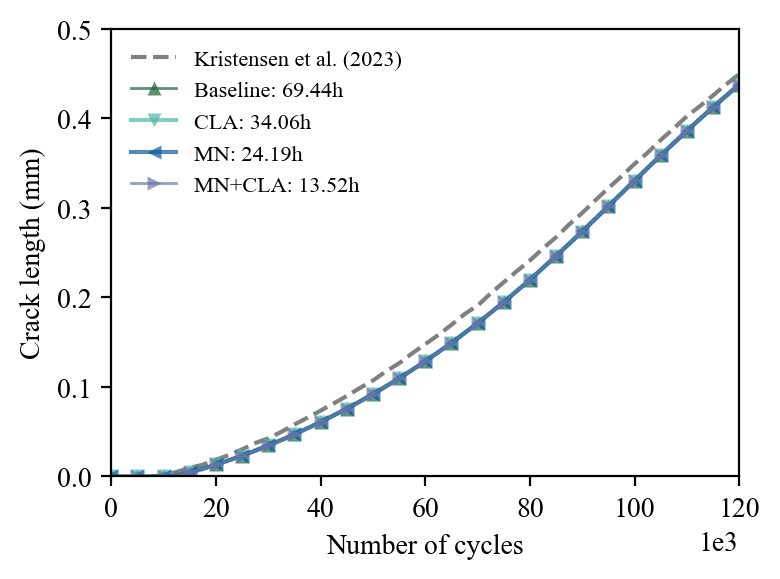

In [125]:
ref_df = pd.read_csv("ref/kristensen-singlenotch.csv")

plt.figure(figsize=(4,3), dpi=200)

ax = plt.subplot(111)
ax.ticklabel_format(axis='x', style='sci', scilimits=(3,3))

ax.plot(ref_df["x"], ref_df[" y"], ls="--", color="grey", label="Kristensen et al. (2023)")
marker_kwargs = dict(markersize=5, markevery=100, markeredgecolor='none')
ax.plot(np.array(n_cycles_baseline), crack_lengths_baseline, ls="-", marker="^", **marker_kwargs, color=global_palette[0], label=r"Baseline: 69.44h", alpha=0.7, lw=1)
# ax.plot(np.array(n_cycles_split), crack_lengths_split, ls="-", marker="^", **marker_kwargs, color=global_palette[1], label=r"Baseline2", alpha=1, lw=1)
ax.plot(np.array(n_cycles_cla), crack_lengths_cla, ls="-", marker="v", **marker_kwargs, color=global_palette[1], label=r"CLA: 34.06h", alpha=0.7)
ax.plot(np.array(n_cycles_mn), crack_lengths_mn, ls="-", marker="<", **marker_kwargs, color=global_palette[2], label=r"MN: 24.19h", alpha=0.7)
ax.plot(np.array(n_cycles_mncla), crack_lengths_mncla, ls="-", marker=">", **marker_kwargs, color=global_palette[3], label=r"MN+CLA: 13.52h", alpha=0.7, lw=1)
# ax.plot(np.array(n_cycles_half), crack_lengths_half, ls="-")
ax.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.8)
ax.set_xlim([0, 120000])
ax.set_ylim([0, 0.5])
ax.set_xlabel("Number of cycles")
ax.set_ylabel("Crack length (mm)")

plt.savefig(os.path.join(plot_root, "kristensen-singlenotchtension-three-methods.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()

## Cojocaru

In [135]:
n_cycles_cojocaru_baseline, crack_lengths_cojocaru_baseline = get_phi_x_max("output/CojocaruSEVNT2-2024-08-11-22-31-22-baseline", crack_tip=0, cycle_per_file=5, ylim=[-0.1, 0.1])

  0%|          | 0/1922 [00:00<?, ?it/s]

In [136]:
n_cycles_cojocaru_jump2, crack_lengths_cojocaru_jump2 = get_phi_x_max("output/CojocaruSEVNT2-2024-09-11-16-53-37-cyclejump", crack_tip=0, cycle_per_file=5, ylim=[-0.1, 0.1], infer_cycle_by_name=True)

  0%|          | 0/667 [00:00<?, ?it/s]

In [262]:
enumerate_crack_lengths(n_cycles_cojocaru_baseline, crack_lengths_cojocaru_baseline)

Rough
304 True 1922 [1470, 1475, 1480, 1485, 1490, 1495, 1500, 1505, 1510, 1515] [5.007965232882055, 5.008138111473295, 5.0083187521792425, 5.008507667853116, 5.008705474097365, 5.008912785771649, 5.009129789635589, 5.009357231860784, 5.0379357695966, 5.03864710312819]
Rough
338 True 1922 [1640, 1645, 1650, 1655, 1660, 1665, 1670, 1675, 1680, 1685] [5.046773537922377, 5.047019698129532, 5.047283755551851, 5.0475685852111525, 5.047876038757062, 5.04820711155612, 5.048562610471614, 5.048943845028785, 5.075350402374467, 5.076582740934235]
Rough
482 True 1922 [2360, 2365, 2370, 2375, 2380, 2385, 2390, 2395, 2400, 2405] [5.2726298122809085, 5.273584603119086, 5.274532860228145, 5.275479733075279, 5.276427678611407, 5.277381114914357, 5.2783435968540715, 5.279317422224403, 5.2799901797301265, 5.280694643476403]
Rough
618 True 1922 [3040, 3045, 3050, 3055, 3060, 3065, 3070, 3075, 3080, 3085] [5.500822615222258, 5.501665674116065, 5.5025157250907055, 5.503374218152566, 5.50424491092693, 5.5051

In [261]:
enumerate_crack_lengths(n_cycles_cojocaru_jump2, crack_lengths_cojocaru_jump2)

Spike
666 True 667 [9492, 9495, 9498, 9501, 9504, 9507, 9510, 9513, 9516, 9519] [25.107394610682626, 25.718565137175265, 26.42192331711894, 27.23163821615703, 28.185128781013965, 29.328740583321792, 30.759101465563415, 32.66030122299982, 35.54649547888924, 40.82178554803736]


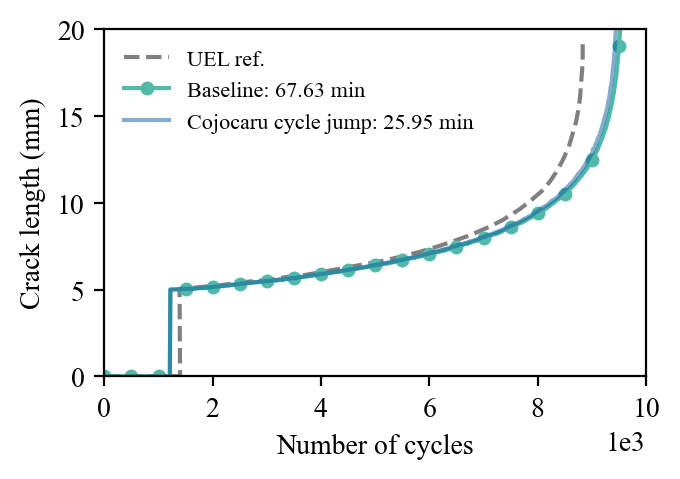

In [139]:
ref_df = pd.read_csv("ref/cojocaru.csv")

plt.figure(figsize=(3.5,2.5), dpi=200)

ax = plt.subplot(111)
ax.ticklabel_format(axis='x', style='sci', scilimits=(3,3))
marker_kwargs = dict(markersize=5, markeredgecolor='none')
ax.plot(ref_df["x"], ref_df[" y"], ls="--", color="grey", label="UEL ref.", lw=1.5)
ax.plot(np.array(n_cycles_cojocaru_baseline), crack_lengths_cojocaru_baseline, ls="-", markevery=100, marker="o", **marker_kwargs, color=global_palette[1], label=r"Baseline: 67.63 min", alpha=1, lw=1.5)

ax.plot(np.array(n_cycles_cojocaru_jump2), np.array(crack_lengths_cojocaru_jump2), ls="-", color=global_palette[2], label=r"Cojocaru cycle jump: 25.95 min", alpha=0.5, lw=1.5)

# ax.text(0.04, 0.67, r"Both with MN+CLA", ha="left", va="top", transform=ax.transAxes, fontsize=plt.rcParams["font.size"]*0.8)


ax.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.8)
ax.set_xlim([0, 10000])
ax.set_ylim([0, 20])
ax.set_xlabel("Number of cycles")
ax.set_ylabel("Crack length (mm)")

plt.savefig(os.path.join(plot_root, "cojocaru.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()

## Jonas

[7.15261495 0.70789363 1.4236912 ]
[1.2628246  0.55521829 1.16223472]


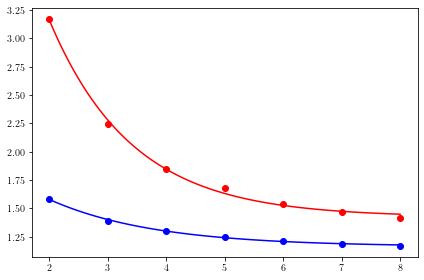

[7.59315987 0.64105545 1.80994109]
[1.23659923 0.53470298 1.1750714 ]


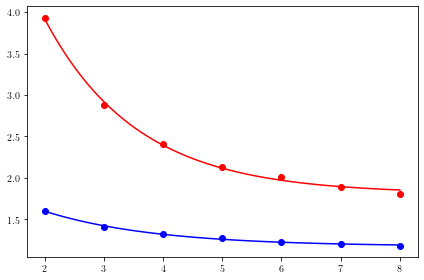

In [ ]:
import scipy

def func(x, a, b, c):
    return a*np.exp(-x*b)+c

from scipy.optimize import curve_fit

# AT1
at_data = np.array([[2, 3.171, 1.582],
[3, 2.244, 1.390],
[4, 1.846, 1.302],
[5, 1.680, 1.249],
[6, 1.539, 1.211], 
[7, 1.468, 1.187], 
[8, 1.416, 1.171]])

x = np.linspace(np.min(at_data[:, 0]), np.max(at_data[:, 0]), 100)

plt.figure()
plt.scatter(at_data[:,0], at_data[:, 1], color="red")

popt, pcov = curve_fit(func, at_data[:,0], at_data[:, 1])
print(popt)
plt.plot(x, func(x, *popt), color="red")
plt.scatter(at_data[:,0], at_data[:, 2], color="blue")
popt, pcov = curve_fit(func, at_data[:,0], at_data[:, 2])
print(popt)
plt.plot(x, func(x, *popt), color="blue")
plt.show()
plt.close()

# AT2
at_data = np.array([[2, 3.931, 1.604], 
[3, 2.875, 1.411],
[4, 2.410, 1.323] ,
[5, 2.136, 1.271] ,
[6, 2.014, 1.228 ],
[7, 1.893, 1.204 ],
[8, 1.812, 1.185]])

x = np.linspace(np.min(at_data[:, 0]), np.max(at_data[:, 0]), 100)

plt.figure()
plt.scatter(at_data[:,0], at_data[:, 1], color="red")

popt, pcov = curve_fit(func, at_data[:,0], at_data[:, 1])
print(popt)
plt.plot(x, func(x, *popt), color="red")
plt.scatter(at_data[:,0], at_data[:, 2], color="blue")
popt, pcov = curve_fit(func, at_data[:,0], at_data[:, 2])
print(popt)
plt.plot(x, func(x, *popt), color="blue")
plt.show()
plt.close()

In [263]:
W=50
n_cycles, crack_lengths = get_phi_x_max("output/CarraraCTParis-2024-09-05-14-11-21-corrected", crack_tip=(0.25+0.22)*W, cycle_per_file=1)

  0%|          | 0/854 [00:00<?, ?it/s]

In [143]:
n_cycles_jonas, crack_lengths_jonas = get_phi_x_max("output/CarraraCTParis-2024-09-09-19-27-12-jonas", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True)
# n_cycles_jonas2, crack_lengths_jonas2 = get_phi_x_max("output/CarraraCTParis-2024-08-20-07-54-39", crack_tip=(0.25+0.22)*W, cycle_per_file=1)

  0%|          | 0/147 [00:00<?, ?it/s]

In [144]:
n_cycles_1storder, crack_lengths_1storder = get_phi_x_max("output/CarraraCTParis-2024-10-29-18-40-40-1storder", crack_tip=(0.25+0.22)*W, cycle_per_file=1)

  0%|          | 0/944 [00:00<?, ?it/s]

In [264]:
enumerate_crack_lengths(n_cycles, crack_lengths)

In [265]:
enumerate_crack_lengths(n_cycles_jonas, crack_lengths_jonas)

In [266]:
enumerate_crack_lengths(n_cycles_1storder, crack_lengths_1storder)

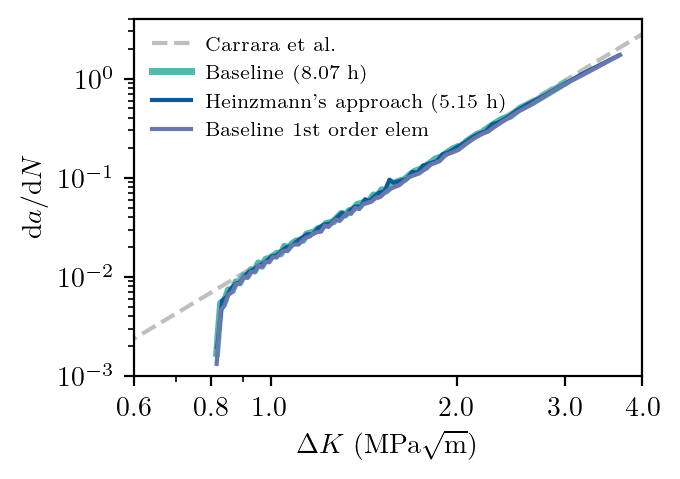

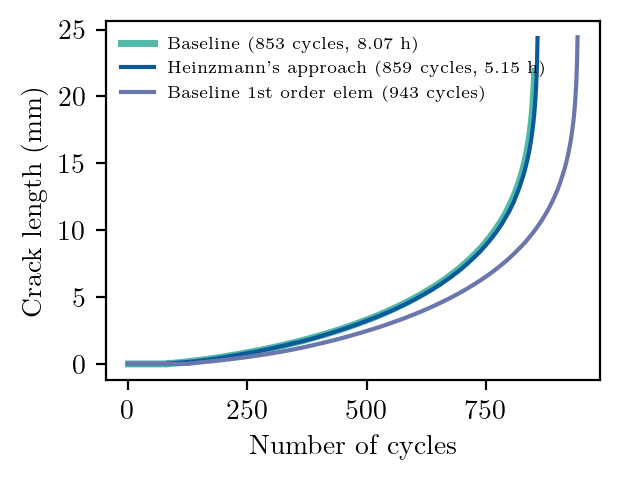

In [ ]:
recorded_cycle, lengths, da_dn, delta_k = incremental_growth(n_cycles, crack_lengths, delta_p=40, T=1, W=50)
recorded_cycle_jonas, lengths_jonas, da_dn_jonas, delta_k_jonas = incremental_growth(n_cycles_jonas, crack_lengths_jonas, delta_p=40, T=1, W=50)
recorded_cycle_1storder, lengths_1storder, da_dn_1storder, delta_k_1storder = incremental_growth(n_cycles_1storder, crack_lengths_1storder, delta_p=40, T=1, W=50)

plt.figure(figsize=(3.5,2.5), dpi=200)

ax = plt.subplot(111)

delta_k_paris = np.linspace(0.5, 4.0, 100)
da_dn_paris = 0.016*(delta_k_paris)**3.73
ax.plot(delta_k_paris, da_dn_paris, color="grey", ls="--", alpha=0.5, label=r"Carrara et al.") #$\frac{\mathrm{d}a}{\mathrm{d}N}=0.016(\Delta K)^{3.73}$ 


ax.plot(delta_k, da_dn, color=global_palette[1], ls="-", label="Baseline (8.07 h)", alpha=1, lw=2.5)
ax.plot(delta_k_jonas, da_dn_jonas, color=global_palette[2], ls="-", label="Heinzmann's approach (5.15 h)", alpha=1, lw=1.5)
ax.plot(delta_k_1storder, da_dn_1storder, color=global_palette[3], ls="-", label="Baseline 1st order elem", alpha=1, lw=1.5)

# ax.text(0.05, 0.55, r"$a_0/W=0.22$", ha="left", va="top", transform=ax.transAxes)


ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim([0.6, 4.0])
# xlim = ax.get_xlim()
# ax.plot(ax.get_xlim(), [0.04, 0.04], ls="--", lw=0.5, color="grey")
# ax.text(xlim[0]+(xlim[1]-xlim[0])*0.001, 0.04, r"$\frac{\mathrm{d}a}{\mathrm{d}N}=0.04$", ha="left", va="bottom")

# ax.set_xlim(xlim)
ax.set_ylim([1e-3, 4])
ax.set_xticks([ 0.6, 0.8, 1.0, 2.0, 3.0, 4.0])
ax.set_xticklabels([0.6, 0.8, 1.0, 2.0, 3.0, 4.0])
ax.set_ylabel(r"$\mathrm{d}a/\mathrm{d}N$")
ax.set_xlabel(r"$\Delta K$ (MPa$\sqrt{\mathrm{m}}$)")
# ax.spines["left"].set_color(global_palette[0])
# ax.spines["right"].set_color(global_palette[2])
# ax.tick_params(axis="y", colors=global_palette[0], which="both")
# ax.yaxis.label.set_color(global_palette[0])
ax.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.7)

# ax = ax.twinx()
# ax.plot(delta_k, lengths, color=global_palette[2], ls="-")
# ax.set_ylabel("Crack length (mm)")
# ax.spines["left"].set_color(global_palette[0])
# ax.spines["right"].set_color(global_palette[2])
# ax.tick_params(axis="y", colors=global_palette[2])
# ax.yaxis.label.set_color(global_palette[2])

plt.savefig(os.path.join(plot_root, "jonas-carrara-paris.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()


plt.figure(figsize=(3.2,2.5), dpi=200)

ax = plt.subplot(111)
# ax.text(0.05, 0.95, r"$a_0/W=0.22$", ha="left", va="top", transform=ax.transAxes)


# ax.plot(recorded_cycle, da_dn, color=global_palette[0], ls=".", label="Baseline")
# ax.plot(recorded_cycle_jonas, da_dn_jonas, color=global_palette[0], ls="-", label="Jonas et al.")


# ax.set_ylabel(r"$\mathrm{d}a/\mathrm{d}N$")
ax.set_xlabel("Number of cycles")
# ax.spines["left"].set_color(global_palette[0])
# ax.spines["right"].set_color(global_palette[2])
# ax.tick_params(axis="y", colors=global_palette[0], which="both")
# ax.yaxis.label.set_color(global_palette[0])
# ax.set_yscale("log")
# ax.set_xlim([0, 800])
# ax.set_ylim([1e-3, 3])
# xlim = ax.get_xlim()
# ax.plot(ax.get_xlim(), [0.04, 0.04], ls="--", lw=0.5, color="grey")
# ax.text(xlim[0]+(xlim[1]-xlim[0])*0.01, 0.04, r"$\frac{\mathrm{d}a}{\mathrm{d}N}=0.04$", ha="left", va="bottom")

# ax.set_xlim(xlim)
# ax = ax.twinx()
ax.plot(n_cycles, crack_lengths, color=global_palette[1], ls="-", label=f"Baseline ({n_cycles[-1]} cycles, 8.07 h)", alpha=1, lw=2.5)
ax.plot(n_cycles_jonas, np.array(crack_lengths_jonas), color=global_palette[2], ls="-", label=f"Heinzmann's approach ({n_cycles_jonas[-1]} cycles, 5.15 h)", alpha=1, lw=1.5)
ax.plot(n_cycles_1storder, np.array(crack_lengths_1storder), color=global_palette[3], ls="-", label=f"Baseline 1st order elem ({n_cycles_1storder[-1]} cycles)", alpha=1, lw=1.5)

ax.set_ylabel("Crack length (mm)")
# ax.spines["left"].set_color(global_palette[0])
# ax.spines["right"].set_color(global_palette[2])
# ax.tick_params(axis="y", colors=global_palette[2])
# ax.yaxis.label.set_color(global_palette[2])
ax.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.6)
plt.savefig(os.path.join(plot_root, "jonas-carrara-paris-crack-growth-rate.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()

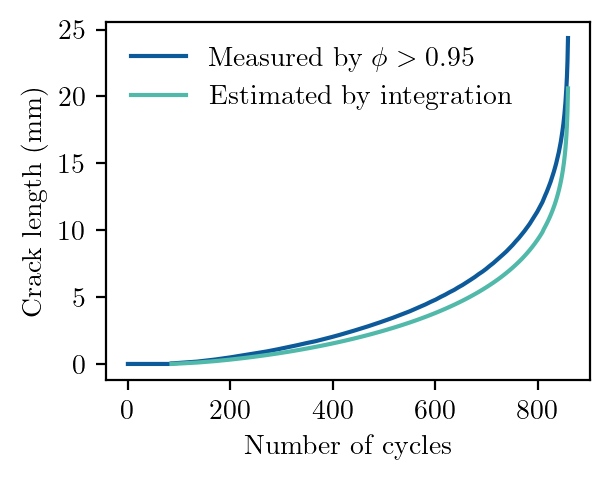

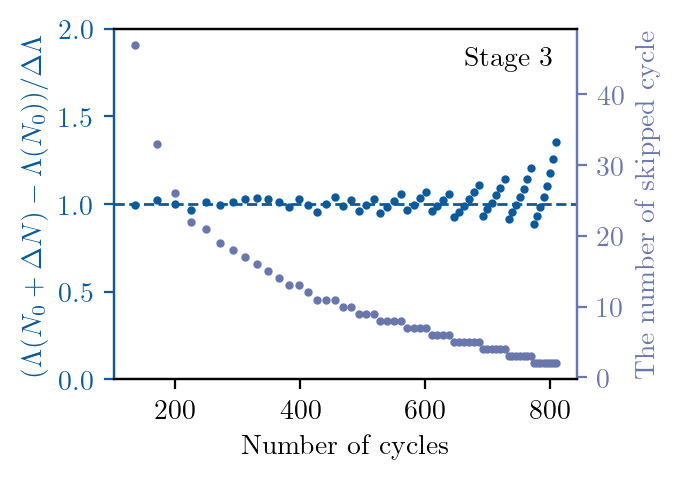

In [ ]:
import re

logfile = "output/CarraraCTParis-2024-09-09-19-27-12-jonas/log.txt"

with open(logfile, "r") as file:
    s = file.read()
    monitored = re.findall(r"Trial Delta: (.*?) Expected Delta: (.*?)\nCycle jump is done successfully. The number of jumped cycle: (.*?).\nThe monitored value \(at stage (.*?)\): .*?\.\n.*?\nComputing output \(will be saved to No.(.*?)\)", s)

    estimated_lengths = re.findall(r"The monitored value \(at stage 3\): (.*?).\nThe number of resolved cycles \(including trial cycles\): .*?\nComputing output \(will be saved to No\.(.*?)\)", s)
    # print(estimated_lengths)
plt.figure(figsize=(3.15,2.5), dpi=200)
ax = plt.subplot(111)
ax.plot(n_cycles_jonas, np.array(crack_lengths_jonas), color=global_palette[2], ls="-", label=r"Measured by $\phi>0.95$", alpha=1, lw=1.5)
ax.plot([float(x[1]) for x in estimated_lengths], [float(x[0]) for x in estimated_lengths], color=global_palette[1], ls="-", label=f"Estimated by integration", alpha=1, lw=1.5)

ax.set_ylabel("Crack length (mm)")
ax.set_xlabel("Number of cycles")
# ax.spines["left"].set_color(global_palette[0])
# ax.spines["right"].set_color(global_palette[2])
# ax.tick_params(axis="y", colors=global_palette[2])
# ax.yaxis.label.set_color(global_palette[2])
ax.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"])
plt.savefig(os.path.join(plot_root, "jonas-crack-length-estimation.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()

plt.figure(figsize=(3.5,2.5), dpi=200)
ax = plt.subplot(111)
ax.plot([float(x[4]) for x in monitored if x[3] == "3"], [float(x[0])/float(x[1]) for x in monitored if x[3] == "3"], color=global_palette[2], ls="-", alpha=1, lw=0, marker="o", markersize=2)
ax.spines["left"].set_color(global_palette[2])
ax.spines["right"].set_color(global_palette[3])
ax.tick_params(axis="y", colors=global_palette[2], which="both")
ax.yaxis.label.set_color(global_palette[2])

xlim = ax.get_xlim()
ax.plot(xlim, [1, 1], lw=1, ls="--", color=global_palette[2], alpha=1, zorder=0)
ax.set_xlim(xlim)

ax.set_ylabel(r"$(\Lambda(N_0+\Delta N)-\Lambda(N_0))/\Delta \Lambda$")
ax.set_xlabel("Number of cycles")
ax.set_ylim([0, 2])

ax.text(0.95, 0.95, r"Stage 3", ha="right", va="top", transform=ax.transAxes)

ax = ax.twinx()
ax.plot([float(x[4]) for x in monitored if x[3] == "3"], [float(x[2]) for x in monitored if x[3] == "3"], color=global_palette[3], ls="-", alpha=1, lw=0, marker="o", markersize=2)
ax.set_ylabel(r"The number of skipped cycle")
ax.spines["left"].set_color(global_palette[2])
ax.spines["right"].set_color(global_palette[3])
ax.tick_params(axis="y", colors=global_palette[3], which="both")
ax.yaxis.label.set_color(global_palette[3])
# ax.spines["left"].set_color(global_palette[0])
# ax.spines["right"].set_color(global_palette[2])
# ax.tick_params(axis="y", colors=global_palette[2])
# ax.yaxis.label.set_color(global_palette[2])
# ax.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"])
plt.savefig(os.path.join(plot_root, "jonas-cycle-jump-length.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()

In [140]:
W=50
n_cycles_jonas_baseline, crack_lengths_jonas_baseline = get_phi_x_max("output/JonasCTParis-2024-09-05-14-14-24-corrected", crack_tip=(0.25+0.22)*W, cycle_per_file=1)

  0%|          | 0/2440 [00:00<?, ?it/s]

In [150]:
n_cycles_jonas_jonas, crack_lengths_jonas_jonas = get_phi_x_max("output/JonasCTParis100-2024-09-15-16-16-52-jonas", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True)

  0%|          | 0/130 [00:00<?, ?it/s]

In [152]:
n_cycles_jonas_jonascla, crack_lengths_jonas_jonascla = get_phi_x_max("output/JonasCTParis100-2024-09-15-16-17-20-jonascla", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True)

  0%|          | 0/120 [00:00<?, ?it/s]

In [267]:
enumerate_crack_lengths(n_cycles_jonas_baseline, crack_lengths_jonas_baseline)
enumerate_crack_lengths(n_cycles_jonas_jonas, crack_lengths_jonas_jonas)
enumerate_crack_lengths(n_cycles_jonas_jonascla, crack_lengths_jonas_jonascla)

Spike
2435 True 2440 [2425, 2426, 2427, 2428, 2429, 2430, 2431, 2432, 2433, 2434] [11.943598882518595, 12.01243324415099, 12.084680290980783, 12.147714183927327, 12.247780919675938, 12.347556352678193, 12.4930849827774, 12.663371581615108, 12.893969738787385, 13.184821657455036]
Spike
2436 True 2440 [2426, 2427, 2428, 2429, 2430, 2431, 2432, 2433, 2434, 2435] [12.01243324415099, 12.084680290980783, 12.147714183927327, 12.247780919675938, 12.347556352678193, 12.4930849827774, 12.663371581615108, 12.893969738787385, 13.184821657455036, 13.581727355000647]
Spike
2437 True 2440 [2427, 2428, 2429, 2430, 2431, 2432, 2433, 2434, 2435, 2436] [12.084680290980783, 12.147714183927327, 12.247780919675938, 12.347556352678193, 12.4930849827774, 12.663371581615108, 12.893969738787385, 13.184821657455036, 13.581727355000647, 14.130132136799297]
Spike
2438 True 2440 [2428, 2429, 2430, 2431, 2432, 2433, 2434, 2435, 2436, 2437] [12.147714183927327, 12.247780919675938, 12.347556352678193, 12.4930849827774

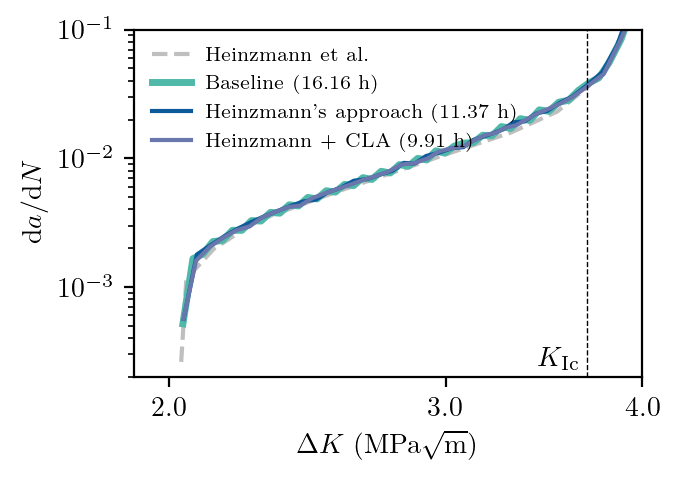

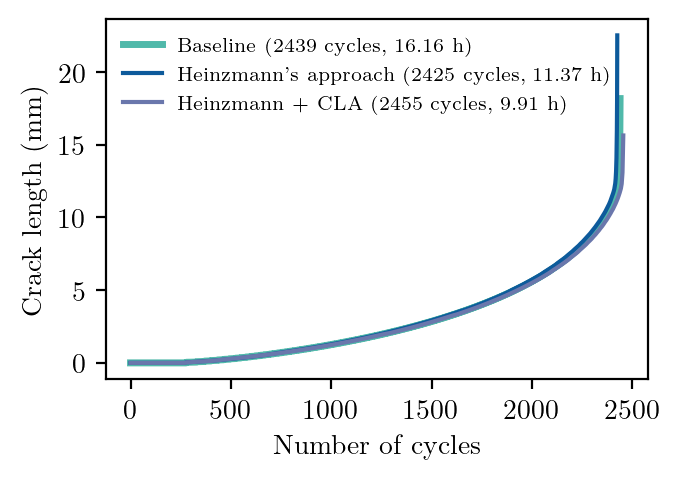

In [951]:
ref_df = pd.read_csv("ref/jonas-ct-100N.csv")

recorded_cycle, lengths, da_dn, delta_k = incremental_growth(n_cycles_jonas_baseline, crack_lengths_jonas_baseline, delta_p=100, T=1, W=50)
recorded_cycle_jonas, lengths_jonas, da_dn_jonas, delta_k_jonas = incremental_growth(n_cycles_jonas_jonas, crack_lengths_jonas_jonas, delta_p=100, T=1, W=50)
recorded_cycle_jonascla, lengths_jonascla, da_dn_jonascla, delta_k_jonascla = incremental_growth(n_cycles_jonas_jonascla, crack_lengths_jonas_jonascla, delta_p=100, T=1, W=50)

plt.figure(figsize=(3.5,2.5), dpi=200)

ax = plt.subplot(111)

delta_k_paris = np.linspace(0.5, 4.0, 100)
da_dn_paris = 0.016*(delta_k_paris)**3.73
# ax.plot(delta_k_paris, da_dn_paris, color="grey", ls="--", alpha=0.5, label=r"Carrara et al.") #$\frac{\mathrm{d}a}{\mathrm{d}N}=0.016(\Delta K)^{3.73}$ 
ax.plot(ref_df["x"], ref_df[" y"], color="grey", ls="--", alpha=0.5, label=r"Heinzmann et al.")

ax.plot(delta_k, da_dn, color=global_palette[1], ls="-", label="Baseline (16.16 h)", alpha=1, lw=2.5)
ax.plot(delta_k_jonas, da_dn_jonas, color=global_palette[2], ls="-", label="Heinzmann's approach (11.37 h)", alpha=1, lw=1.5)
ax.plot(delta_k_jonascla, da_dn_jonascla, color=global_palette[3], ls="-", label="Heinzmann + CLA (9.91 h)", alpha=1, lw=1.5)

# ax.text(0.05, 0.55, r"$a_0/W=0.22$", ha="left", va="top", transform=ax.transAxes)


ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim([1.9, 4.0])
# xlim = ax.get_xlim()
# ax.plot(ax.get_xlim(), [0.04, 0.04], ls="--", lw=0.5, color="grey")
# ax.text(xlim[0]+(xlim[1]-xlim[0])*0.001, 0.04, r"$\frac{\mathrm{d}a}{\mathrm{d}N}=0.04$", ha="left", va="bottom")
ax.set_ylim([2e-4, 1e-1])
ylim = ax.get_ylim()
ax.plot([3.69, 3.69], ax.get_ylim(), ls="--", lw=0.5, color="black")
ax.set_ylim(ylim)
ax.text(3.65, ylim[0]*1.1, r"$K_{\mathrm{Ic}}$", ha="right", va="bottom", transform=ax.transData)
ax.set_xticks([ 2.0, 3.0, 4.0])
ax.set_xticklabels([2.0, 3.0, 4.0])
ax.set_ylabel(r"$\mathrm{d}a/\mathrm{d}N$")
ax.set_xlabel(r"$\Delta K$ (MPa$\sqrt{\mathrm{m}}$)")
# ax.spines["left"].set_color(global_palette[0])
# ax.spines["right"].set_color(global_palette[2])
# ax.tick_params(axis="y", colors=global_palette[0], which="both")
# ax.yaxis.label.set_color(global_palette[0])
ax.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.7)

# ax = ax.twinx()
# ax.plot(delta_k, lengths, color=global_palette[2], ls="-")
# ax.set_ylabel("Crack length (mm)")
# ax.spines["left"].set_color(global_palette[0])
# ax.spines["right"].set_color(global_palette[2])
# ax.tick_params(axis="y", colors=global_palette[2])
# ax.yaxis.label.set_color(global_palette[2])

plt.savefig(os.path.join(plot_root, "jonas-paris.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()


plt.figure(figsize=(3.5,2.5), dpi=200)

ax = plt.subplot(111)
# ax.text(0.05, 0.95, r"$a_0/W=0.22$", ha="left", va="top", transform=ax.transAxes)


# ax.plot(recorded_cycle, da_dn, color=global_palette[0], ls=".", label="Baseline")
# ax.plot(recorded_cycle_jonas, da_dn_jonas, color=global_palette[0], ls="-", label="Jonas et al.")


# ax.set_ylabel(r"$\mathrm{d}a/\mathrm{d}N$")
ax.set_xlabel("Number of cycles")
# ax.spines["left"].set_color(global_palette[0])
# ax.spines["right"].set_color(global_palette[2])
# ax.tick_params(axis="y", colors=global_palette[0], which="both")
# ax.yaxis.label.set_color(global_palette[0])
# ax.set_yscale("log")
# ax.set_xlim([0, 800])
# ax.set_ylim([1e-3, 3])
# xlim = ax.get_xlim()
# ax.plot(ax.get_xlim(), [0.04, 0.04], ls="--", lw=0.5, color="grey")
# ax.text(xlim[0]+(xlim[1]-xlim[0])*0.01, 0.04, r"$\frac{\mathrm{d}a}{\mathrm{d}N}=0.04$", ha="left", va="bottom")

# ax.set_xlim(xlim)
# ax = ax.twinx()
ax.plot(n_cycles_jonas_baseline, crack_lengths_jonas_baseline, color=global_palette[1], ls="-", label=f"Baseline ({n_cycles_jonas_baseline[-1]} cycles, 16.16 h)", alpha=1, lw=2.5)
ax.plot(n_cycles_jonas_jonas, np.array(crack_lengths_jonas_jonas), color=global_palette[2], ls="-", label=f"Heinzmann's approach ({n_cycles_jonas_jonas[-1]} cycles, 5.39 h)", alpha=1, lw=1.5)
ax.plot(n_cycles_jonas_jonascla, np.array(crack_lengths_jonas_jonascla), color=global_palette[3], ls="-", label=f"Heinzmann + CLA ({n_cycles_jonas_jonascla[-1]} cycles, 5.39 h)", alpha=1, lw=1.5)

ax.set_ylabel("Crack length (mm)")
# ax.spines["left"].set_color(global_palette[0])
# ax.spines["right"].set_color(global_palette[2])
# ax.tick_params(axis="y", colors=global_palette[2])
# ax.yaxis.label.set_color(global_palette[2])
ax.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.7)
plt.savefig(os.path.join(plot_root, "jonas-paris-crack-growth-rate.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()

In [157]:
n_cycles_jonas_jonas20, crack_lengths_jonas_jonas20 = get_phi_x_max("output/JonasCTParis20-2024-09-20-18-34-52-jonas", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True)

  0%|          | 0/272 [00:00<?, ?it/s]

In [158]:
n_cycles_jonas_jonascla20, crack_lengths_jonas_jonascla20 = get_phi_x_max("output/JonasCTParis20-2024-09-20-18-35-32-jonascla", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True)

  0%|          | 0/271 [00:00<?, ?it/s]

In [268]:
enumerate_crack_lengths(n_cycles_jonas_jonas20, crack_lengths_jonas_jonas20)

In [269]:
enumerate_crack_lengths(n_cycles_jonas_jonascla20, crack_lengths_jonas_jonascla20)

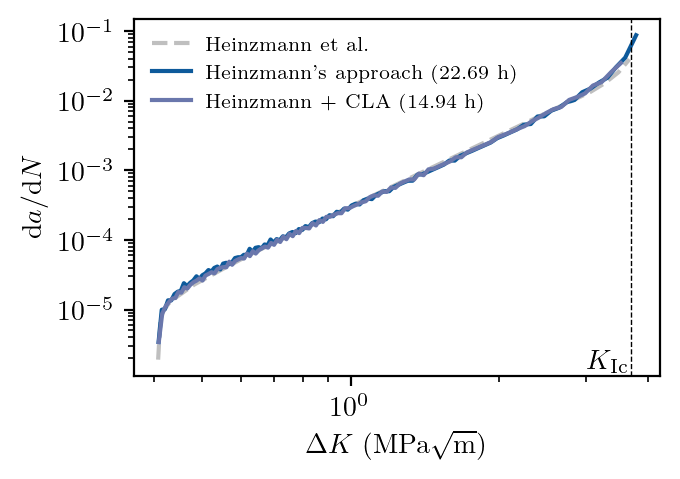

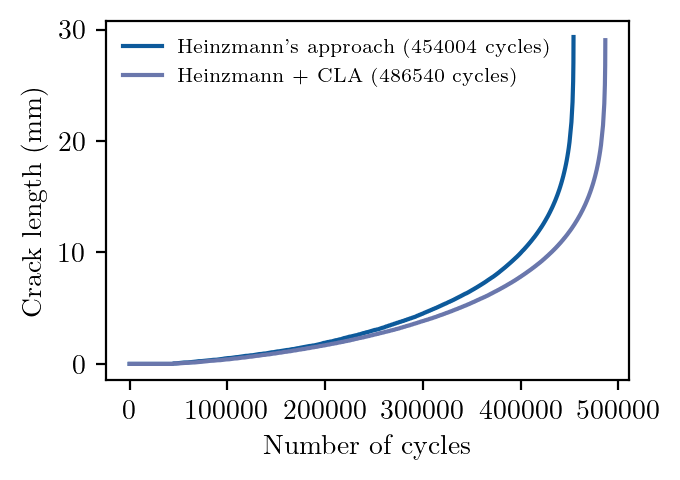

In [956]:
ref_df = pd.read_csv("ref/jonas-ct-20N.csv")

# recorded_cycle, lengths, da_dn, delta_k = incremental_growth(n_cycles_jonas_baseline, crack_lengths_jonas_baseline, delta_p=100, T=1, W=50)
recorded_cycle_jonas20, lengths_jonas20, da_dn_jonas20, delta_k_jonas20 = incremental_growth(n_cycles_jonas_jonas20, crack_lengths_jonas_jonas20, delta_p=20, T=1, W=50)
recorded_cycle_jonascla20, lengths_jonascla20, da_dn_jonascla20, delta_k_jonascla20 = incremental_growth(n_cycles_jonas_jonascla20, crack_lengths_jonas_jonascla20, delta_p=20, T=1, W=50)

plt.figure(figsize=(3.5,2.5), dpi=200)

ax = plt.subplot(111)

delta_k_paris = np.linspace(0.5, 4.0, 100)
da_dn_paris = 0.016*(delta_k_paris)**3.73
# ax.plot(delta_k_paris, da_dn_paris, color="grey", ls="--", alpha=0.5, label=r"Carrara et al.") #$\frac{\mathrm{d}a}{\mathrm{d}N}=0.016(\Delta K)^{3.73}$ 
ax.plot(ref_df["x"], ref_df[" y"], color="grey", ls="--", alpha=0.5, label=r"Heinzmann et al.")

# ax.plot(delta_k, da_dn, color=global_palette[1], ls="-", label="Baseline (16.16 h)", alpha=1, lw=2.5)
ax.plot(delta_k_jonas20, da_dn_jonas20, color=global_palette[2], ls="-", label="Heinzmann's approach (22.69 h)", alpha=1, lw=1.5)
ax.plot(delta_k_jonascla20, da_dn_jonascla20, color=global_palette[3], ls="-", label="Heinzmann + CLA (14.94 h)", alpha=1, lw=1.5)

# ax.text(0.05, 0.55, r"$a_0/W=0.22$", ha="left", va="top", transform=ax.transAxes)


ax.set_xscale("log")
ax.set_yscale("log")
# ax.set_xlim([1.9, 4.0])
# xlim = ax.get_xlim()
# ax.plot(ax.get_xlim(), [0.04, 0.04], ls="--", lw=0.5, color="grey")
# ax.text(xlim[0]+(xlim[1]-xlim[0])*0.001, 0.04, r"$\frac{\mathrm{d}a}{\mathrm{d}N}=0.04$", ha="left", va="bottom")
# ax.set_ylim([2e-4, 1e-1])
ylim = ax.get_ylim()
ax.plot([3.69, 3.69], ax.get_ylim(), ls="--", lw=0.5, color="black")
ax.set_ylim(ylim)
ax.text(3.65, ylim[0]*1.1, r"$K_{\mathrm{Ic}}$", ha="right", va="bottom", transform=ax.transData)
# ax.set_xticks([ 2.0, 3.0, 4.0])
# ax.set_xticklabels([2.0, 3.0, 4.0])
ax.set_ylabel(r"$\mathrm{d}a/\mathrm{d}N$")
ax.set_xlabel(r"$\Delta K$ (MPa$\sqrt{\mathrm{m}}$)")
# ax.spines["left"].set_color(global_palette[0])
# ax.spines["right"].set_color(global_palette[2])
# ax.tick_params(axis="y", colors=global_palette[0], which="both")
# ax.yaxis.label.set_color(global_palette[0])
ax.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.7)

# ax = ax.twinx()
# ax.plot(delta_k, lengths, color=global_palette[2], ls="-")
# ax.set_ylabel("Crack length (mm)")
# ax.spines["left"].set_color(global_palette[0])
# ax.spines["right"].set_color(global_palette[2])
# ax.tick_params(axis="y", colors=global_palette[2])
# ax.yaxis.label.set_color(global_palette[2])

plt.savefig(os.path.join(plot_root, "jonas20-paris.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()


plt.figure(figsize=(3.5,2.5), dpi=200)

ax = plt.subplot(111)
# ax.text(0.05, 0.95, r"$a_0/W=0.22$", ha="left", va="top", transform=ax.transAxes)


# ax.plot(recorded_cycle, da_dn, color=global_palette[0], ls=".", label="Baseline")
# ax.plot(recorded_cycle_jonas, da_dn_jonas, color=global_palette[0], ls="-", label="Jonas et al.")


# ax.set_ylabel(r"$\mathrm{d}a/\mathrm{d}N$")
ax.set_xlabel("Number of cycles")
# ax.spines["left"].set_color(global_palette[0])
# ax.spines["right"].set_color(global_palette[2])
# ax.tick_params(axis="y", colors=global_palette[0], which="both")
# ax.yaxis.label.set_color(global_palette[0])
# ax.set_yscale("log")
# ax.set_xlim([0, 800])
# ax.set_ylim([1e-3, 3])
# xlim = ax.get_xlim()
# ax.plot(ax.get_xlim(), [0.04, 0.04], ls="--", lw=0.5, color="grey")
# ax.text(xlim[0]+(xlim[1]-xlim[0])*0.01, 0.04, r"$\frac{\mathrm{d}a}{\mathrm{d}N}=0.04$", ha="left", va="bottom")

# ax.set_xlim(xlim)
# ax = ax.twinx()
# ax.plot(n_cycles_jonas_baseline, crack_lengths_jonas_baseline, color=global_palette[1], ls="-", label=f"Baseline ({n_cycles_jonas_baseline[-1]} cycles, 16.16 h)", alpha=1, lw=2.5)
ax.plot(n_cycles_jonas_jonas20, np.array(crack_lengths_jonas_jonas20), color=global_palette[2], ls="-", label=f"Heinzmann's approach ({n_cycles_jonas_jonas20[-1]} cycles)", alpha=1, lw=1.5)
ax.plot(n_cycles_jonas_jonascla20, np.array(crack_lengths_jonas_jonascla20), color=global_palette[3], ls="-", label=f"Heinzmann + CLA ({n_cycles_jonas_jonascla20[-1]} cycles)", alpha=1, lw=1.5)

ax.set_ylabel("Crack length (mm)")
# ax.spines["left"].set_color(global_palette[0])
# ax.spines["right"].set_color(global_palette[2])
# ax.tick_params(axis="y", colors=global_palette[2])
# ax.yaxis.label.set_color(global_palette[2])
ax.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.7)
plt.savefig(os.path.join(plot_root, "jonas20-paris-crack-growth-rate.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()

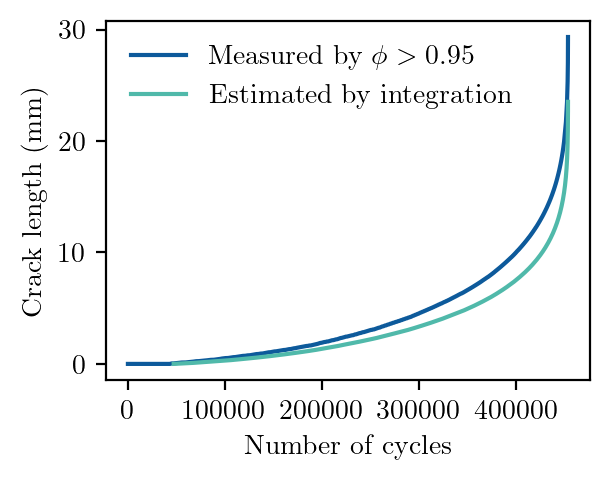

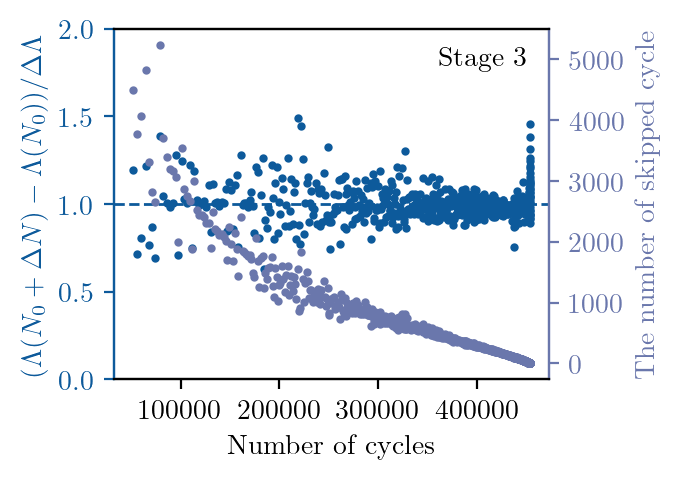

In [913]:
import re

logfile = "output/JonasCTParis-2024-09-09-20-11-12-jonas20/log.txt"

with open(logfile, "r") as file:
    s = file.read()
    monitored = re.findall(r"Trial Delta: (.*?) Expected Delta: (.*?)\nCycle jump is done successfully. The number of jumped cycle: (.*?).\nThe monitored value \(at stage (.*?)\): .*?\.\n.*?\nComputing output \(will be saved to No.(.*?)\)", s)

    estimated_lengths = re.findall(r"The monitored value \(at stage 3\): (.*?).\nThe number of resolved cycles \(including trial cycles\): .*?\nComputing output \(will be saved to No\.(.*?)\)", s)
    # print(estimated_lengths)
plt.figure(figsize=(3.15,2.5), dpi=200)
ax = plt.subplot(111)
ax.plot(n_cycles_jonas_jonas20, np.array(crack_lengths_jonas_jonas20), color=global_palette[2], ls="-", label=r"Measured by $\phi>0.95$", alpha=1, lw=1.5)
ax.plot([float(x[1]) for x in estimated_lengths], [float(x[0]) for x in estimated_lengths], color=global_palette[1], ls="-", label=f"Estimated by integration", alpha=1, lw=1.5)

ax.set_ylabel("Crack length (mm)")
ax.set_xlabel("Number of cycles")
# ax.spines["left"].set_color(global_palette[0])
# ax.spines["right"].set_color(global_palette[2])
# ax.tick_params(axis="y", colors=global_palette[2])
# ax.yaxis.label.set_color(global_palette[2])
ax.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"])
plt.savefig(os.path.join(plot_root, "jonas-crack-length-estimation.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()

plt.figure(figsize=(3.5,2.5), dpi=200)
ax = plt.subplot(111)
ax.plot([float(x[4]) for x in monitored if x[3] == "3"], [float(x[0])/float(x[1]) for x in monitored if x[3] == "3"], color=global_palette[2], ls="-", alpha=1, lw=0, marker="o", markersize=2)
ax.spines["left"].set_color(global_palette[2])
ax.spines["right"].set_color(global_palette[3])
ax.tick_params(axis="y", colors=global_palette[2], which="both")
ax.yaxis.label.set_color(global_palette[2])

xlim = ax.get_xlim()
ax.plot(xlim, [1, 1], lw=1, ls="--", color=global_palette[2], alpha=1, zorder=0)
ax.set_xlim(xlim)

ax.set_ylabel(r"$(\Lambda(N_0+\Delta N)-\Lambda(N_0))/\Delta \Lambda$")
ax.set_xlabel("Number of cycles")
ax.set_ylim([0, 2])

ax.text(0.95, 0.95, r"Stage 3", ha="right", va="top", transform=ax.transAxes)

ax = ax.twinx()
ax.plot([float(x[4]) for x in monitored if x[3] == "3"], [float(x[2]) for x in monitored if x[3] == "3"], color=global_palette[3], ls="-", alpha=1, lw=0, marker="o", markersize=2)
ax.set_ylabel(r"The number of skipped cycle")
ax.spines["left"].set_color(global_palette[2])
ax.spines["right"].set_color(global_palette[3])
ax.tick_params(axis="y", colors=global_palette[3], which="both")
ax.yaxis.label.set_color(global_palette[3])
# ax.spines["left"].set_color(global_palette[0])
# ax.spines["right"].set_color(global_palette[2])
# ax.tick_params(axis="y", colors=global_palette[2])
# ax.yaxis.label.set_color(global_palette[2])
# ax.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"])
# plt.savefig(os.path.join(plot_root, "jonas-cycle-jump-length.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()

In [163]:
n_cycles_mncla_new, crack_lengths_mncla_new = get_phi_x_max("output/singleNotchTensionFatigueKristensen-2024-09-04-13-25-26-MNCLA", crack_tip=0.5, cycle_per_file=50, ylim=[0.3, 0.7])

  0%|          | 0/2401 [00:00<?, ?it/s]

In [164]:
n_cycles_kris_jonas, crack_lengths_kris_jonas = get_phi_x_max("output/singleNotchTensionFatigueKristensen-2024-09-09-08-10-10-jonas", crack_tip=0.5, cycle_per_file=50, ylim=[0.3, 0.7], infer_cycle_by_name=True)

  0%|          | 0/421 [00:00<?, ?it/s]

In [271]:
enumerate_crack_lengths(n_cycles_mncla_new, crack_lengths_mncla_new)

In [270]:
enumerate_crack_lengths(n_cycles_kris_jonas, crack_lengths_kris_jonas)

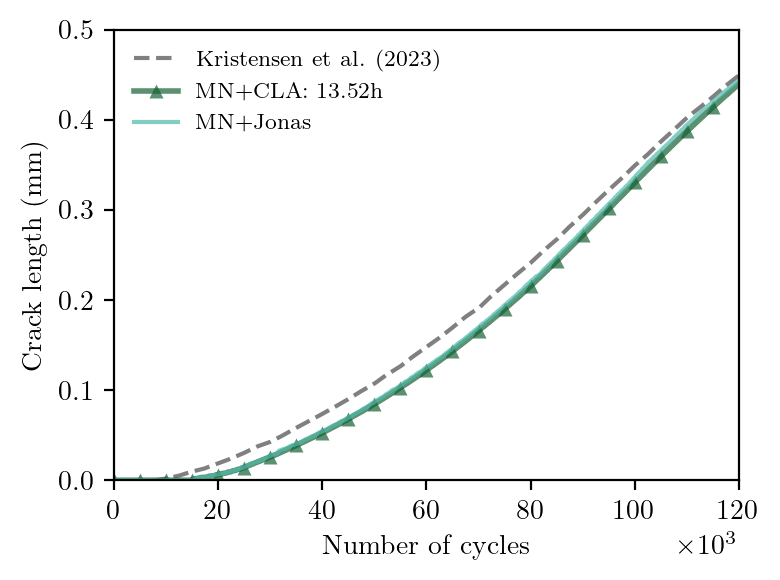

In [902]:
ref_df = pd.read_csv("ref/kristensen-singlenotch.csv")

plt.figure(figsize=(4,3), dpi=200)

ax = plt.subplot(111)
ax.ticklabel_format(axis='x', style='sci', scilimits=(3,3))

ax.plot(ref_df["x"], ref_df[" y"], ls="--", color="grey", label="Kristensen et al. (2023)")
marker_kwargs = dict(markersize=5, markevery=100, markeredgecolor='none')
# ax.plot(np.array(n_cycles_baseline), crack_lengths_baseline, ls="-", marker="^", **marker_kwargs, color=global_palette[0], label=r"Baseline: 69.44h", alpha=0.7, lw=1)
# ax.plot(np.array(n_cycles_split), crack_lengths_split, ls="-", marker="^", **marker_kwargs, color=global_palette[1], label=r"Baseline2", alpha=1, lw=1)
ax.plot(np.array(n_cycles_mncla_new), crack_lengths_mncla_new, ls="-", marker="^", **marker_kwargs, color=global_palette[0], label=r"MN+CLA: 13.52h", alpha=0.7, lw=2)
# ax.plot(np.array(n_cycles_mncla_jump32), crack_lengths_mncla_jump32, ls="-", color=global_palette[1], label=r"MN+CLA, $\Delta N=32$: 1.51h", alpha=0.7)
# ax.plot(np.array(n_cycles_mncla_jump512), crack_lengths_mncla_jump512, ls="-", color=global_palette[2], label=r"MN+CLA, $\Delta N=512$: 1.51h", alpha=0.7)
# ax.plot(np.array(n_cycles_mncla_jump1024), crack_lengths_mncla_jump1024, ls="-", color=global_palette[3], label=r"MN+CLA, $\Delta N=1024$: 1.51h", alpha=0.7)
# ax.plot(np.array(n_cycles_mnjaccon_jump16), crack_lengths_mnjaccon_jump16, ls="-", **marker_kwargs, color=global_palette[1], label=r"MN+jaccon, $\Delta N=16$: 1.51h, 4.19mm", alpha=0.7)
ax.plot(np.array(n_cycles_kris_jonas), crack_lengths_kris_jonas, ls="-", **marker_kwargs, color=global_palette[1], label=r"MN+Jonas", alpha=0.7)

# ax.plot(np.array(n_cycles_half), crack_lengths_half, ls="-")
ax.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.8)
ax.set_xlim([0, 120000])
ax.set_ylim([0, 0.5])
ax.set_xlabel("Number of cycles")
ax.set_ylabel("Crack length (mm)")

plt.savefig(os.path.join(plot_root, "kristensen-singlenotchtension-jonas.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()

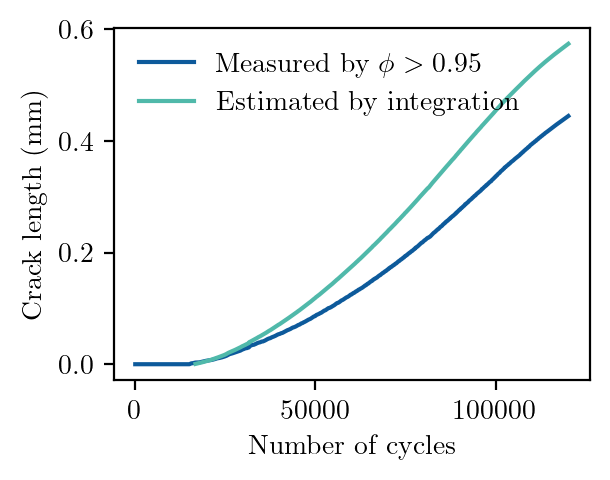

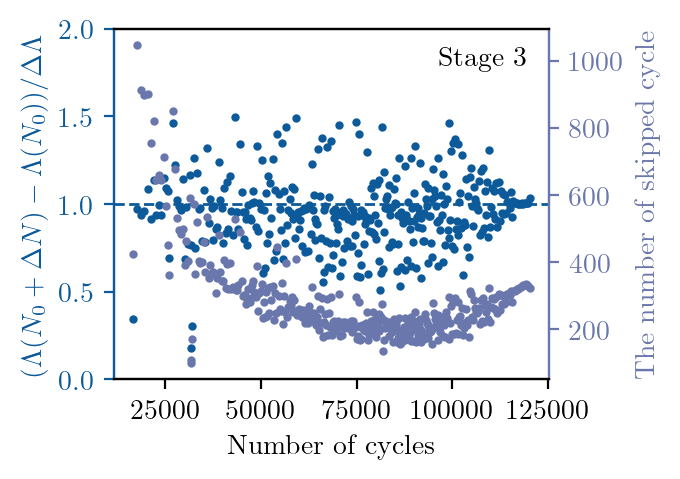

In [903]:
import re

logfile = "output/singleNotchTensionFatigueKristensen-2024-09-09-08-10-10-jonas/log.txt"

with open(logfile, "r") as file:
    s = file.read()
    monitored = re.findall(r"Trial Delta: (.*?) Expected Delta: (.*?)\nCycle jump is done successfully. The number of jumped cycle: (.*?).\nThe monitored value \(at stage (.*?)\): .*?\.\n.*?\nComputing output \(will be saved to No.(.*?)\)", s)

    estimated_lengths = re.findall(r"The monitored value \(at stage 3\): (.*?).\nThe number of resolved cycles \(including trial cycles\): .*?\nComputing output \(will be saved to No\.(.*?)\)", s)
    # print(estimated_lengths)
plt.figure(figsize=(3.15,2.5), dpi=200)
ax = plt.subplot(111)
ax.plot(n_cycles_kris_jonas, np.array(crack_lengths_kris_jonas), color=global_palette[2], ls="-", label=r"Measured by $\phi>0.95$", alpha=1, lw=1.5)
ax.plot([float(x[1]) for x in estimated_lengths], [(float(x[0])) for x in estimated_lengths], color=global_palette[1], ls="-", label=f"Estimated by integration", alpha=1, lw=1.5)

ax.set_ylabel("Crack length (mm)")
ax.set_xlabel("Number of cycles")
# ax.spines["left"].set_color(global_palette[0])
# ax.spines["right"].set_color(global_palette[2])
# ax.tick_params(axis="y", colors=global_palette[2])
# ax.yaxis.label.set_color(global_palette[2])
ax.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"])
# plt.savefig(os.path.join(plot_root, "jonas-crack-length-estimation.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()

plt.figure(figsize=(3.5,2.5), dpi=200)
ax = plt.subplot(111)
ax.plot([float(x[4]) for x in monitored if x[3] == "3"], [float(x[0])/float(x[1]) for x in monitored if x[3] == "3"], color=global_palette[2], ls="-", alpha=1, lw=0, marker="o", markersize=2)
ax.spines["left"].set_color(global_palette[2])
ax.spines["right"].set_color(global_palette[3])
ax.tick_params(axis="y", colors=global_palette[2], which="both")
ax.yaxis.label.set_color(global_palette[2])

xlim = ax.get_xlim()
ax.plot(xlim, [1, 1], lw=1, ls="--", color=global_palette[2], alpha=1, zorder=0)
ax.set_xlim(xlim)

ax.set_ylabel(r"$(\Lambda(N_0+\Delta N)-\Lambda(N_0))/\Delta \Lambda$")
ax.set_xlabel("Number of cycles")
ax.set_ylim([0, 2])

ax.text(0.95, 0.95, r"Stage 3", ha="right", va="top", transform=ax.transAxes)

ax = ax.twinx()
ax.plot([float(x[4]) for x in monitored if x[3] == "3"], [float(x[2]) for x in monitored if x[3] == "3"], color=global_palette[3], ls="-", alpha=1, lw=0, marker="o", markersize=2)
ax.set_ylabel(r"The number of skipped cycle")
ax.spines["left"].set_color(global_palette[2])
ax.spines["right"].set_color(global_palette[3])
ax.tick_params(axis="y", colors=global_palette[3], which="both")
ax.yaxis.label.set_color(global_palette[3])
# ax.spines["left"].set_color(global_palette[0])
# ax.spines["right"].set_color(global_palette[2])
# ax.tick_params(axis="y", colors=global_palette[2])
# ax.yaxis.label.set_color(global_palette[2])
# ax.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"])
# plt.savefig(os.path.join(plot_root, "jonas-cycle-jump-length.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()

## Yang 

In [167]:
n_cycles_yang_baseline, crack_lengths_yang_baseline = get_phi_x_max("output/singleNotchTensionFatigueCarraraYang-2024-08-25-11-24-19-baseline", crack_tip=0.5, cycle_per_file=1)

  0%|          | 0/390 [00:00<?, ?it/s]

In [168]:
n_cycles_yang1, crack_lengths_yang1 = get_phi_x_max("output/singleNotchTensionFatigueCarraraYang-2024-08-27-04-13-19-yang1", crack_tip=0.5, cycle_per_file=1, infer_cycle_by_name=True)

  0%|          | 0/222 [00:00<?, ?it/s]

In [169]:
n_cycles_yang2, crack_lengths_yang2 = get_phi_x_max("output/singleNotchTensionFatigueCarraraYang-2024-08-27-04-13-35-yang2", crack_tip=0.5, cycle_per_file=1, infer_cycle_by_name=True)

  0%|          | 0/150 [00:00<?, ?it/s]

In [170]:
n_cycles_yang4, crack_lengths_yang4 = get_phi_x_max("output/singleNotchTensionFatigueCarraraYang-2024-08-27-23-27-03-yang4", crack_tip=0.5, cycle_per_file=1, infer_cycle_by_name=True)

  0%|          | 0/75 [00:00<?, ?it/s]

In [171]:
n_cycles_yang3, crack_lengths_yang3 = get_phi_x_max("output/singleNotchTensionFatigueCarraraYang-2024-08-27-04-13-54-yang3", crack_tip=0.5, cycle_per_file=1, infer_cycle_by_name=True)

  0%|          | 0/97 [00:00<?, ?it/s]

In [172]:
n_cycles_yang5, crack_lengths_yang5 = get_phi_x_max("output/singleNotchTensionFatigueCarraraYang-2024-08-27-16-14-57-yang5", crack_tip=0.5, cycle_per_file=1, infer_cycle_by_name=True)

  0%|          | 0/59 [00:00<?, ?it/s]

In [272]:
enumerate_crack_lengths(n_cycles_yang_baseline, crack_lengths_yang_baseline)
enumerate_crack_lengths(n_cycles_yang1, crack_lengths_yang1)
enumerate_crack_lengths(n_cycles_yang5, crack_lengths_yang5)

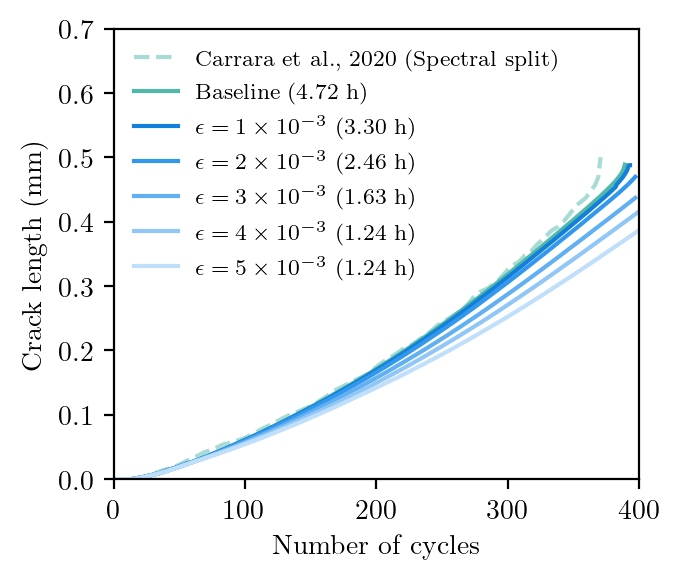

In [124]:
ref_df = pd.read_csv("ref/carrara-singlenotch-spectral.csv")

plt.figure(figsize=(3.5,3), dpi=200)

ax = plt.subplot(111)
ax.plot(ref_df["x"], ref_df[" y"], ls="--", color=global_palette[1], label="Carrara et al., 2020 (Spectral split)", alpha=0.5)
ax.plot(np.array(n_cycles_yang_baseline)[:390], np.array(crack_lengths_yang_baseline)[:390], ls="-", color=global_palette[1], label="Baseline (4.72 h)")
ax.plot(np.array(n_cycles_yang1), np.array(crack_lengths_yang1), ls="-", color=lighten_color(global_palette[2], 0.8), label=r"$\epsilon=1\times 10^{-3}$ (3.30 h)")
ax.plot(np.array(n_cycles_yang2), np.array(crack_lengths_yang2), ls="-", color=lighten_color(global_palette[2], 0.65), label=r"$\epsilon=2\times 10^{-3}$ (2.46 h)")
ax.plot(np.array(n_cycles_yang3), np.array(crack_lengths_yang3), ls="-", color=lighten_color(global_palette[2], 0.5), label=r"$\epsilon=3\times 10^{-3}$ (1.63 h)")
ax.plot(np.array(n_cycles_yang4), np.array(crack_lengths_yang4), ls="-", color=lighten_color(global_palette[2], 0.35), label=r"$\epsilon=4\times 10^{-3}$ (1.24 h)")
ax.plot(np.array(n_cycles_yang5), np.array(crack_lengths_yang5), ls="-", color=lighten_color(global_palette[2], 0.2), label=r"$\epsilon=5\times 10^{-3}$ (1.24 h)")
ax.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.8)
ax.set_xlim([0, 400])
ax.set_ylim([0, 0.7])
ax.set_xlabel("Number of cycles")
ax.set_ylabel("Crack length (mm)")
plt.savefig(os.path.join(plot_root, "carrara-singlenotch-spectral-yang.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()

In [179]:
n_cycles_yang_tpb_baseline, crack_lengths_yang_tpb_baseline = get_phi_x_max("output/threepointbendYang-2024-08-26-08-29-57-baseline", crack_tip=0.4, cycle_per_file=10, direction="up")

  0%|          | 0/201 [00:00<?, ?it/s]

In [180]:
n_cycles_yang_tpb_1, crack_lengths_yang_tpb_1 = get_phi_x_max("output/threepointbendYang-2024-08-27-21-31-25-yang1", crack_tip=0.4, cycle_per_file=1, infer_cycle_by_name=True, direction="up")

  0%|          | 0/77 [00:00<?, ?it/s]

In [181]:
n_cycles_yang_tpb_2, crack_lengths_yang_tpb_2 = get_phi_x_max("output/threepointbendYang-2024-08-27-23-26-09-yang2", crack_tip=0.4, cycle_per_file=1, infer_cycle_by_name=True, direction="up")

  0%|          | 0/47 [00:00<?, ?it/s]

In [182]:
n_cycles_yang_tpb_3, crack_lengths_yang_tpb_3 = get_phi_x_max("output/threepointbendYang-2024-08-27-23-27-23-yang3", crack_tip=0.4, cycle_per_file=1, infer_cycle_by_name=True, direction="up")

  0%|          | 0/35 [00:00<?, ?it/s]

In [183]:
n_cycles_yang_tpb_4, crack_lengths_yang_tpb_4 = get_phi_x_max("output/threepointbendYang-2024-08-27-23-27-50-yang4", crack_tip=0.4, cycle_per_file=1, infer_cycle_by_name=True, direction="up")

  0%|          | 0/28 [00:00<?, ?it/s]

In [273]:
enumerate_crack_lengths(n_cycles_yang_tpb_baseline, crack_lengths_yang_tpb_baseline)
enumerate_crack_lengths(n_cycles_yang_tpb_1, crack_lengths_yang_tpb_1)
enumerate_crack_lengths(n_cycles_yang_tpb_4, crack_lengths_yang_tpb_4)

In [37]:
ref_df_yang_dns = pd.read_csv("ref/yang-tpb-dns.csv")
ref_df_yang_proposed = pd.read_csv("ref/yang-tpb-proposed.csv")

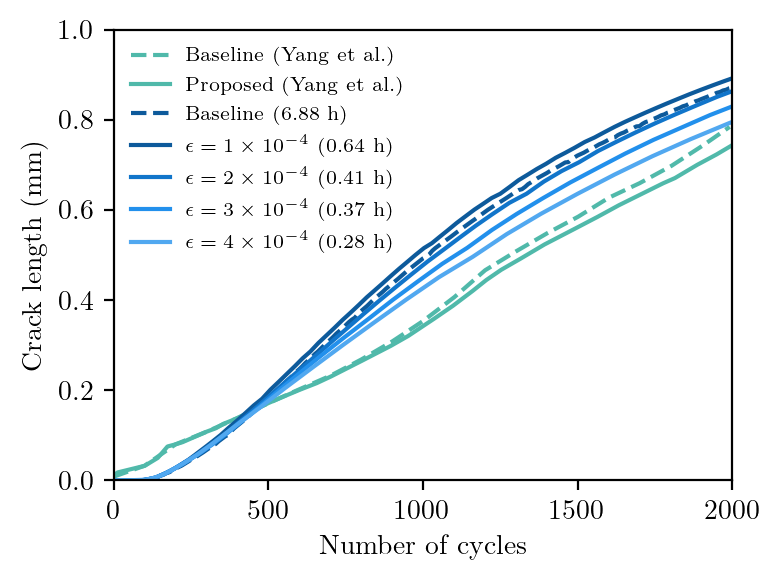

In [45]:
plt.figure(figsize=(4,3), dpi=200)

ax = plt.subplot(111)
ax.plot(ref_df_yang_dns["x"], ref_df_yang_dns[" y"], ls="--", color=global_palette[1], label="Baseline (Yang et al.)", alpha=1)
ax.plot(ref_df_yang_proposed["x"], ref_df_yang_proposed[" y"], ls="-", color=global_palette[1], label="Proposed (Yang et al.)", alpha=1)
ax.plot(np.array(n_cycles_yang_tpb_baseline), np.array(crack_lengths_yang_tpb_baseline), ls="--", color=global_palette[2], label="Baseline (6.88 h)")
ax.plot(np.array(n_cycles_yang_tpb_1), np.array(crack_lengths_yang_tpb_1), ls="-", color=lighten_color(global_palette[2], 1), label=r"$\epsilon=1\times 10^{-4}$ (0.64 h)")
ax.plot(np.array(n_cycles_yang_tpb_2), np.array(crack_lengths_yang_tpb_2), ls="-", color=lighten_color(global_palette[2], 0.85), label=r"$\epsilon=2\times 10^{-4}$ (0.41 h)")
ax.plot(np.array(n_cycles_yang_tpb_3), np.array(crack_lengths_yang_tpb_3), ls="-", color=lighten_color(global_palette[2], 0.7), label=r"$\epsilon=3\times 10^{-4}$ (0.37 h)")
ax.plot(np.array(n_cycles_yang_tpb_4), np.array(crack_lengths_yang_tpb_4), ls="-", color=lighten_color(global_palette[2], 0.55), label=r"$\epsilon=4\times 10^{-4}$ (0.28 h)")

ax.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.7)
ax.set_xlim([0, 2000])
ax.set_ylim([0, 1])
ax.set_xlabel("Number of cycles")
ax.set_ylabel("Crack length (mm)")
# ax.grid(True)
plt.savefig(os.path.join(plot_root, "threepointbend-yang.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()

## Li

In [4]:
W=50
n_cycles_jonas_baseline, crack_lengths_jonas_baseline = get_phi_x_max("output/JonasCTParis-2024-09-05-14-14-24-corrected", crack_tip=(0.25+0.22)*W, cycle_per_file=1, read_every=20)

  0%|          | 0/123 [00:00<?, ?it/s]

In [17]:
n_cycles_jonas_li, crack_lengths_jonas_li = get_phi_x_max("output/JonasCTParis100-2025-06-04-22-50-55", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True)

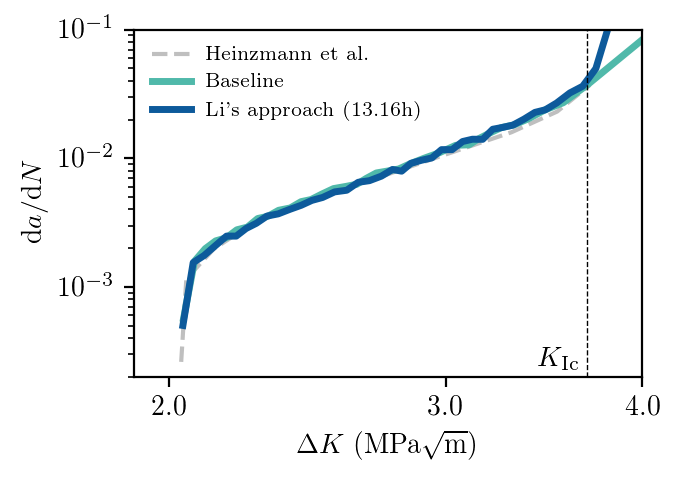

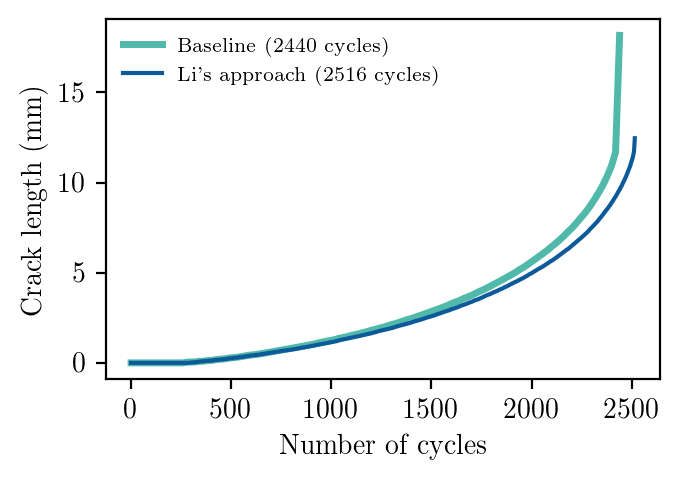

In [19]:
ref_df = pd.read_csv("ref/jonas-ct-100N.csv")

recorded_cycle, lengths, da_dn, delta_k = incremental_growth(n_cycles_jonas_baseline, crack_lengths_jonas_baseline, delta_p=100, T=1, W=50)
recorded_cycle_li, lengths_li, da_dn_li, delta_k_li = incremental_growth(n_cycles_jonas_li, crack_lengths_jonas_li, delta_p=100, T=1, W=50)

plt.figure(figsize=(3.5,2.5), dpi=200)

ax = plt.subplot(111)

delta_k_paris = np.linspace(0.5, 4.0, 100)
da_dn_paris = 0.016*(delta_k_paris)**3.73
# ax.plot(delta_k_paris, da_dn_paris, color="grey", ls="--", alpha=0.5, label=r"Carrara et al.") #$\frac{\mathrm{d}a}{\mathrm{d}N}=0.016(\Delta K)^{3.73}$ 
ax.plot(ref_df["x"], ref_df[" y"], color="grey", ls="--", alpha=0.5, label=r"Heinzmann et al.")

ax.plot(delta_k, da_dn, color=global_palette[1], ls="-", label="Baseline", alpha=1, lw=2.5)
ax.plot(delta_k_li, da_dn_li, color=global_palette[2], ls="-", label="Li's approach (13.16h)", alpha=1, lw=2.5)
# ax.text(0.05, 0.55, r"$a_0/W=0.22$", ha="left", va="top", transform=ax.transAxes)


ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim([1.9, 4.0])
# xlim = ax.get_xlim()
# ax.plot(ax.get_xlim(), [0.04, 0.04], ls="--", lw=0.5, color="grey")
# ax.text(xlim[0]+(xlim[1]-xlim[0])*0.001, 0.04, r"$\frac{\mathrm{d}a}{\mathrm{d}N}=0.04$", ha="left", va="bottom")
ax.set_ylim([2e-4, 1e-1])
ylim = ax.get_ylim()
ax.plot([3.69, 3.69], ax.get_ylim(), ls="--", lw=0.5, color="black")
ax.set_ylim(ylim)
ax.text(3.65, ylim[0]*1.1, r"$K_{\mathrm{Ic}}$", ha="right", va="bottom", transform=ax.transData)
ax.set_xticks([ 2.0, 3.0, 4.0])
ax.set_xticklabels([2.0, 3.0, 4.0])
ax.set_ylabel(r"$\mathrm{d}a/\mathrm{d}N$")
ax.set_xlabel(r"$\Delta K$ (MPa$\sqrt{\mathrm{m}}$)")
# ax.spines["left"].set_color(global_palette[0])
# ax.spines["right"].set_color(global_palette[2])
# ax.tick_params(axis="y", colors=global_palette[0], which="both")
# ax.yaxis.label.set_color(global_palette[0])
ax.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.7)

# ax = ax.twinx()
# ax.plot(delta_k, lengths, color=global_palette[2], ls="-")
# ax.set_ylabel("Crack length (mm)")
# ax.spines["left"].set_color(global_palette[0])
# ax.spines["right"].set_color(global_palette[2])
# ax.tick_params(axis="y", colors=global_palette[2])
# ax.yaxis.label.set_color(global_palette[2])

plt.savefig(os.path.join(plot_root, "jonas-paris-li.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()


plt.figure(figsize=(3.5,2.5), dpi=200)

ax = plt.subplot(111)
# ax.text(0.05, 0.95, r"$a_0/W=0.22$", ha="left", va="top", transform=ax.transAxes)


# ax.plot(recorded_cycle, da_dn, color=global_palette[0], ls=".", label="Baseline")
# ax.plot(recorded_cycle_jonas, da_dn_jonas, color=global_palette[0], ls="-", label="Jonas et al.")


# ax.set_ylabel(r"$\mathrm{d}a/\mathrm{d}N$")
ax.set_xlabel("Number of cycles")
# ax.spines["left"].set_color(global_palette[0])
# ax.spines["right"].set_color(global_palette[2])
# ax.tick_params(axis="y", colors=global_palette[0], which="both")
# ax.yaxis.label.set_color(global_palette[0])
# ax.set_yscale("log")
# ax.set_xlim([0, 800])
# ax.set_ylim([1e-3, 3])
# xlim = ax.get_xlim()
# ax.plot(ax.get_xlim(), [0.04, 0.04], ls="--", lw=0.5, color="grey")
# ax.text(xlim[0]+(xlim[1]-xlim[0])*0.01, 0.04, r"$\frac{\mathrm{d}a}{\mathrm{d}N}=0.04$", ha="left", va="bottom")

# ax.set_xlim(xlim)
# ax = ax.twinx()
ax.plot(n_cycles_jonas_baseline, crack_lengths_jonas_baseline, color=global_palette[1], ls="-", label=f"Baseline ({n_cycles_jonas_baseline[-1]} cycles)", alpha=1, lw=2.5)
ax.plot(n_cycles_jonas_li, np.array(crack_lengths_jonas_li), color=global_palette[2], ls="-", label=f"Li's approach ({n_cycles_jonas_li[-1]} cycles)", alpha=1, lw=1.5)

ax.set_ylabel("Crack length (mm)")
# ax.spines["left"].set_color(global_palette[0])
# ax.spines["right"].set_color(global_palette[2])
# ax.tick_params(axis="y", colors=global_palette[2])
# ax.yaxis.label.set_color(global_palette[2])
ax.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.7)
plt.savefig(os.path.join(plot_root, "jonas-paris-crack-growth-rate-li.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()

In [4]:
W=50
n_cycles_jonas_cojocaru1st, crack_lengths_jonas_cojocaru1st = get_phi_x_max("output/JonasCTParis100-2025-05-18-21-18-09", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True)

  0%|          | 0/30 [00:00<?, ?it/s]

In [5]:
n_cycles_jonas_li1st, crack_lengths_jonas_li1st = get_phi_x_max("output/JonasCTParis100-2025-06-07-14-17-26", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True)

  0%|          | 0/158 [00:00<?, ?it/s]

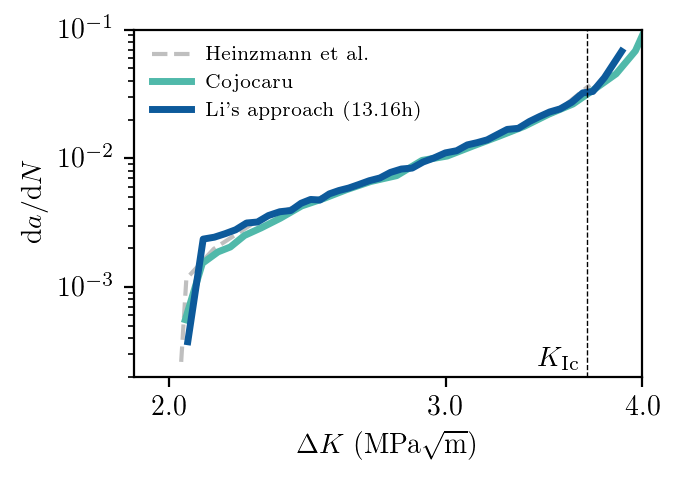

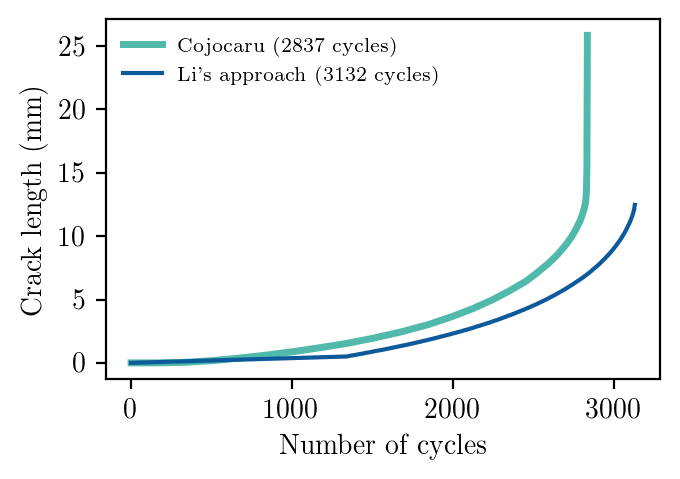

In [7]:
ref_df = pd.read_csv("ref/jonas-ct-100N.csv")

recorded_cycle_cojocaru1st, lengths_cojocaru1st, da_dn, delta_k = incremental_growth(n_cycles_jonas_cojocaru1st, crack_lengths_jonas_cojocaru1st, delta_p=100, T=1, W=50)
recorded_cycle_li, lengths_li, da_dn_li, delta_k_li = incremental_growth(n_cycles_jonas_li1st, crack_lengths_jonas_li1st, delta_p=100, T=1, W=50)

plt.figure(figsize=(3.5,2.5), dpi=200)

ax = plt.subplot(111)

delta_k_paris = np.linspace(0.5, 4.0, 100)
da_dn_paris = 0.016*(delta_k_paris)**3.73
# ax.plot(delta_k_paris, da_dn_paris, color="grey", ls="--", alpha=0.5, label=r"Carrara et al.") #$\frac{\mathrm{d}a}{\mathrm{d}N}=0.016(\Delta K)^{3.73}$ 
ax.plot(ref_df["x"], ref_df[" y"], color="grey", ls="--", alpha=0.5, label=r"Heinzmann et al.")

ax.plot(delta_k, da_dn, color=global_palette[1], ls="-", label="Cojocaru", alpha=1, lw=2.5)
ax.plot(delta_k_li, da_dn_li, color=global_palette[2], ls="-", label="Li's approach (13.16h)", alpha=1, lw=2.5)
# ax.text(0.05, 0.55, r"$a_0/W=0.22$", ha="left", va="top", transform=ax.transAxes)


ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim([1.9, 4.0])
# xlim = ax.get_xlim()
# ax.plot(ax.get_xlim(), [0.04, 0.04], ls="--", lw=0.5, color="grey")
# ax.text(xlim[0]+(xlim[1]-xlim[0])*0.001, 0.04, r"$\frac{\mathrm{d}a}{\mathrm{d}N}=0.04$", ha="left", va="bottom")
ax.set_ylim([2e-4, 1e-1])
ylim = ax.get_ylim()
ax.plot([3.69, 3.69], ax.get_ylim(), ls="--", lw=0.5, color="black")
ax.set_ylim(ylim)
ax.text(3.65, ylim[0]*1.1, r"$K_{\mathrm{Ic}}$", ha="right", va="bottom", transform=ax.transData)
ax.set_xticks([ 2.0, 3.0, 4.0])
ax.set_xticklabels([2.0, 3.0, 4.0])
ax.set_ylabel(r"$\mathrm{d}a/\mathrm{d}N$")
ax.set_xlabel(r"$\Delta K$ (MPa$\sqrt{\mathrm{m}}$)")
# ax.spines["left"].set_color(global_palette[0])
# ax.spines["right"].set_color(global_palette[2])
# ax.tick_params(axis="y", colors=global_palette[0], which="both")
# ax.yaxis.label.set_color(global_palette[0])
ax.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.7)

# ax = ax.twinx()
# ax.plot(delta_k, lengths, color=global_palette[2], ls="-")
# ax.set_ylabel("Crack length (mm)")
# ax.spines["left"].set_color(global_palette[0])
# ax.spines["right"].set_color(global_palette[2])
# ax.tick_params(axis="y", colors=global_palette[2])
# ax.yaxis.label.set_color(global_palette[2])

plt.savefig(os.path.join(plot_root, "jonas-paris-li.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()


plt.figure(figsize=(3.5,2.5), dpi=200)

ax = plt.subplot(111)
# ax.text(0.05, 0.95, r"$a_0/W=0.22$", ha="left", va="top", transform=ax.transAxes)


# ax.plot(recorded_cycle, da_dn, color=global_palette[0], ls=".", label="Baseline")
# ax.plot(recorded_cycle_jonas, da_dn_jonas, color=global_palette[0], ls="-", label="Jonas et al.")


# ax.set_ylabel(r"$\mathrm{d}a/\mathrm{d}N$")
ax.set_xlabel("Number of cycles")
# ax.spines["left"].set_color(global_palette[0])
# ax.spines["right"].set_color(global_palette[2])
# ax.tick_params(axis="y", colors=global_palette[0], which="both")
# ax.yaxis.label.set_color(global_palette[0])
# ax.set_yscale("log")
# ax.set_xlim([0, 800])
# ax.set_ylim([1e-3, 3])
# xlim = ax.get_xlim()
# ax.plot(ax.get_xlim(), [0.04, 0.04], ls="--", lw=0.5, color="grey")
# ax.text(xlim[0]+(xlim[1]-xlim[0])*0.01, 0.04, r"$\frac{\mathrm{d}a}{\mathrm{d}N}=0.04$", ha="left", va="bottom")

# ax.set_xlim(xlim)
# ax = ax.twinx()
ax.plot(n_cycles_jonas_cojocaru1st, crack_lengths_jonas_cojocaru1st, color=global_palette[1], ls="-", label=f"Cojocaru ({n_cycles_jonas_cojocaru1st[-1]} cycles)", alpha=1, lw=2.5)
ax.plot(n_cycles_jonas_li1st, np.array(crack_lengths_jonas_li1st), color=global_palette[2], ls="-", label=f"Li's approach ({n_cycles_jonas_li1st[-1]} cycles)", alpha=1, lw=1.5)

ax.set_ylabel("Crack length (mm)")
# ax.spines["left"].set_color(global_palette[0])
# ax.spines["right"].set_color(global_palette[2])
# ax.tick_params(axis="y", colors=global_palette[2])
# ax.yaxis.label.set_color(global_palette[2])
ax.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.7)
# plt.savefig(os.path.join(plot_root, "jonas-paris-crack-growth-rate-li.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()

## Jaccon

In [8]:
W=50
n_cycles, crack_lengths = get_phi_x_max("output/CarraraCTParis-2024-09-05-14-11-21-corrected", crack_tip=(0.25+0.22)*W, cycle_per_file=1)

  0%|          | 0/854 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
n_cycles_jaccon, crack_lengths_jaccon = get_phi_x_max("output/CarraraCTParis-2024-09-05-14-12-47-jaccon", crack_tip=(0.25+0.22)*W, infer_cycle_by_name=True)
# n_cycles_jonas2, crack_lengths_jonas2 = get_phi_x_max("output/CarraraCTParis-2024-08-20-07-54-39", crack_tip=(0.25+0.22)*W, cycle_per_file=1)

  0%|          | 0/94 [00:00<?, ?it/s]

In [ ]:
enumerate_crack_lengths(n_cycles_jaccon, crack_lengths_jaccon)

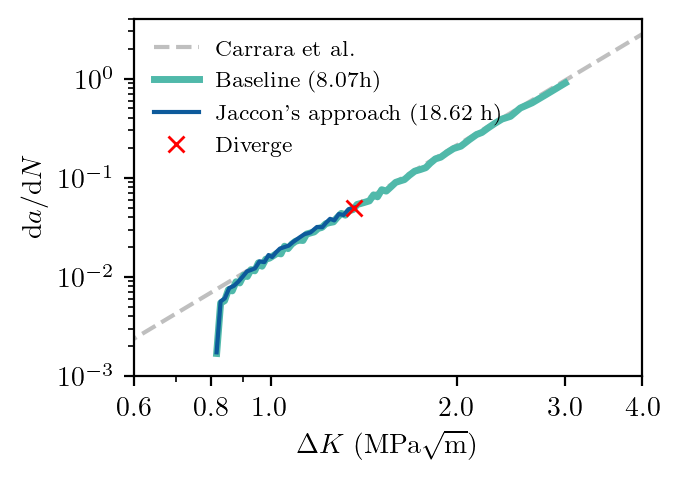

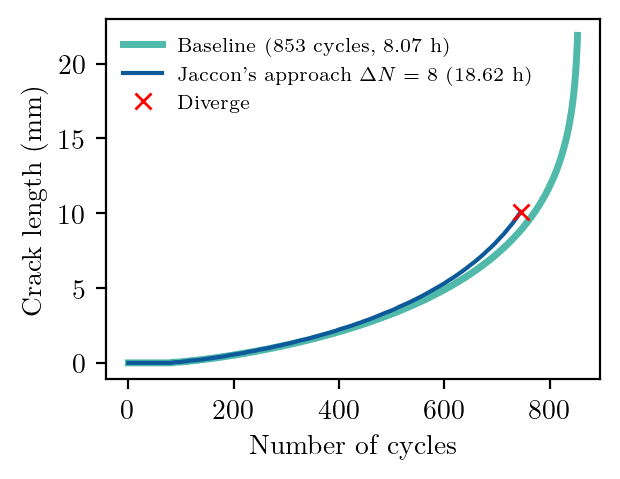

In [ ]:
recorded_cycle, lengths, da_dn, delta_k = incremental_growth(n_cycles, crack_lengths, delta_p=40, T=1, W=50)
recorded_cycle_jaccon, lengths_jaccon, da_dn_jaccon, delta_k_jaccon = incremental_growth(n_cycles_jaccon, crack_lengths_jaccon, delta_p=40, T=1, W=50)

plt.figure(figsize=(3.5,2.5), dpi=200)

ax = plt.subplot(111)

delta_k_paris = np.linspace(0.5, 4.0, 100)
da_dn_paris = 0.016*(delta_k_paris)**3.73
ax.plot(delta_k_paris, da_dn_paris, color="grey", ls="--", alpha=0.5, label=r"Carrara et al.") #$\frac{\mathrm{d}a}{\mathrm{d}N}=0.016(\Delta K)^{3.73}$ 


ax.plot(delta_k, da_dn, color=global_palette[1], ls="-", label="Baseline (8.07h)", alpha=1, lw=2.5)
ax.plot(delta_k_jaccon, da_dn_jaccon, color=global_palette[2], ls="-", label="Jaccon's approach (18.62 h)", alpha=1, lw=1.5)
ax.plot(delta_k_jaccon[-1:], da_dn_jaccon[-1:], color="red", ls="-", marker="x", label=f"Diverge", alpha=1, lw=0)

# ax.text(0.05, 0.55, r"$a_0/W=0.22$", ha="left", va="top", transform=ax.transAxes)


ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim([0.6, 4.0])
# xlim = ax.get_xlim()
# ax.plot(ax.get_xlim(), [0.04, 0.04], ls="--", lw=0.5, color="grey")
# ax.text(xlim[0]+(xlim[1]-xlim[0])*0.001, 0.04, r"$\frac{\mathrm{d}a}{\mathrm{d}N}=0.04$", ha="left", va="bottom")

# ax.set_xlim(xlim)
ax.set_ylim([1e-3, 4])
ax.set_xticks([ 0.6, 0.8, 1.0, 2.0, 3.0, 4.0])
ax.set_xticklabels([0.6, 0.8, 1.0, 2.0, 3.0, 4.0])
ax.set_ylabel(r"$\mathrm{d}a/\mathrm{d}N$")
ax.set_xlabel(r"$\Delta K$ (MPa$\sqrt{\mathrm{m}}$)")
# ax.spines["left"].set_color(global_palette[0])
# ax.spines["right"].set_color(global_palette[2])
# ax.tick_params(axis="y", colors=global_palette[0], which="both")
# ax.yaxis.label.set_color(global_palette[0])
ax.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.8)

# ax = ax.twinx()
# ax.plot(delta_k, lengths, color=global_palette[2], ls="-")
# ax.set_ylabel("Crack length (mm)")
# ax.spines["left"].set_color(global_palette[0])
# ax.spines["right"].set_color(global_palette[2])
# ax.tick_params(axis="y", colors=global_palette[2])
# ax.yaxis.label.set_color(global_palette[2])

plt.savefig(os.path.join(plot_root, "jaccon-carrara-paris.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()


plt.figure(figsize=(3.2,2.5), dpi=200)

ax = plt.subplot(111)
# ax.text(0.05, 0.95, r"$a_0/W=0.22$", ha="left", va="top", transform=ax.transAxes)


# ax.plot(recorded_cycle, da_dn, color=global_palette[0], ls=".", label="Baseline")
# ax.plot(recorded_cycle_jonas, da_dn_jonas, color=global_palette[0], ls="-", label="Jonas et al.")


# ax.set_ylabel(r"$\mathrm{d}a/\mathrm{d}N$")
ax.set_xlabel("Number of cycles")
# ax.spines["left"].set_color(global_palette[0])
# ax.spines["right"].set_color(global_palette[2])
# ax.tick_params(axis="y", colors=global_palette[0], which="both")
# ax.yaxis.label.set_color(global_palette[0])
# ax.set_yscale("log")
# ax.set_xlim([0, 800])
# ax.set_ylim([1e-3, 3])
# xlim = ax.get_xlim()
# ax.plot(ax.get_xlim(), [0.04, 0.04], ls="--", lw=0.5, color="grey")
# ax.text(xlim[0]+(xlim[1]-xlim[0])*0.01, 0.04, r"$\frac{\mathrm{d}a}{\mathrm{d}N}=0.04$", ha="left", va="bottom")

# ax.set_xlim(xlim)
# ax = ax.twinx()
ax.plot(n_cycles, crack_lengths, color=global_palette[1], ls="-", label=f"Baseline ({n_cycles[-1]} cycles, 8.07 h)", alpha=1, lw=2.5)
ax.plot(n_cycles_jaccon, np.array(crack_lengths_jaccon), color=global_palette[2], ls="-", label=f"Jaccon's approach" + r" $\Delta N = 8$ (18.62 h)", alpha=1, lw=1.5)
ax.plot(n_cycles_jaccon[-1:], np.array(crack_lengths_jaccon)[-1:], color="red", ls="-", marker="x", label=f"Diverge", alpha=1, lw=0)

ax.set_ylabel("Crack length (mm)")
# ax.spines["left"].set_color(global_palette[0])
# ax.spines["right"].set_color(global_palette[2])
# ax.tick_params(axis="y", colors=global_palette[2])
# ax.yaxis.label.set_color(global_palette[2])
ax.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.7)
plt.savefig(os.path.join(plot_root, "jaccon-carrara-paris-crack-growth-rate.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()

In [ ]:
n_cycles_mncla_jump32, crack_lengths_mncla_jump32 = get_phi_x_max("output/singleNotchTensionFatigueKristensen-2024-09-04-13-25-53-jump32", crack_tip=0.5, cycle_per_file=50, ylim=[0.3, 0.7], infer_cycle_by_name=True)
n_cycles_mncla_jump512, crack_lengths_mncla_jump512 = get_phi_x_max("output/singleNotchTensionFatigueKristensen-2024-09-04-08-11-38-jump512", crack_tip=0.5, cycle_per_file=50, ylim=[0.3, 0.7], infer_cycle_by_name=True)
n_cycles_mncla_jump1024, crack_lengths_mncla_jump1024 = get_phi_x_max("output/singleNotchTensionFatigueKristensen-2024-09-04-20-13-50-jump1024", crack_tip=0.5, cycle_per_file=50, ylim=[0.3, 0.7], infer_cycle_by_name=True)

  0%|          | 0/1876 [00:00<?, ?it/s]

  0%|          | 0/236 [00:00<?, ?it/s]

  0%|          | 0/119 [00:00<?, ?it/s]

In [ ]:
enumerate_crack_lengths(n_cycles_mncla_jump32, crack_lengths_mncla_jump32)
enumerate_crack_lengths(n_cycles_mncla_jump512, crack_lengths_mncla_jump512)
enumerate_crack_lengths(n_cycles_mncla_jump1024, crack_lengths_mncla_jump1024)

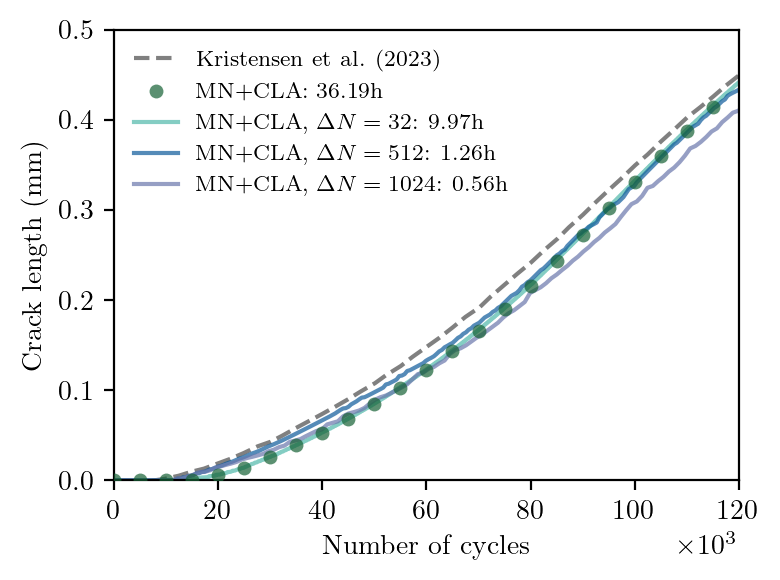

In [ ]:
ref_df = pd.read_csv("ref/kristensen-singlenotch.csv")

plt.figure(figsize=(4,3), dpi=200)

ax = plt.subplot(111)
ax.ticklabel_format(axis='x', style='sci', scilimits=(3,3))

ax.plot(ref_df["x"], ref_df[" y"], ls="--", color="grey", label="Kristensen et al. (2023)")
marker_kwargs = dict(markersize=5, markevery=100, markeredgecolor='none')
# ax.plot(np.array(n_cycles_baseline), crack_lengths_baseline, ls="-", marker="^", **marker_kwargs, color=global_palette[0], label=r"Baseline: 69.44h", alpha=0.7, lw=1)
# ax.plot(np.array(n_cycles_split), crack_lengths_split, ls="-", marker="^", **marker_kwargs, color=global_palette[1], label=r"Baseline2", alpha=1, lw=1)
ax.plot(np.array(n_cycles_mncla_new), crack_lengths_mncla_new, ls="-", marker="o", **marker_kwargs, color=global_palette[0], label=r"MN+CLA: 36.19h", alpha=0.7, lw=0,zorder=10)
ax.plot(np.array(n_cycles_mncla_jump32), crack_lengths_mncla_jump32, ls="-", color=global_palette[1], label=r"MN+CLA, $\Delta N=32$: 9.97h", alpha=0.7)
ax.plot(np.array(n_cycles_mncla_jump512), crack_lengths_mncla_jump512, ls="-", color=global_palette[2], label=r"MN+CLA, $\Delta N=512$: 1.26h", alpha=0.7)
ax.plot(np.array(n_cycles_mncla_jump1024), crack_lengths_mncla_jump1024, ls="-", color=global_palette[3], label=r"MN+CLA, $\Delta N=1024$: 0.56h", alpha=0.7)
# ax.plot(np.array(n_cycles_mnjaccon_jump16), crack_lengths_mnjaccon_jump16, ls="-", **marker_kwargs, color=global_palette[1], label=r"MN+jaccon, $\Delta N=16$: 1.51h, 4.19mm", alpha=0.7)
# ax.plot(np.array(n_cycles_mnjaccon_jump32), crack_lengths_mnjaccon_jump32, ls="-", **marker_kwargs, color=global_palette[2], label=r"MN+jaccon, $\Delta N=32$: 1.51h, 4.19mm", alpha=0.7)
# ax.plot(np.array(n_cycles_mnjaccon_jump64), crack_lengths_mnjaccon_jump64, ls="-", **marker_kwargs, color=global_palette[3], label=r"MN+jaccon, $\Delta N=64$: 1.51h, 4.19mm", alpha=0.7)
# ax.plot(np.array(n_cycles_mnjaccon_jump128)*2, crack_lengths_mnjaccon_jump128, ls="-", **marker_kwargs, color=global_palette[3], label=r"MN+jaccon, $\Delta N=64$: 1.51h, 4.19mm", alpha=0.7)

# ax.plot(np.array(n_cycles_half), crack_lengths_half, ls="-")
ax.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.8)
ax.set_xlim([0, 120000])
ax.set_ylim([0, 0.5])
ax.set_xlabel("Number of cycles")
ax.set_ylabel("Crack length (mm)")

plt.savefig(os.path.join(plot_root, "kristensen-singlenotchtension-cla-different-jumps.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()

In [ ]:
n_cycles_mnjaccon_jump32, crack_lengths_mnjaccon_jump32 = get_phi_x_max("output/singleNotchTensionFatigueKristensen-2024-09-05-04-00-52-jaccon32", crack_tip=0.5, cycle_per_file=50, ylim=[0.3, 0.7], infer_cycle_by_name=True)
n_cycles_mnjaccon_jump512, crack_lengths_mnjaccon_jump512 = get_phi_x_max("output/singleNotchTensionFatigueKristensen-2024-09-05-15-54-53-jaccon512", crack_tip=0.5, cycle_per_file=50, ylim=[0.3, 0.7], infer_cycle_by_name=True)
n_cycles_mnjaccon_jump1024, crack_lengths_mnjaccon_jump1024 = get_phi_x_max("output/singleNotchTensionFatigueKristensen-2024-09-05-16-09-14-jaccon1024", crack_tip=0.5, cycle_per_file=50, ylim=[0.3, 0.7], infer_cycle_by_name=True)

  0%|          | 0/3751 [00:00<?, ?it/s]

  0%|          | 0/236 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

In [5]:
enumerate_crack_lengths(n_cycles_mnjaccon_jump32, crack_lengths_mnjaccon_jump32)

In [6]:
enumerate_crack_lengths(n_cycles_mnjaccon_jump512, crack_lengths_mnjaccon_jump512)

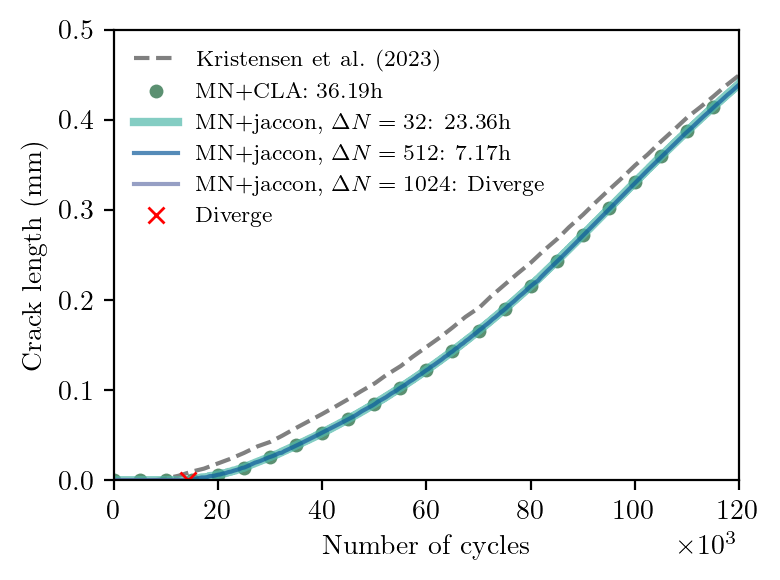

In [274]:
ref_df = pd.read_csv("ref/kristensen-singlenotch.csv")

plt.figure(figsize=(4,3), dpi=200)

ax = plt.subplot(111)
ax.ticklabel_format(axis='x', style='sci', scilimits=(3,3))

ax.plot(ref_df["x"], ref_df[" y"], ls="--", color="grey", label="Kristensen et al. (2023)")
marker_kwargs = dict(markersize=5, markevery=100, markeredgecolor='none')
# ax.plot(np.array(n_cycles_baseline), crack_lengths_baseline, ls="-", marker="^", **marker_kwargs, color=global_palette[0], label=r"Baseline: 69.44h", alpha=0.7, lw=1)
# ax.plot(np.array(n_cycles_split), crack_lengths_split, ls="-", marker="^", **marker_kwargs, color=global_palette[1], label=r"Baseline2", alpha=1, lw=1)
ax.plot(np.array(n_cycles_mncla_new), crack_lengths_mncla_new, ls="-", marker="o", **marker_kwargs, color=global_palette[0], label=r"MN+CLA: 36.19h", alpha=0.7, lw=0)
# ax.plot(np.array(n_cycles_mncla_jump32), crack_lengths_mncla_jump32, ls="-", color=global_palette[1], label=r"MN+CLA, $\Delta N=32$: 1.51h", alpha=0.7)
# ax.plot(np.array(n_cycles_mncla_jump512), crack_lengths_mncla_jump512, ls="-", color=global_palette[2], label=r"MN+CLA, $\Delta N=512$: 1.51h", alpha=0.7)
# ax.plot(np.array(n_cycles_mncla_jump1024), crack_lengths_mncla_jump1024, ls="-", color=global_palette[3], label=r"MN+CLA, $\Delta N=1024$: 1.51h", alpha=0.7)
# ax.plot(np.array(n_cycles_mnjaccon_jump16), crack_lengths_mnjaccon_jump16, ls="-", **marker_kwargs, color=global_palette[1], label=r"MN+jaccon, $\Delta N=16$: 1.51h, 4.19mm", alpha=0.7)
ax.plot(np.array(n_cycles_mnjaccon_jump32), crack_lengths_mnjaccon_jump32, ls="-", **marker_kwargs, color=global_palette[1], label=r"MN+jaccon, $\Delta N=32$: 23.36h", alpha=0.7, lw=3)
ax.plot(np.array(n_cycles_mnjaccon_jump512), crack_lengths_mnjaccon_jump512, ls="-", **marker_kwargs, color=global_palette[2], label=r"MN+jaccon, $\Delta N=512$: 7.17h", alpha=0.7)
ax.plot(np.array(n_cycles_mnjaccon_jump1024), crack_lengths_mnjaccon_jump1024, ls="-", **marker_kwargs, color=global_palette[3], label=r"MN+jaccon, $\Delta N=1024$: Diverge", alpha=0.7)
ax.plot(n_cycles_mnjaccon_jump1024[-1:], np.array(crack_lengths_mnjaccon_jump1024)[-1:], color="red", ls="-", marker="x", label=f"Diverge", alpha=1, lw=0)


# ax.plot(np.array(n_cycles_half), crack_lengths_half, ls="-")
ax.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.8)
ax.set_xlim([0, 120000])
ax.set_ylim([0, 0.5])
ax.set_xlabel("Number of cycles")
ax.set_ylabel("Crack length (mm)")

plt.savefig(os.path.join(plot_root, "kristensen-singlenotchtension-jaccon.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()

## Compare

In [5]:
W=50

In [9]:
n_cycles_jonas100_baseline, crack_lengths_jonas100_baseline = get_phi_x_max("output/JonasCTParis100-2024-09-16-12-04-41-baseline", crack_tip=(0.25+0.22)*W, cycle_per_file=10)
n_cycles_jonas100_yang, crack_lengths_jonas100_yang = get_phi_x_max("output/JonasCTParis100-2024-09-15-16-18-34-yang", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True)
n_cycles_jonas100_jonascla, crack_lengths_jonas100_jonascla = get_phi_x_max("output/JonasCTParis100-2024-09-15-16-17-20-jonascla", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True)
n_cycles_jonas100_jonas, crack_lengths_jonas100_jonas = get_phi_x_max("output/JonasCTParis100-2024-09-15-16-16-52-jonas", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True)
n_cycles_jonas100_jaccon, crack_lengths_jonas100_jaccon = get_phi_x_max("output/JonasCTParis100-2024-09-17-12-52-14-jaccon", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True)
n_cycles_jonas100_cla, crack_lengths_jonas100_cla = get_phi_x_max("output/JonasCTParis100-2024-09-15-16-18-18-cla", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True)
n_cycles_jonas100_cojocaru, crack_lengths_jonas100_cojocaru = get_phi_x_max("output/JonasCTParis100-2024-09-23-01-42-46-cojocaru", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True)
n_cycles_jonas100_cojocarucla, crack_lengths_jonas100_cojocarucla = get_phi_x_max("output/JonasCTParis100-2024-09-22-13-40-25-cojocarucla", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True)

  0%|          | 0/245 [00:00<?, ?it/s]

  0%|          | 0/577 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/130 [00:00<?, ?it/s]

  0%|          | 0/310 [00:00<?, ?it/s]

  0%|          | 0/613 [00:00<?, ?it/s]

  0%|          | 0/186 [00:00<?, ?it/s]

  0%|          | 0/178 [00:00<?, ?it/s]

In [10]:
enumerate_crack_lengths(n_cycles_jonas100_baseline, crack_lengths_jonas100_baseline)

In [11]:
enumerate_crack_lengths(n_cycles_jonas100_yang, crack_lengths_jonas100_yang)

Spike
574 True 577 [2413, 2414, 2415, 2416, 2417, 2418, 2419, 2420, 2421, 2422] [12.255963306067368, 12.371831383677108, 12.506820713712258, 12.69421169619965, 12.929990700766783, 13.228606797235951, 13.648115445000249, 14.21452082968127, 15.032924150645412, 16.309335967845954]
Spike
575 True 577 [2414, 2415, 2416, 2417, 2418, 2419, 2420, 2421, 2422, 2423] [12.371831383677108, 12.506820713712258, 12.69421169619965, 12.929990700766783, 13.228606797235951, 13.648115445000249, 14.21452082968127, 15.032924150645412, 16.309335967845954, 18.543850408695786]
Spike
576 True 577 [2415, 2416, 2417, 2418, 2419, 2420, 2421, 2422, 2423, 2424] [12.506820713712258, 12.69421169619965, 12.929990700766783, 13.228606797235951, 13.648115445000249, 14.21452082968127, 15.032924150645412, 16.309335967845954, 18.543850408695786, 24.266604812837443]


In [12]:
enumerate_crack_lengths(n_cycles_jonas100_jonascla, crack_lengths_jonas100_jonascla)

In [13]:
enumerate_crack_lengths(n_cycles_jonas100_jonas, crack_lengths_jonas100_jonas)

In [14]:
enumerate_crack_lengths(n_cycles_jonas100_jaccon, crack_lengths_jonas100_jaccon)

In [15]:
enumerate_crack_lengths(n_cycles_jonas100_cla, crack_lengths_jonas100_cla)

In [16]:
enumerate_crack_lengths(n_cycles_jonas100_cojocaru, crack_lengths_jonas100_cojocaru)

In [17]:
enumerate_crack_lengths(n_cycles_jonas100_cojocarucla, crack_lengths_jonas100_cojocarucla)

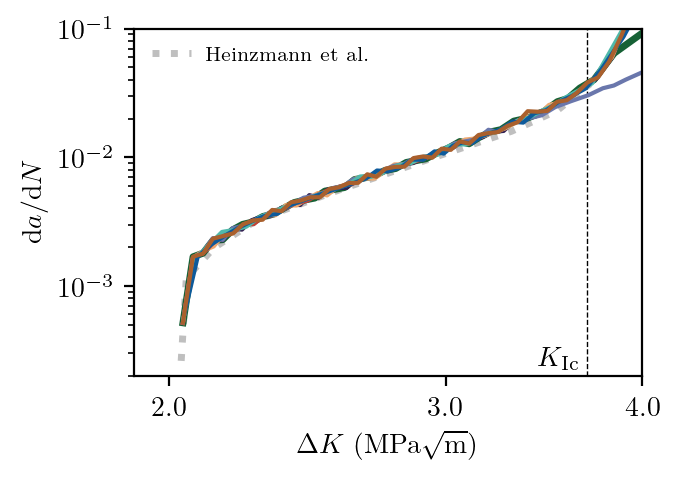

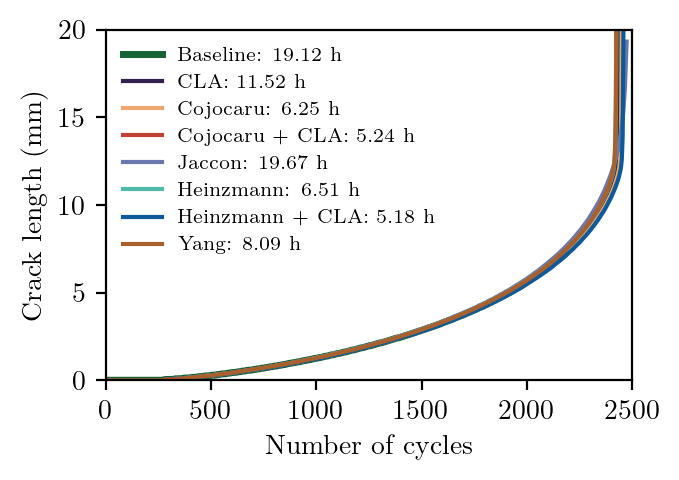

In [113]:
ref_df = pd.read_csv("ref/jonas-ct-100N.csv")

plt.figure(figsize=(3.5,2.5), dpi=200)

ax1 = plt.subplot(111)

ax1.plot(ref_df["x"], ref_df[" y"], color="grey", ls=":", alpha=0.5, label=r"Heinzmann et al.", lw=2.5)
ax1.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.7)

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlim([1.9, 4.0])

ax1.set_ylim([2e-4, 1e-1])
ylim = ax1.get_ylim()
ax1.plot([3.69, 3.69], ax1.get_ylim(), ls="--", lw=0.5, color="black")
ax1.set_ylim(ylim)
ax1.text(3.65, ylim[0]*1.1, r"$K_{\mathrm{Ic}}$", ha="right", va="bottom", transform=ax1.transData)
ax1.set_xticks([ 2.0, 3.0, 4.0])
ax1.set_xticklabels([2.0, 3.0, 4.0])
ax1.set_ylabel(r"$\mathrm{d}a/\mathrm{d}N$")
ax1.set_xlabel(r"$\Delta K$ (MPa$\sqrt{\mathrm{m}}$)")


plt.figure(figsize=(3.5,2.5), dpi=200)

ax2 = plt.subplot(111)
ax2.set_ylim([0, 20])
ax2.set_xlim([0, 2500])

ax2.set_ylabel("Crack length (mm)")
ax2.set_xlabel("Number of cycles")


def plot_one(n_cycles, crack_lengths, label, color, delta_p=100, lw=2.5, **kwargs):
    recorded_cycle, lengths, da_dn, delta_k = incremental_growth(n_cycles, crack_lengths, delta_p=delta_p, T=1, W=50)
    ax1.plot(delta_k, da_dn, color=color, ls="-", label=label, lw=lw, **kwargs)
    ax2.plot(n_cycles, crack_lengths, color=color, ls="-", label=label, lw=lw, **kwargs)

plot_one(n_cycles_jonas100_baseline, crack_lengths_jonas100_baseline, label=r"Baseline: 19.12 h", color=global_palette[0], delta_p=100, lw=2.5)
plot_one(n_cycles_jonas100_cla, crack_lengths_jonas100_cla, label=r"CLA: 11.52 h", color=global_palette[4], delta_p=100, lw=1.5)
plot_one(n_cycles_jonas100_cojocaru, crack_lengths_jonas100_cojocaru, label=f"Cojocaru: 6.25 h", color=global_palette[7], delta_p=100, lw=1.5)
plot_one(n_cycles_jonas100_cojocarucla, crack_lengths_jonas100_cojocarucla, label=f"Cojocaru + CLA: 5.24 h", color=global_palette[5], delta_p=100, lw=1.5)
plot_one(n_cycles_jonas100_jaccon, crack_lengths_jonas100_jaccon, label=f"Jaccon: 19.67 h", color=global_palette[3], delta_p=100, lw=1.5)
plot_one(n_cycles_jonas100_jonas, crack_lengths_jonas100_jonas, label=r"Heinzmann: 6.51 h", color=global_palette[1], delta_p=100, lw=1.5)
plot_one(n_cycles_jonas100_jonascla, crack_lengths_jonas100_jonascla, label=f"Heinzmann + CLA: 5.18 h", color=global_palette[2], delta_p=100, lw=1.5)
plot_one(n_cycles_jonas100_yang, crack_lengths_jonas100_yang, label=f"Yang: 8.09 h", color=global_palette[6], delta_p=100, lw=1.5)

ax2.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.7)

ax1.figure.savefig(os.path.join(plot_root, "jonas100-growthrate-compare.pdf"), dpi=500, bbox_inches="tight")
ax2.figure.savefig(os.path.join(plot_root, "jonas100-cracklength-compare.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()

Check cojocaru's approach

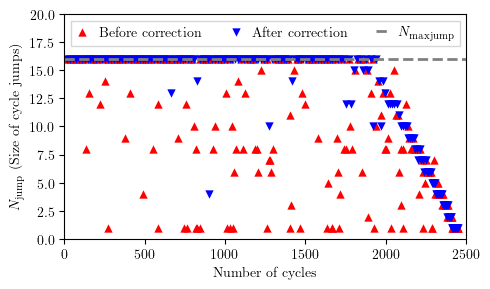

In [119]:
import re

plt.figure(figsize=(5,3), dpi=100)

logfile = "output/JonasCTParis100-2024-09-15-16-17-59-cojocarucla/log.txt"

with open(logfile, "r") as file:
    s = file.read()
    monitored = re.findall(r": jumping (.*?) cycles\nTime \(No.(.*?)\): (.*?) \(", s)

plt.scatter([float(x[2]) for x in monitored], [float(x[0]) for x in monitored], color="red", marker="^", linewidth=0, label="Before correction")

logfile = "output/JonasCTParis100-2024-09-22-13-40-25-cojocarucla/log.txt"

with open(logfile, "r") as file:
    s = file.read()
    monitored = re.findall(r": jumping (.*?) cycles\n.*?\nTime \(No.(.*?)\): (.*?) \(", s)
    # print(monitored)

plt.scatter([float(x[2]) for x in monitored], [float(x[0]) for x in monitored], color="blue", marker="v", linewidth=0, label="After correction")

plt.plot([0, 2700], [16, 16], color="grey", ls="--", lw=2, label=r"$N_{\mathrm{maxjump}}$")

plt.legend(loc="upper left", fancybox=False, ncols=3, handlelength=0.8)
plt.xlim([0, 2500])
plt.ylim([0, 20])
plt.xlabel("Number of cycles")
plt.ylabel(r"$N_{\mathrm{jump}}$ (Size of cycle jumps)")

plt.savefig("plots/cojocaru-cycle-jump-correction.jpg", dpi=500)
plt.show()
plt.close()

In [6]:
W=50
n_cycles_jonas50_baseline, crack_lengths_jonas50_baseline = get_phi_x_max("output/JonasCTParis50-2024-09-16-12-08-51-baseline", crack_tip=(0.25+0.22)*W, cycle_per_file=100)
n_cycles_jonas50_cla, crack_lengths_jonas50_cla = get_phi_x_max("output/JonasCTParis50-2024-09-16-12-29-38-cla", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True)
n_cycles_jonas50_jonas, crack_lengths_jonas50_jonas = get_phi_x_max("output/JonasCTParis50-2024-09-18-10-23-40-jonas", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True)
n_cycles_jonas50_jonascla, crack_lengths_jonas50_jonascla = get_phi_x_max("output/JonasCTParis50-2024-09-18-22-24-07-jonascla", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True)
n_cycles_jonas50_jaccon, crack_lengths_jonas50_jaccon = get_phi_x_max("output/JonasCTParis50-2024-09-17-12-52-42-jaccon", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True)
n_cycles_jonas50_cojocaru, crack_lengths_jonas50_cojocaru = get_phi_x_max("output/JonasCTParis50-2024-09-22-13-42-46-cojocaru", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True)
n_cycles_jonas50_cojocarucla, crack_lengths_jonas50_cojocarucla = get_phi_x_max("output/JonasCTParis50-2024-09-22-13-41-46-cojocarucla", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True)
n_cycles_jonas50_yang, crack_lengths_jonas50_yang = get_phi_x_max("output/JonasCTParis50-2024-09-17-12-49-22-yang", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True, read_every=10)


  0%|          | 0/136 [00:00<?, ?it/s]

  0%|          | 0/268 [00:00<?, ?it/s]

  0%|          | 0/217 [00:00<?, ?it/s]

  0%|          | 0/215 [00:00<?, ?it/s]

  0%|          | 0/325 [00:00<?, ?it/s]

  0%|          | 0/235 [00:00<?, ?it/s]

  0%|          | 0/190 [00:00<?, ?it/s]

  0%|          | 0/213 [00:00<?, ?it/s]

In [7]:
enumerate_crack_lengths(n_cycles_jonas50_baseline, crack_lengths_jonas50_baseline)
enumerate_crack_lengths(n_cycles_jonas50_cla, crack_lengths_jonas50_cla)
enumerate_crack_lengths(n_cycles_jonas50_jonas, crack_lengths_jonas50_jonas)
enumerate_crack_lengths(n_cycles_jonas50_jonascla, crack_lengths_jonas50_jonascla)
enumerate_crack_lengths(n_cycles_jonas50_jaccon, crack_lengths_jonas50_jaccon)
enumerate_crack_lengths(n_cycles_jonas50_cojocaru, crack_lengths_jonas50_cojocaru)
enumerate_crack_lengths(n_cycles_jonas50_cojocarucla, crack_lengths_jonas50_cojocarucla)
enumerate_crack_lengths(n_cycles_jonas50_yang, crack_lengths_jonas50_yang)

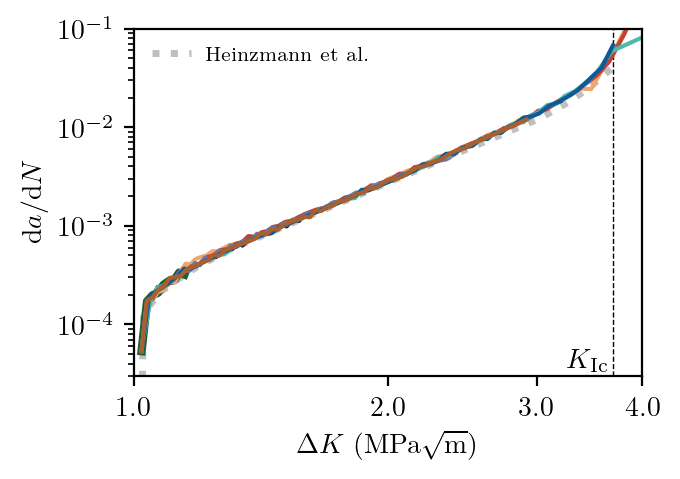

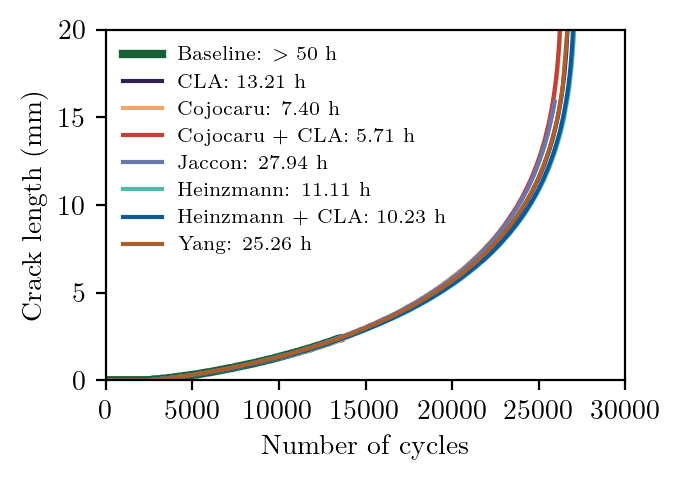

In [71]:
ref_df = pd.read_csv("ref/jonas-ct-50N.csv")

plt.figure(figsize=(3.5,2.5), dpi=200)

ax1 = plt.subplot(111)

ax1.plot(ref_df["x"], ref_df[" y"], color="grey", ls=":", alpha=0.5, label=r"Heinzmann et al.", lw=2.5)
ax1.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.7)

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlim([1.0, 4.0])

ax1.set_ylim([3e-5, 1e-1])
ylim = ax1.get_ylim()
ax1.plot([3.69, 3.69], ax1.get_ylim(), ls="--", lw=0.5, color="black")
ax1.set_ylim(ylim)
ax1.text(3.65, ylim[0]*1.1, r"$K_{\mathrm{Ic}}$", ha="right", va="bottom", transform=ax1.transData)
ax1.set_xticks([ 1.0, 2.0, 3.0, 4.0])
ax1.set_xticklabels([1.0, 2.0, 3.0, 4.0])
ax1.set_ylabel(r"$\mathrm{d}a/\mathrm{d}N$")
ax1.set_xlabel(r"$\Delta K$ (MPa$\sqrt{\mathrm{m}}$)")


plt.figure(figsize=(3.5,2.5), dpi=200)

ax2 = plt.subplot(111)
ax2.set_ylim([0, 20])
ax2.set_xlim([0, 30000])

ax2.set_ylabel("Crack length (mm)")
ax2.set_xlabel("Number of cycles")


def plot_one(n_cycles, crack_lengths, label, color, delta_p=100, lw=2.5, **kwargs):
    recorded_cycle, lengths, da_dn, delta_k = incremental_growth(n_cycles, crack_lengths, delta_p=delta_p, T=1, W=50)
    ax1.plot(delta_k, da_dn, color=color, ls="-", label=label, lw=lw, **kwargs)
    ax2.plot(n_cycles, crack_lengths, color=color, ls="-", label=label, lw=lw, **kwargs)

plot_one(n_cycles_jonas50_baseline, crack_lengths_jonas50_baseline, label=r"Baseline: $>50$ h", color=global_palette[0], delta_p=50, lw=3)
plot_one(n_cycles_jonas50_cla, crack_lengths_jonas50_cla, label=r"CLA: 13.21 h", color=global_palette[4], delta_p=50, lw=1.5)
plot_one(n_cycles_jonas50_cojocaru, crack_lengths_jonas50_cojocaru, label=f"Cojocaru: 7.40 h", color=global_palette[7], delta_p=50, lw=1.5)
plot_one(n_cycles_jonas50_cojocarucla, crack_lengths_jonas50_cojocarucla, label=f"Cojocaru + CLA: 5.71 h", color=global_palette[5], delta_p=50, lw=1.5)
plot_one(n_cycles_jonas50_jaccon, crack_lengths_jonas50_jaccon, label=f"Jaccon: 27.94 h", color=global_palette[3], delta_p=50, lw=1.5)
plot_one(n_cycles_jonas50_jonas, crack_lengths_jonas50_jonas, label=r"Heinzmann: 11.11 h", color=global_palette[1], delta_p=50, lw=1.5)
plot_one(n_cycles_jonas50_jonascla, crack_lengths_jonas50_jonascla, label=f"Heinzmann + CLA: 10.23 h", color=global_palette[2], delta_p=50, lw=1.5)
plot_one(n_cycles_jonas50_yang, crack_lengths_jonas50_yang, label=f"Yang: 25.26 h", color=global_palette[6], delta_p=50, lw=1.5)

ax2.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.7)
ax1.figure.savefig(os.path.join(plot_root, "jonas50-growthrate-compare.pdf"), dpi=500, bbox_inches="tight")
ax2.figure.savefig(os.path.join(plot_root, "jonas50-cracklength-compare.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()

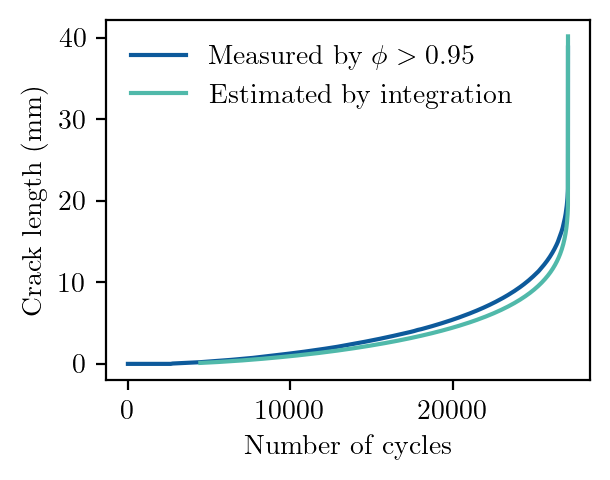

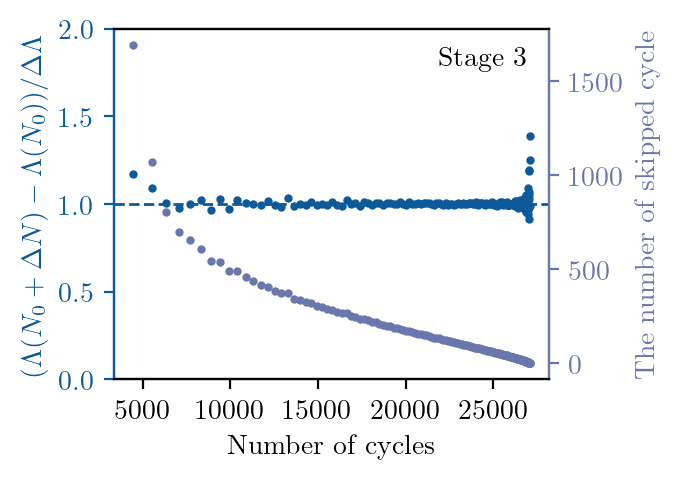

In [210]:
import re

logfile = "output/JonasCTParis50-2024-09-18-10-23-40-jonas/log.txt"

with open(logfile, "r") as file:
    s = file.read()
    monitored = re.findall(r"Trial Delta: (.*?) Expected Delta: (.*?)\nCycle jump is done successfully. The number of jumped cycle: (.*?).\nThe monitored value \(at stage (.*?)\): .*?\.\n.*?\nComputing output \(will be saved to No.(.*?)\)", s)

    estimated_lengths = re.findall(r"The monitored value \(at stage 3\): (.*?).\nThe number of resolved cycles \(including trial cycles\): .*?\nComputing output \(will be saved to No\.(.*?)\)", s)
    # print(estimated_lengths)
plt.figure(figsize=(3.15,2.5), dpi=200)
ax = plt.subplot(111)
ax.plot(n_cycles_jonas50_jonas, np.array(crack_lengths_jonas50_jonas), color=global_palette[2], ls="-", label=r"Measured by $\phi>0.95$", alpha=1, lw=1.5)
ax.plot([float(x[1]) for x in estimated_lengths], [float(x[0]) for x in estimated_lengths], color=global_palette[1], ls="-", label=f"Estimated by integration", alpha=1, lw=1.5)

ax.set_ylabel("Crack length (mm)")
ax.set_xlabel("Number of cycles")
# ax.spines["left"].set_color(global_palette[0])
# ax.spines["right"].set_color(global_palette[2])
# ax.tick_params(axis="y", colors=global_palette[2])
# ax.yaxis.label.set_color(global_palette[2])
ax.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"])
# plt.savefig(os.path.join(plot_root, "jonas-crack-length-estimation.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()

plt.figure(figsize=(3.5,2.5), dpi=200)
ax = plt.subplot(111)
ax.plot([float(x[4]) for x in monitored if x[3] == "3"], [float(x[0])/float(x[1]) for x in monitored if x[3] == "3"], color=global_palette[2], ls="-", alpha=1, lw=0, marker="o", markersize=2)
ax.spines["left"].set_color(global_palette[2])
ax.spines["right"].set_color(global_palette[3])
ax.tick_params(axis="y", colors=global_palette[2], which="both")
ax.yaxis.label.set_color(global_palette[2])

xlim = ax.get_xlim()
ax.plot(xlim, [1, 1], lw=1, ls="--", color=global_palette[2], alpha=1, zorder=0)
ax.set_xlim(xlim)

ax.set_ylabel(r"$(\Lambda(N_0+\Delta N)-\Lambda(N_0))/\Delta \Lambda$")
ax.set_xlabel("Number of cycles")
ax.set_ylim([0, 2])

ax.text(0.95, 0.95, r"Stage 3", ha="right", va="top", transform=ax.transAxes)

ax = ax.twinx()
ax.plot([float(x[4]) for x in monitored if x[3] == "3"], [float(x[2]) for x in monitored if x[3] == "3"], color=global_palette[3], ls="-", alpha=1, lw=0, marker="o", markersize=2)
ax.set_ylabel(r"The number of skipped cycle")
ax.spines["left"].set_color(global_palette[2])
ax.spines["right"].set_color(global_palette[3])
ax.tick_params(axis="y", colors=global_palette[3], which="both")
ax.yaxis.label.set_color(global_palette[3])
# ax.spines["left"].set_color(global_palette[0])
# ax.spines["right"].set_color(global_palette[2])
# ax.tick_params(axis="y", colors=global_palette[2])
# ax.yaxis.label.set_color(global_palette[2])
# ax.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"])
# plt.savefig(os.path.join(plot_root, "jonas-cycle-jump-length.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()

In [8]:

n_cycles_jonas20_cla, crack_lengths_jonas20_cla = get_phi_x_max("output/JonasCTParis20-2024-09-20-06-31-12-cla", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True)
n_cycles_jonas20_jonas, crack_lengths_jonas20_jonas = get_phi_x_max("output/JonasCTParis20-2024-09-20-18-34-52-jonas", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True)
n_cycles_jonas20_jonascla, crack_lengths_jonas20_jonascla = get_phi_x_max("output/JonasCTParis20-2024-09-20-18-35-32-jonascla", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True)
n_cycles_jonas20_jaccon, crack_lengths_jonas20_jaccon = get_phi_x_max("output/JonasCTParis20-2024-09-20-18-34-15-jaccon", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True)
n_cycles_jonas20_cojocaru, crack_lengths_jonas20_cojocaru = get_phi_x_max("output/JonasCTParis20-2024-09-22-13-42-46-cojocaru", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True)
n_cycles_jonas20_cojocarucla, crack_lengths_jonas20_cojocarucla = get_phi_x_max("output/JonasCTParis20-2024-09-22-13-41-46-cojocarucla", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True)
n_cycles_jonas20_yang, crack_lengths_jonas20_yang = get_phi_x_max("output/JonasCTParis20-2024-09-20-18-33-26-yang", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True, read_every=20)
# n_cycles_jonas20_jonas05, crack_lengths_jonas20_jonas05 = get_phi_x_max("output/JonasCTParis20-2024-09-21-14-20-19", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True)
n_cycles_jonas20_jonascla05, crack_lengths_jonas20_jonascla05 = get_phi_x_max("output/JonasCTParis20-2024-09-21-14-21-04-jonascla05", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True)
n_cycles_jonas20_jonascla01, crack_lengths_jonas20_jonascla01 = get_phi_x_max("output/JonasCTParis20-2024-09-22-01-11-14-jonascla01", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True)


  0%|          | 0/241 [00:00<?, ?it/s]

  0%|          | 0/272 [00:00<?, ?it/s]

  0%|          | 0/271 [00:00<?, ?it/s]

  0%|          | 0/585 [00:00<?, ?it/s]

  0%|          | 0/597 [00:00<?, ?it/s]

  0%|          | 0/595 [00:00<?, ?it/s]

  0%|          | 0/167 [00:00<?, ?it/s]

  0%|          | 0/482 [00:00<?, ?it/s]

  0%|          | 0/1977 [00:00<?, ?it/s]

In [9]:
enumerate_crack_lengths(n_cycles_jonas20_cla, crack_lengths_jonas20_cla)
enumerate_crack_lengths(n_cycles_jonas20_jonas, crack_lengths_jonas20_jonas)
enumerate_crack_lengths(n_cycles_jonas20_jonascla, crack_lengths_jonas20_jonascla)
enumerate_crack_lengths(n_cycles_jonas20_jaccon, crack_lengths_jonas20_jaccon)
enumerate_crack_lengths(n_cycles_jonas20_cojocaru, crack_lengths_jonas20_cojocaru)
enumerate_crack_lengths(n_cycles_jonas20_cojocarucla, crack_lengths_jonas20_cojocarucla)
enumerate_crack_lengths(n_cycles_jonas20_yang, crack_lengths_jonas20_yang)
enumerate_crack_lengths(n_cycles_jonas20_jonascla05, crack_lengths_jonas20_jonascla05)
enumerate_crack_lengths(n_cycles_jonas20_jonascla01, crack_lengths_jonas20_jonascla01)

Spike
592 True 597 [466765, 467567, 468369, 469171, 469973, 470775, 471577, 472379, 472771, 473040] [18.885673716431498, 19.301748497376582, 19.782051516898143, 20.33243798730305, 20.943247576260468, 21.691599066305265, 22.586086805667286, 23.81282027334489, 24.890088302919214, 25.977594424615045]
Spike
593 True 597 [467567, 468369, 469171, 469973, 470775, 471577, 472379, 472771, 473040, 473192] [19.301748497376582, 19.782051516898143, 20.33243798730305, 20.943247576260468, 21.691599066305265, 22.586086805667286, 23.81282027334489, 24.890088302919214, 25.977594424615045, 27.00843854478454]
Spike
594 True 597 [468369, 469171, 469973, 470775, 471577, 472379, 472771, 473040, 473192, 473269] [19.782051516898143, 20.33243798730305, 20.943247576260468, 21.691599066305265, 22.586086805667286, 23.81282027334489, 24.890088302919214, 25.977594424615045, 27.00843854478454, 27.903204451208346]
Spike
595 True 597 [469171, 469973, 470775, 471577, 472379, 472771, 473040, 473192, 473269, 473293] [20.3

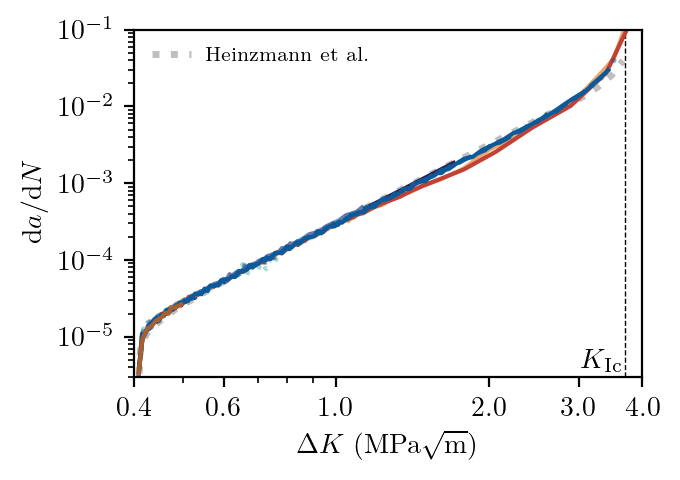

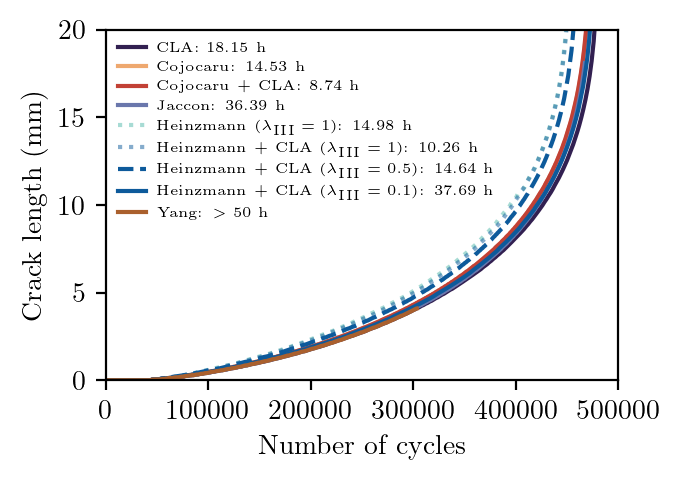

In [125]:
ref_df = pd.read_csv("ref/jonas-ct-20N.csv")

plt.figure(figsize=(3.5,2.5), dpi=200)

ax1 = plt.subplot(111)

ax1.plot(ref_df["x"], ref_df[" y"], color="grey", ls=":", alpha=0.5, label=r"Heinzmann et al.", lw=2.5)
ax1.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.7)

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlim([0.4, 4.0])

ax1.set_ylim([3e-6, 1e-1])
ylim = ax1.get_ylim()
ax1.plot([3.69, 3.69], ax1.get_ylim(), ls="--", lw=0.5, color="black")
ax1.set_ylim(ylim)
ax1.text(3.65, ylim[0]*1.1, r"$K_{\mathrm{Ic}}$", ha="right", va="bottom", transform=ax1.transData)
ax1.set_xticks([0.4, 0.6, 1.0, 2.0, 3.0, 4.0])
ax1.set_xticklabels([0.4, 0.6, 1.0, 2.0, 3.0, 4.0])
ax1.set_ylabel(r"$\mathrm{d}a/\mathrm{d}N$")
ax1.set_xlabel(r"$\Delta K$ (MPa$\sqrt{\mathrm{m}}$)")


plt.figure(figsize=(3.5,2.5), dpi=200)

ax2 = plt.subplot(111)
ax2.set_ylim([0, 20])
ax2.set_xlim([0, 500000])

ax2.set_ylabel("Crack length (mm)")
ax2.set_xlabel("Number of cycles")


def plot_one(n_cycles, crack_lengths, label, color, delta_p=100, lw=2.5, **kwargs):
    recorded_cycle, lengths, da_dn, delta_k = incremental_growth(n_cycles, crack_lengths, delta_p=delta_p, T=1, W=50)
    ax1.plot(delta_k, da_dn, color=color, label=label, lw=lw, **kwargs)
    ax2.plot(n_cycles, crack_lengths, color=color, label=label, lw=lw, **kwargs)
 
plot_one(n_cycles_jonas20_cla, crack_lengths_jonas20_cla, label=r"CLA: 18.15 h", color=global_palette[4], delta_p=20, lw=1.5)
plot_one(n_cycles_jonas20_cojocaru, crack_lengths_jonas20_cojocaru, label=f"Cojocaru: 14.53 h", color=global_palette[7], delta_p=20, lw=1.5)
plot_one(n_cycles_jonas20_cojocarucla, crack_lengths_jonas20_cojocarucla, label=f"Cojocaru + CLA: 8.74 h", color=global_palette[5], delta_p=20, lw=1.5)
plot_one(n_cycles_jonas20_jaccon, crack_lengths_jonas20_jaccon, label=f"Jaccon: 36.39 h", color=global_palette[3], delta_p=20, lw=1.5)
plot_one(n_cycles_jonas20_jonas, crack_lengths_jonas20_jonas, label=r"Heinzmann ($\lambda_{\mathrm{III}}=1$): 14.98 h", color=global_palette[1], delta_p=20, lw=1.5, ls=":", alpha=0.5)
plot_one(n_cycles_jonas20_jonascla, crack_lengths_jonas20_jonascla, label=r"Heinzmann + CLA ($\lambda_{\mathrm{III}}=1$): 10.26 h", color=global_palette[2], delta_p=20, lw=1.5, ls=":", alpha=0.5)
# plot_one(n_cycles_jonas20_jonas05, crack_lengths_jonas20_jonas05, label=r"Heinzmann $\lambda_{\mathrm{III}}=0.5$", color=global_palette[1], delta_p=20, lw=1.5)
plot_one(n_cycles_jonas20_jonascla05, crack_lengths_jonas20_jonascla05, label=r"Heinzmann + CLA ($\lambda_{\mathrm{III}}=0.5$): 14.64 h", color=global_palette[2], delta_p=20, lw=1.5, ls="--")
plot_one(n_cycles_jonas20_jonascla01, crack_lengths_jonas20_jonascla01, label=r"Heinzmann + CLA ($\lambda_{\mathrm{III}}=0.1$): 37.69 h", color=global_palette[2], delta_p=20, lw=1.5, ls="-")
plot_one(n_cycles_jonas20_yang, crack_lengths_jonas20_yang, label=f"Yang: $>50$ h", color=global_palette[6], delta_p=20, lw=1.5)

ax2.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.5)
ax1.figure.savefig(os.path.join(plot_root, "jonas20-growthrate-compare.pdf"), dpi=500, bbox_inches="tight")
ax2.figure.savefig(os.path.join(plot_root, "jonas20-cracklength-compare.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()

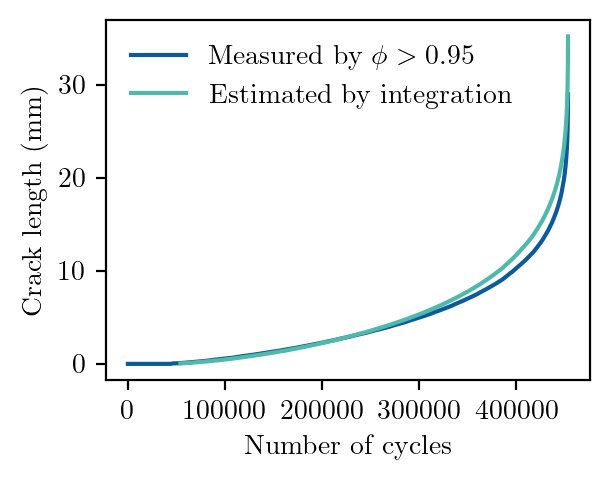

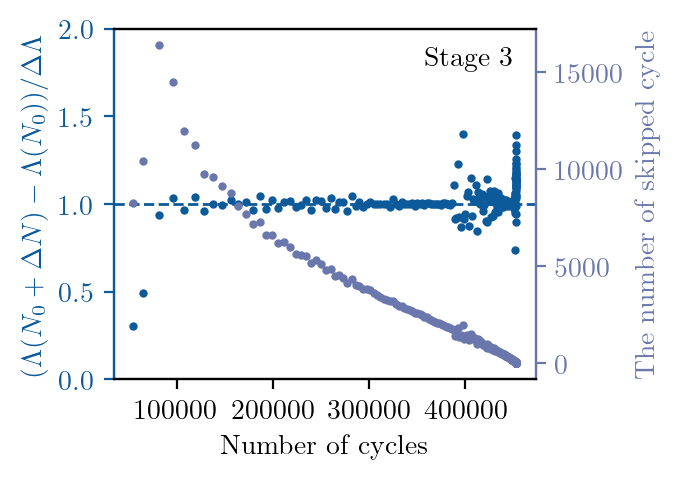

In [108]:
import re

logfile = "output/JonasCTParis20-2024-09-20-18-35-32-jonascla/log.txt"

with open(logfile, "r") as file:
    s = file.read()
    monitored = re.findall(r"Trial Delta: (.*?) Expected Delta: (.*?)\nCycle jump is done successfully. The number of jumped cycle: (.*?).\nThe monitored value \(at stage (.*?)\): .*?\.\n.*?\nComputing output \(will be saved to No.(.*?)\)", s)

    estimated_lengths = re.findall(r"The monitored value \(at stage 3\): (.*?).\nThe number of resolved cycles \(including trial cycles\): .*?\nComputing output \(will be saved to No\.(.*?)\)", s)
    # print(estimated_lengths)
plt.figure(figsize=(3.15,2.5), dpi=200)
ax = plt.subplot(111)
ax.plot(n_cycles_jonas20_jonascla, np.array(crack_lengths_jonas20_jonascla), color=global_palette[2], ls="-", label=r"Measured by $\phi>0.95$", alpha=1, lw=1.5)
ax.plot([float(x[1]) for x in estimated_lengths], [float(x[0])*1.5 for x in estimated_lengths], color=global_palette[1], ls="-", label=f"Estimated by integration", alpha=1, lw=1.5)

ax.set_ylabel("Crack length (mm)")
ax.set_xlabel("Number of cycles")
# ax.spines["left"].set_color(global_palette[0])
# ax.spines["right"].set_color(global_palette[2])
# ax.tick_params(axis="y", colors=global_palette[2])
# ax.yaxis.label.set_color(global_palette[2])
# ylim=ax.get_ylim()
# ax.plot([280000]*2, ylim)
ax.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"])
# plt.savefig(os.path.join(plot_root, "jonas-crack-length-estimation.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()

plt.figure(figsize=(3.5,2.5), dpi=200)
ax = plt.subplot(111)
ax.plot([float(x[4]) for x in monitored if x[3] == "3"], [float(x[0])/float(x[1]) for x in monitored if x[3] == "3"], color=global_palette[2], ls="-", alpha=1, lw=0, marker="o", markersize=2)
ax.spines["left"].set_color(global_palette[2])
ax.spines["right"].set_color(global_palette[3])
ax.tick_params(axis="y", colors=global_palette[2], which="both")
ax.yaxis.label.set_color(global_palette[2])

xlim = ax.get_xlim()
ax.plot(xlim, [1, 1], lw=1, ls="--", color=global_palette[2], alpha=1, zorder=0)
ax.set_xlim(xlim)

ax.set_ylabel(r"$(\Lambda(N_0+\Delta N)-\Lambda(N_0))/\Delta \Lambda$")
ax.set_xlabel("Number of cycles")
ax.set_ylim([0, 2])

ax.text(0.95, 0.95, r"Stage 3", ha="right", va="top", transform=ax.transAxes)

ax = ax.twinx()
ax.plot([float(x[4]) for x in monitored if x[3] == "3"], [float(x[2]) for x in monitored if x[3] == "3"], color=global_palette[3], ls="-", alpha=1, lw=0, marker="o", markersize=2)
ax.set_ylabel(r"The number of skipped cycle")
ax.spines["left"].set_color(global_palette[2])
ax.spines["right"].set_color(global_palette[3])
ax.tick_params(axis="y", colors=global_palette[3], which="both")
ax.yaxis.label.set_color(global_palette[3])
# ax.spines["left"].set_color(global_palette[0])
# ax.spines["right"].set_color(global_palette[2])
# ax.tick_params(axis="y", colors=global_palette[2])
# ax.yaxis.label.set_color(global_palette[2])
# ax.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"])
# plt.savefig(os.path.join(plot_root, "jonas-cycle-jump-length.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()

## A preliminary sensitivity analysis

In [4]:
W=50
n_cycles_jonas100_baseline, crack_lengths_jonas100_baseline = get_phi_x_max("output/JonasCTParis100-2024-09-16-12-04-41-baseline", crack_tip=(0.25+0.22)*W, cycle_per_file=10)
n_cycles_jonas100_yang, crack_lengths_jonas100_yang = get_phi_x_max("output/JonasCTParis100-2024-09-15-16-18-34-yang", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True)
n_cycles_jonas100_jaccon, crack_lengths_jonas100_jaccon = get_phi_x_max("output/JonasCTParis100-2024-09-17-12-52-14-jaccon", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True)
n_cycles_jonas100_cla, crack_lengths_jonas100_cla = get_phi_x_max("output/JonasCTParis100-2024-09-15-16-18-18-cla", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 11.52h
n_cycles_jonas100_cojocaru, crack_lengths_jonas100_cojocaru = get_phi_x_max("output/JonasCTParis100-2024-09-23-01-42-46-cojocaru", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True)

  0%|          | 0/245 [00:00<?, ?it/s]

  0%|          | 0/577 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/130 [00:00<?, ?it/s]

  0%|          | 0/310 [00:00<?, ?it/s]

  0%|          | 0/613 [00:00<?, ?it/s]

  0%|          | 0/186 [00:00<?, ?it/s]

  0%|          | 0/178 [00:00<?, ?it/s]

In [106]:
def estimate_fatigue_life(cycles: list, crack_lengths: list, threshold: float):
    cycles = np.array(cycles)
    crack_lengths = np.array(crack_lengths)
    if np.all(crack_lengths<threshold):
        return np.nan
    dists = crack_lengths - threshold
    larger = np.where(dists>0)[0][np.argmin(dists[np.where(dists>0)[0]])]
    smaller = np.where(dists<0)[0][np.argmax(dists[np.where(dists<0)[0]])]
    idxs = np.array([smaller, larger])
    selected_lengths = np.sort(crack_lengths[idxs])
    selected_cycles = np.sort(cycles[idxs])
    return (threshold - selected_lengths[0])/(selected_lengths[1]-selected_lengths[0]) * (selected_cycles[1]-selected_cycles[0]) + selected_cycles[0]

In [10]:
W=50
n_cycles_jonas100_cla200, crack_lengths_jonas100_cla200 = get_phi_x_max("output/JonasCTParis100-2024-10-14-16-55-18-cla200", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 0.53h
n_cycles_jonas100_cla100, crack_lengths_jonas100_cla100 = get_phi_x_max("output/JonasCTParis100-2024-10-14-16-55-53-cla100", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 0.97h
n_cycles_jonas100_cla50, crack_lengths_jonas100_cla50 = get_phi_x_max("output/JonasCTParis100-2024-10-14-16-56-36-cla50", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 1.62h
n_cycles_jonas100_cla40, crack_lengths_jonas100_cla40 = get_phi_x_max("output/JonasCTParis100-2024-10-14-20-28-47-cla40", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 2.09h
n_cycles_jonas100_cla30, crack_lengths_jonas100_cla30 = get_phi_x_max("output/JonasCTParis100-2024-10-14-20-29-14-cla30", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 2.49h
n_cycles_jonas100_cla20, crack_lengths_jonas100_cla20 = get_phi_x_max("output/JonasCTParis100-2024-10-14-20-30-25-cla20", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 3.25h
n_cycles_jonas100_cla10, crack_lengths_jonas100_cla10 = get_phi_x_max("output/JonasCTParis100-2024-10-14-16-56-59-cla10", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 4.90h

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/24 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/63 [00:00<?, ?it/s]

  0%|          | 0/84 [00:00<?, ?it/s]

  0%|          | 0/126 [00:00<?, ?it/s]

  0%|          | 0/251 [00:00<?, ?it/s]

Reaching the end of the mesh.


In [11]:
enumerate_crack_lengths(n_cycles_jonas100_cla200, crack_lengths_jonas100_cla200)
enumerate_crack_lengths(n_cycles_jonas100_cla100, crack_lengths_jonas100_cla100)
enumerate_crack_lengths(n_cycles_jonas100_cla50, crack_lengths_jonas100_cla50)
enumerate_crack_lengths(n_cycles_jonas100_cla40, crack_lengths_jonas100_cla40)
enumerate_crack_lengths(n_cycles_jonas100_cla30, crack_lengths_jonas100_cla30)
enumerate_crack_lengths(n_cycles_jonas100_cla20, crack_lengths_jonas100_cla20)
enumerate_crack_lengths(n_cycles_jonas100_cla10, crack_lengths_jonas100_cla10)

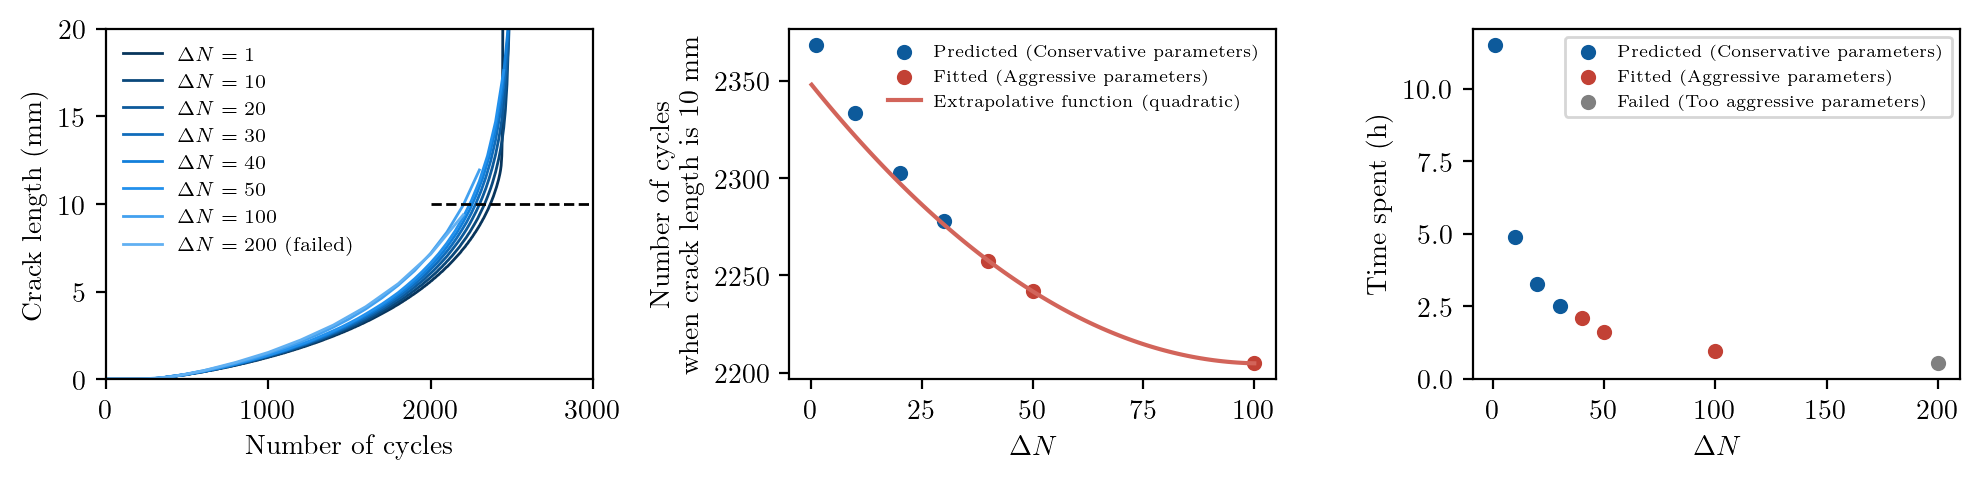

In [331]:
plt.figure(figsize=(10,2.5), dpi=200)

ax2 = plt.subplot(131)
ax2.set_ylim([0, 20])
ax2.set_xlim([0, 3000])

ax2.set_ylabel("Crack length (mm)")
ax2.set_xlabel("Number of cycles")


def plot_one(n_cycles, crack_lengths, label, color, delta_p=100, lw=2.5, **kwargs):
    ax2.plot(n_cycles, crack_lengths, color=color, ls="-", label=label, lw=lw, **kwargs)

plot_one(n_cycles_jonas100_cla, crack_lengths_jonas100_cla, label=r"$\Delta N = 1$", color=lighten_color(global_palette[2], 1.2), delta_p=100, lw=1.)
plot_one(n_cycles_jonas100_cla10, crack_lengths_jonas100_cla10, label=r"$\Delta N = 10$", color=lighten_color(global_palette[2], 1.1), delta_p=100, lw=1.)
plot_one(n_cycles_jonas100_cla20, crack_lengths_jonas100_cla20, label=r"$\Delta N = 20$", color=lighten_color(global_palette[2], 1.0), delta_p=100, lw=1.)
plot_one(n_cycles_jonas100_cla30, crack_lengths_jonas100_cla30, label=r"$\Delta N = 30$", color=lighten_color(global_palette[2], 0.9), delta_p=100, lw=1.)
plot_one(n_cycles_jonas100_cla40, crack_lengths_jonas100_cla40, label=r"$\Delta N = 40$", color=lighten_color(global_palette[2], 0.8), delta_p=100, lw=1.)
plot_one(n_cycles_jonas100_cla50, crack_lengths_jonas100_cla50, label=r"$\Delta N = 50$", color=lighten_color(global_palette[2], 0.7), delta_p=100, lw=1.)
plot_one(n_cycles_jonas100_cla100, crack_lengths_jonas100_cla100, label=r"$\Delta N = 100$", color=lighten_color(global_palette[2], 0.6), delta_p=100, lw=1.)
plot_one(n_cycles_jonas100_cla200, crack_lengths_jonas100_cla200, label=r"$\Delta N = 200$ (failed)", color=lighten_color(global_palette[2], 0.5), delta_p=100, lw=1.)

ax2.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.7)

ax2.plot([2000, 3000], [10, 10], ls="--", lw=1, c="k")

ax = plt.subplot(132)

ax.scatter([1,10,20,30], [estimate_fatigue_life(*x, 10) for x in [[n_cycles_jonas100_cla, crack_lengths_jonas100_cla],[n_cycles_jonas100_cla10, crack_lengths_jonas100_cla10],[n_cycles_jonas100_cla20, crack_lengths_jonas100_cla20],[n_cycles_jonas100_cla30, crack_lengths_jonas100_cla30]]], s=20, c=global_palette[2], label="Predicted (Conservative parameters)")
ax.scatter([40,50,100], [estimate_fatigue_life(*x, 10) for x in [[n_cycles_jonas100_cla40, crack_lengths_jonas100_cla40],[n_cycles_jonas100_cla50, crack_lengths_jonas100_cla50],[n_cycles_jonas100_cla100, crack_lengths_jonas100_cla100]]], s=20, c=global_palette[5], label="Fitted (Aggressive parameters)")
# ax.scatter([200], [estimate_fatigue_life(*x, 10) for x in [[n_cycles_jonas100_cla200, crack_lengths_jonas100_cla200]]], s=20, c="grey", label="Failed (Too aggressive parameters)")

def func(x, a, b, c):
    return a*x**2+b*x+c

from scipy.optimize import curve_fit

coeffs, _ = curve_fit(func, [40,50,100], [estimate_fatigue_life(*x, 10) for x in [[n_cycles_jonas100_cla40, crack_lengths_jonas100_cla40],[n_cycles_jonas100_cla50, crack_lengths_jonas100_cla50],[n_cycles_jonas100_cla100, crack_lengths_jonas100_cla100]]], p0=[100, 0.01, 2100])
x = np.linspace(0.1, 100, 100)
ax.plot(x, func(x, *coeffs), lw=1.5, c=lighten_color(global_palette[5], 0.8), label="Extrapolative function (quadratic)")

ax.legend(loc="upper right", frameon=False, fontsize=plt.rcParams["font.size"]*0.6)

ax.set_ylabel("Number of cycles\nwhen crack length is 10 mm")
ax.set_xlabel(r"$\Delta N$")

ax = plt.subplot(133)

ax.scatter([1,10,20,30], [11.52, 4.9, 3.25, 2.49], s=20, c=global_palette[2], label="Predicted (Conservative parameters)")
ax.scatter([40,50,100], [2.09, 1.62,0.97], s=20, c=global_palette[5], label="Fitted (Aggressive parameters)")
ax.scatter([200], [0.53], s=20, c="grey", label="Failed (Too aggressive parameters)")

ax.legend(loc="upper right", fontsize=plt.rcParams["font.size"]*0.6)


ax.set_ylabel("Time spent (h)")
ax.set_xlabel(r"$\Delta N$")

plt.tight_layout()
plt.savefig(os.path.join(plot_root, "pre-sensitivity-cla.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()

In [12]:
n_cycles_jonas100_jonas20, crack_lengths_jonas100_jonas20 = get_phi_x_max("output/JonasCTParis100-2024-10-14-17-02-02-jonas20", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 1.36h
n_cycles_jonas100_jonas10, crack_lengths_jonas100_jonas10 = get_phi_x_max("output/JonasCTParis100-2024-10-14-17-02-37-jonas10", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 2.66h
n_cycles_jonas100_jonas8, crack_lengths_jonas100_jonas8 = get_phi_x_max("output/JonasCTParis100-2024-10-15-14-52-17-jonas8", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 2.91h
n_cycles_jonas100_jonas7, crack_lengths_jonas100_jonas7 = get_phi_x_max("output/JonasCTParis100-2024-10-15-14-51-53-jonas7", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 3.03h
n_cycles_jonas100_jonas6, crack_lengths_jonas100_jonas6 = get_phi_x_max("output/JonasCTParis100-2024-10-15-14-51-25-jonas6", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 2.88h
n_cycles_jonas100_jonas5, crack_lengths_jonas100_jonas5 = get_phi_x_max("output/JonasCTParis100-2024-10-14-17-02-53-jonas5", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 3.14h
n_cycles_jonas100_jonas4, crack_lengths_jonas100_jonas4 = get_phi_x_max("output/JonasCTParis100-2024-10-15-10-42-47-jonas4", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 4.00h
n_cycles_jonas100_jonas3, crack_lengths_jonas100_jonas3 = get_phi_x_max("output/JonasCTParis100-2024-10-15-10-43-03-jonas3", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 4.63h
n_cycles_jonas100_jonas2, crack_lengths_jonas100_jonas2 = get_phi_x_max("output/JonasCTParis100-2024-10-15-10-43-22-jonas2", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 5.23h
n_cycles_jonas100_jonas, crack_lengths_jonas100_jonas = get_phi_x_max("output/JonasCTParis100-2024-09-15-16-16-52-jonas", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 6.51h

  0%|          | 0/33 [00:00<?, ?it/s]

  0%|          | 0/41 [00:00<?, ?it/s]

  0%|          | 0/43 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/47 [00:00<?, ?it/s]

  0%|          | 0/51 [00:00<?, ?it/s]

  0%|          | 0/56 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

  0%|          | 0/130 [00:00<?, ?it/s]

In [19]:
enumerate_crack_lengths(n_cycles_jonas100_jonas20, crack_lengths_jonas100_jonas20)

/home/xlluo/anaconda3/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


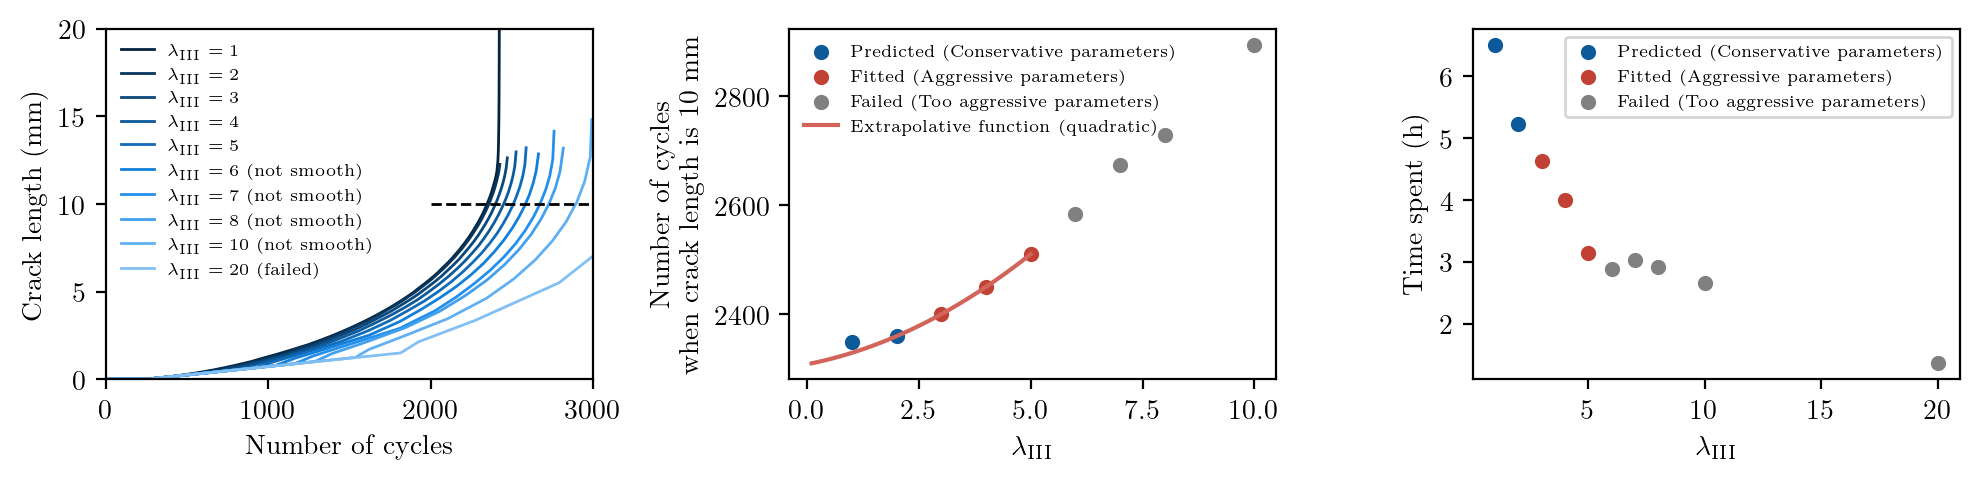

In [327]:
plt.figure(figsize=(10,2.5), dpi=200)

ax2 = plt.subplot(131)
ax2.set_ylim([0, 20])
ax2.set_xlim([0, 3000])

ax2.set_ylabel("Crack length (mm)")
ax2.set_xlabel("Number of cycles")


def plot_one(n_cycles, crack_lengths, label, color, delta_p=100, lw=2.5, **kwargs):
    ax2.plot(n_cycles, crack_lengths, color=color, ls="-", label=label, lw=lw, **kwargs)

# plot_one(n_cycles_jonas100_baseline, crack_lengths_jonas100_baseline, label=r"Baseline", color=global_palette[0], delta_p=100, lw=2.5)
plot_one(n_cycles_jonas100_jonas, crack_lengths_jonas100_jonas, label=r"$\lambda_{\mathrm{III}}=1$", color=lighten_color(global_palette[2], 1.3), delta_p=100, lw=1.)
plot_one(n_cycles_jonas100_jonas2, crack_lengths_jonas100_jonas2, label=r"$\lambda_{\mathrm{III}}=2$", color=lighten_color(global_palette[2], 1.2), delta_p=100, lw=1.)
plot_one(n_cycles_jonas100_jonas3, crack_lengths_jonas100_jonas3, label=r"$\lambda_{\mathrm{III}}=3$", color=lighten_color(global_palette[2], 1.1), delta_p=100, lw=1.)
plot_one(n_cycles_jonas100_jonas4, crack_lengths_jonas100_jonas4, label=r"$\lambda_{\mathrm{III}}=4$", color=lighten_color(global_palette[2], 1.0), delta_p=100, lw=1.)
plot_one(n_cycles_jonas100_jonas5, crack_lengths_jonas100_jonas5, label=r"$\lambda_{\mathrm{III}}=5$", color=lighten_color(global_palette[2], 0.9), delta_p=100, lw=1.)
plot_one(n_cycles_jonas100_jonas6, crack_lengths_jonas100_jonas6, label=r"$\lambda_{\mathrm{III}}=6$ (not smooth)", color=lighten_color(global_palette[2], 0.8), delta_p=100, lw=1.)
plot_one(n_cycles_jonas100_jonas7, crack_lengths_jonas100_jonas7, label=r"$\lambda_{\mathrm{III}}=7$ (not smooth)", color=lighten_color(global_palette[2], 0.7), delta_p=100, lw=1.)
plot_one(n_cycles_jonas100_jonas8, crack_lengths_jonas100_jonas8, label=r"$\lambda_{\mathrm{III}}=8$ (not smooth)", color=lighten_color(global_palette[2], 0.6), delta_p=100, lw=1.)
plot_one(n_cycles_jonas100_jonas10, crack_lengths_jonas100_jonas10, label=r"$\lambda_{\mathrm{III}}=10$ (not smooth)", color=lighten_color(global_palette[2], 0.5), delta_p=100, lw=1.)
plot_one(n_cycles_jonas100_jonas20, crack_lengths_jonas100_jonas20, label=r"$\lambda_{\mathrm{III}}=20$ (failed)", color=lighten_color(global_palette[2], 0.4), delta_p=100, lw=1.)
# plot_one(n_cycles_jonas100_yang, crack_lengths_jonas100_yang, label=f"Yang", color=global_palette[6], delta_p=100, lw=1.5)

ax2.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.6)

ax2.plot([2000, 3000], [10, 10], ls="--", lw=1, c="k")

ax = plt.subplot(132)

ax.scatter([1,2], [estimate_fatigue_life(*x, 10) for x in [[n_cycles_jonas100_jonas, crack_lengths_jonas100_jonas],[n_cycles_jonas100_jonas2, crack_lengths_jonas100_jonas2]]], s=20, c=global_palette[2], label="Predicted (Conservative parameters)")
ax.scatter([3,4,5], [estimate_fatigue_life(*x, 10) for x in [[n_cycles_jonas100_jonas3, crack_lengths_jonas100_jonas3], [n_cycles_jonas100_jonas4, crack_lengths_jonas100_jonas4],[n_cycles_jonas100_jonas5, crack_lengths_jonas100_jonas5]]], s=20, c=global_palette[5], label="Fitted (Aggressive parameters)")
ax.scatter([6,7,8,10], [estimate_fatigue_life(*x, 10) for x in [[n_cycles_jonas100_jonas6, crack_lengths_jonas100_jonas6],[n_cycles_jonas100_jonas7, crack_lengths_jonas100_jonas7],[n_cycles_jonas100_jonas8, crack_lengths_jonas100_jonas8],[n_cycles_jonas100_jonas10, crack_lengths_jonas100_jonas10]]], s=20, c="grey", label="Failed (Too aggressive parameters)")

def func(x, a, b, c):
    return a*x**2+b*x**1+c

from scipy.optimize import curve_fit

coeffs, _ = curve_fit(func,[3,4,5], [estimate_fatigue_life(*x, 10) for x in [[n_cycles_jonas100_jonas3, crack_lengths_jonas100_jonas3], [n_cycles_jonas100_jonas4, crack_lengths_jonas100_jonas4],[n_cycles_jonas100_jonas5, crack_lengths_jonas100_jonas5]]], p0=[0.1,0.1, 2100])
x = np.linspace(0.1, 5, 100)
ax.plot(x, func(x, *coeffs), lw=1.5, c=lighten_color(global_palette[5], 0.8), label=r"Extrapolative function (quadratic)")

ax.legend(loc="upper left", frameon=False, fontsize=plt.rcParams["font.size"]*0.6)

ax.set_ylabel("Number of cycles\nwhen crack length is 10 mm")
ax.set_xlabel(r"$\lambda_{\mathrm{III}}$")

ax = plt.subplot(133)

ax.scatter([1,2], [6.51, 5.23], s=20, c=global_palette[2], label="Predicted (Conservative parameters)")
ax.scatter([3, 4,5], [4.63, 4,3.14], s=20, c=global_palette[5], label="Fitted (Aggressive parameters)")
ax.scatter([6,7,8,10, 20], [2.88,3.03,2.91,2.66, 1.36], s=20, c="grey", label="Failed (Too aggressive parameters)")

ax.legend(loc="upper right", fontsize=plt.rcParams["font.size"]*0.6)

ax.set_ylabel("Time spent (h)")
ax.set_xlabel(r"$\lambda_{\mathrm{III}}$")

plt.tight_layout()
plt.savefig(os.path.join(plot_root, "pre-sensitivity-jonas.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()

In [28]:
n_cycles_jonas100_cojocaru200, crack_lengths_jonas100_cojocaru200 = get_phi_x_max("output/JonasCTParis100-2024-10-14-16-57-50-cojocaru200", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 2.87h
n_cycles_jonas100_cojocaru100, crack_lengths_jonas100_cojocaru100 = get_phi_x_max("output/JonasCTParis100-2024-10-14-16-58-17-cojocaru100", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 3.19h
n_cycles_jonas100_cojocaru50, crack_lengths_jonas100_cojocaru50 = get_phi_x_max("output/JonasCTParis100-2024-10-14-16-58-46-cojocaru50", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 3.72h
n_cycles_jonas100_cojocaru40, crack_lengths_jonas100_cojocaru40 = get_phi_x_max("output/JonasCTParis100-2024-10-15-10-16-52-cojocaru40", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 4.49
n_cycles_jonas100_cojocaru30, crack_lengths_jonas100_cojocaru30 = get_phi_x_max("output/JonasCTParis100-2024-10-15-10-18-13-cojocaru30", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 4.37
n_cycles_jonas100_cojocaru20, crack_lengths_jonas100_cojocaru20 = get_phi_x_max("output/JonasCTParis100-2024-10-15-10-18-31-cojocaru20", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 4.48
n_cycles_jonas100_cojocaru10, crack_lengths_jonas100_cojocaru10 = get_phi_x_max("output/JonasCTParis100-2024-10-14-16-59-05-cojocaru10", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 5.93

  0%|          | 0/38 [00:00<?, ?it/s]

  0%|          | 0/46 [00:00<?, ?it/s]

  0%|          | 0/56 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/68 [00:00<?, ?it/s]

  0%|          | 0/71 [00:00<?, ?it/s]

  0%|          | 0/119 [00:00<?, ?it/s]

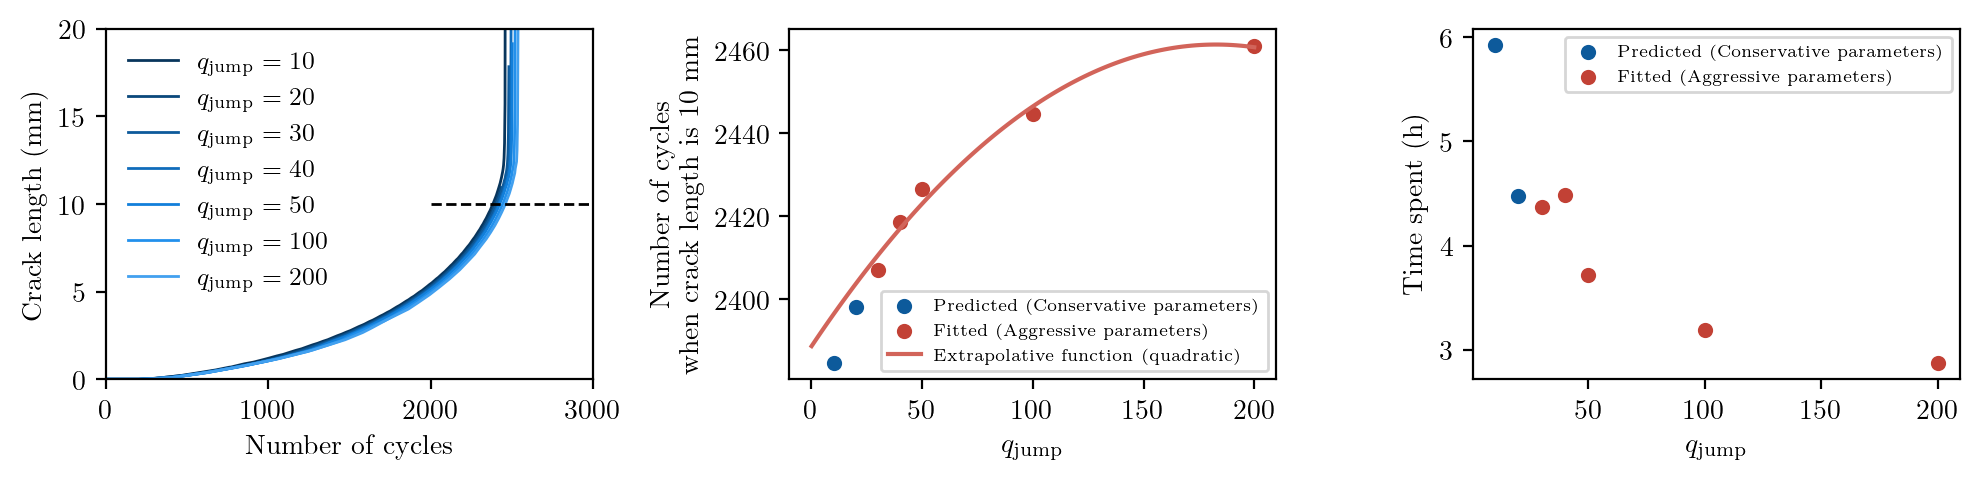

In [324]:
plt.figure(figsize=(10,2.5), dpi=200)

ax2 = plt.subplot(131)
ax2.set_ylim([0, 20])
ax2.set_xlim([0, 3000])

ax2.set_ylabel("Crack length (mm)")
ax2.set_xlabel("Number of cycles")


def plot_one(n_cycles, crack_lengths, label, color, delta_p=100, lw=2.5, **kwargs):
    ax2.plot(n_cycles, crack_lengths, color=color, ls="-", label=label, lw=lw, **kwargs)

# plot_one(n_cycles_jonas100_baseline, crack_lengths_jonas100_baseline, label=r"Baseline", color=global_palette[0], delta_p=100, lw=2.5)
plot_one(n_cycles_jonas100_cojocaru10, crack_lengths_jonas100_cojocaru10, label=r"$q_{\mathrm{jump}} = 10$", color=lighten_color(global_palette[2], 1.2), delta_p=100, lw=1.)
plot_one(n_cycles_jonas100_cojocaru20, crack_lengths_jonas100_cojocaru20, label=r"$q_{\mathrm{jump}} = 20$", color=lighten_color(global_palette[2], 1.1), delta_p=100, lw=1.)
plot_one(n_cycles_jonas100_cojocaru30, crack_lengths_jonas100_cojocaru30, label=r"$q_{\mathrm{jump}} = 30$", color=lighten_color(global_palette[2], 1.0), delta_p=100, lw=1.)
plot_one(n_cycles_jonas100_cojocaru40, crack_lengths_jonas100_cojocaru40, label=r"$q_{\mathrm{jump}} = 40$", color=lighten_color(global_palette[2], 0.9), delta_p=100, lw=1.)
plot_one(n_cycles_jonas100_cojocaru50, crack_lengths_jonas100_cojocaru50, label=r"$q_{\mathrm{jump}} = 50$", color=lighten_color(global_palette[2], 0.8), delta_p=100, lw=1.)
plot_one(n_cycles_jonas100_cojocaru100, crack_lengths_jonas100_cojocaru100, label=r"$q_{\mathrm{jump}} = 100$", color=lighten_color(global_palette[2], 0.7), delta_p=100, lw=1.)
plot_one(n_cycles_jonas100_cojocaru200, crack_lengths_jonas100_cojocaru200, label=r"$q_{\mathrm{jump}} = 200$", color=lighten_color(global_palette[2], 0.6), delta_p=100, lw=1.)

ax2.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.9)

ax2.plot([2000, 3000], [10, 10], ls="--", lw=1, c="k")

ax = plt.subplot(132)

ax.scatter([10,20], [estimate_fatigue_life(*x, 10) for x in [[n_cycles_jonas100_cojocaru10, crack_lengths_jonas100_cojocaru10], [n_cycles_jonas100_cojocaru20, crack_lengths_jonas100_cojocaru20],]], s=20, c=global_palette[2], label="Predicted (Conservative parameters)")
ax.scatter([30,40,50,100,200], [estimate_fatigue_life(*x, 10) for x in [[n_cycles_jonas100_cojocaru30, crack_lengths_jonas100_cojocaru30], [n_cycles_jonas100_cojocaru40, crack_lengths_jonas100_cojocaru40], [n_cycles_jonas100_cojocaru50, crack_lengths_jonas100_cojocaru50], [n_cycles_jonas100_cojocaru100, crack_lengths_jonas100_cojocaru100], [n_cycles_jonas100_cojocaru200, crack_lengths_jonas100_cojocaru200]]], s=20, c=global_palette[5], label="Fitted (Aggressive parameters)")


def func(x, b, c, d):
    return b*x**2+c*x+d

from scipy.optimize import curve_fit

coeffs, _ = curve_fit(func, [30,40,50,100,200], [estimate_fatigue_life(*x, 10) for x in [[n_cycles_jonas100_cojocaru30, crack_lengths_jonas100_cojocaru30], [n_cycles_jonas100_cojocaru40, crack_lengths_jonas100_cojocaru40], [n_cycles_jonas100_cojocaru50, crack_lengths_jonas100_cojocaru50], [n_cycles_jonas100_cojocaru100, crack_lengths_jonas100_cojocaru100], [n_cycles_jonas100_cojocaru200, crack_lengths_jonas100_cojocaru200]]], p0=[-1, 1, 2500])
x = np.linspace(0.1, 200, 100)
ax.plot(x, func(x, *coeffs), lw=1.5, c=lighten_color(global_palette[5], 0.8), label="Extrapolative function (quadratic)")

ax.legend(loc="lower right", fontsize=plt.rcParams["font.size"]*0.6)

ax.set_ylabel("Number of cycles\nwhen crack length is 10 mm")
ax.set_xlabel(r"$q_{\mathrm{jump}}$")

ax = plt.subplot(133)

ax.scatter([10,20], [5.93,4.48], s=20, c=global_palette[2], label="Predicted (Conservative parameters)")
ax.scatter([30,40,50,100,200], [4.37,4.49,3.72,3.19,2.87], s=20, c=global_palette[5], label="Fitted (Aggressive parameters)")

ax.legend(loc="upper right", fontsize=plt.rcParams["font.size"]*0.6)

ax.set_ylabel("Time spent (h)")
ax.set_xlabel(r"$q_{\mathrm{jump}}$")

plt.tight_layout()
plt.savefig(os.path.join(plot_root, "pre-sensitivity-cojocaru.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()

In [65]:
n_cycles_jonas100_jaccon200, crack_lengths_jonas100_jaccon200 = get_phi_x_max("output/JonasCTParis100-2024-10-14-17-00-10-jaccon200", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 5.06h
n_cycles_jonas100_jaccon100, crack_lengths_jonas100_jaccon100 = get_phi_x_max("output/JonasCTParis100-2024-10-14-17-00-31-jaccon100", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 13.28h
n_cycles_jonas100_jaccon50, crack_lengths_jonas100_jaccon50 = get_phi_x_max("output/JonasCTParis100-2024-10-14-17-00-57-jaccon50", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 22.81h
n_cycles_jonas100_jaccon10, crack_lengths_jonas100_jaccon10 = get_phi_x_max("output/JonasCTParis100-2024-10-14-17-01-11-jaccon10", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 24.64h

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/42 [00:00<?, ?it/s]

  0%|          | 0/249 [00:00<?, ?it/s]

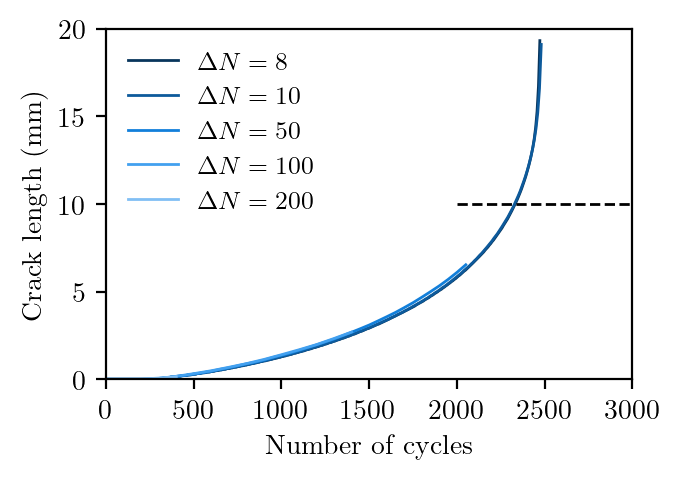

In [325]:
plt.figure(figsize=(3.5,2.5), dpi=200)

ax2 = plt.subplot(111)
ax2.set_ylim([0, 20])
ax2.set_xlim([0, 3000])

ax2.set_ylabel("Crack length (mm)")
ax2.set_xlabel("Number of cycles")


def plot_one(n_cycles, crack_lengths, label, color, delta_p=100, lw=2.5, **kwargs):
    ax2.plot(n_cycles, crack_lengths, color=color, ls="-", label=label, lw=lw, **kwargs)

plot_one(n_cycles_jonas100_jaccon, crack_lengths_jonas100_jaccon, label=f"$\Delta N=8$", color=lighten_color(global_palette[2], 1.2), delta_p=100, lw=1.)
plot_one(n_cycles_jonas100_jaccon10, crack_lengths_jonas100_jaccon10, label=f"$\Delta N=10$", color=lighten_color(global_palette[2], 1.), delta_p=100, lw=1.)
plot_one(n_cycles_jonas100_jaccon50, crack_lengths_jonas100_jaccon50, label=f"$\Delta N=50$", color=lighten_color(global_palette[2], 0.8), delta_p=100, lw=1.)
plot_one(n_cycles_jonas100_jaccon100, crack_lengths_jonas100_jaccon100, label=f"$\Delta N=100$", color=lighten_color(global_palette[2], 0.6), delta_p=100, lw=1)
plot_one(n_cycles_jonas100_jaccon200, crack_lengths_jonas100_jaccon200, label=f"$\Delta N=200$", color=lighten_color(global_palette[2], 0.4), delta_p=100, lw=1.)

ax2.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.9)

ax2.plot([2000, 3000], [10, 10], ls="--", lw=1, c="k")

plt.tight_layout()
plt.savefig(os.path.join(plot_root, "pre-sensitivity-jaccon.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()

In [61]:
n_cycles_jonas100_yang1e2, crack_lengths_jonas100_yang1e2 = get_phi_x_max("output/JonasCTParis100-2024-10-14-20-38-07-yang1e2", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 4.81h
n_cycles_jonas100_yang9e3, crack_lengths_jonas100_yang9e3 = get_phi_x_max("output/JonasCTParis100-2024-10-15-10-37-06-yang9e3", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 5.03h
n_cycles_jonas100_yang8e3, crack_lengths_jonas100_yang8e3 = get_phi_x_max("output/JonasCTParis100-2024-10-15-15-02-57-yang8e3", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 4.27h
n_cycles_jonas100_yang7e3, crack_lengths_jonas100_yang7e3 = get_phi_x_max("output/JonasCTParis100-2024-10-15-10-33-47-yang7e3", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 5.14h
n_cycles_jonas100_yang6e3, crack_lengths_jonas100_yang6e3 = get_phi_x_max("output/JonasCTParis100-2024-10-15-15-03-09-yang6e3", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 4.75h
n_cycles_jonas100_yang5e3, crack_lengths_jonas100_yang5e3 = get_phi_x_max("output/JonasCTParis100-2024-10-14-20-37-48-yang5e3", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 4.37h
n_cycles_jonas100_yang3e3, crack_lengths_jonas100_yang3e3 = get_phi_x_max("output/JonasCTParis100-2024-10-15-10-22-26-yang3e3", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 4.82h
n_cycles_jonas100_yang1e3, crack_lengths_jonas100_yang1e3 = get_phi_x_max("output/JonasCTParis100-2024-10-14-20-37-31-yang1e3", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 6.58h
n_cycles_jonas100_yang5e4, crack_lengths_jonas100_yang5e4 = get_phi_x_max("output/JonasCTParis100-2024-10-14-20-36-57-yang5e4", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 8.96h
n_cycles_jonas100_yang1e4, crack_lengths_jonas100_yang1e4 = get_phi_x_max("output/JonasCTParis100-2024-10-14-20-36-35-yang1e4", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True, read_every=10) # 14.75h

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/54 [00:00<?, ?it/s]

  0%|          | 0/58 [00:00<?, ?it/s]

  0%|          | 0/63 [00:00<?, ?it/s]

  0%|          | 0/70 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

  0%|          | 0/116 [00:00<?, ?it/s]

  0%|          | 0/242 [00:00<?, ?it/s]

  0%|          | 0/365 [00:00<?, ?it/s]

  0%|          | 0/89 [00:00<?, ?it/s]

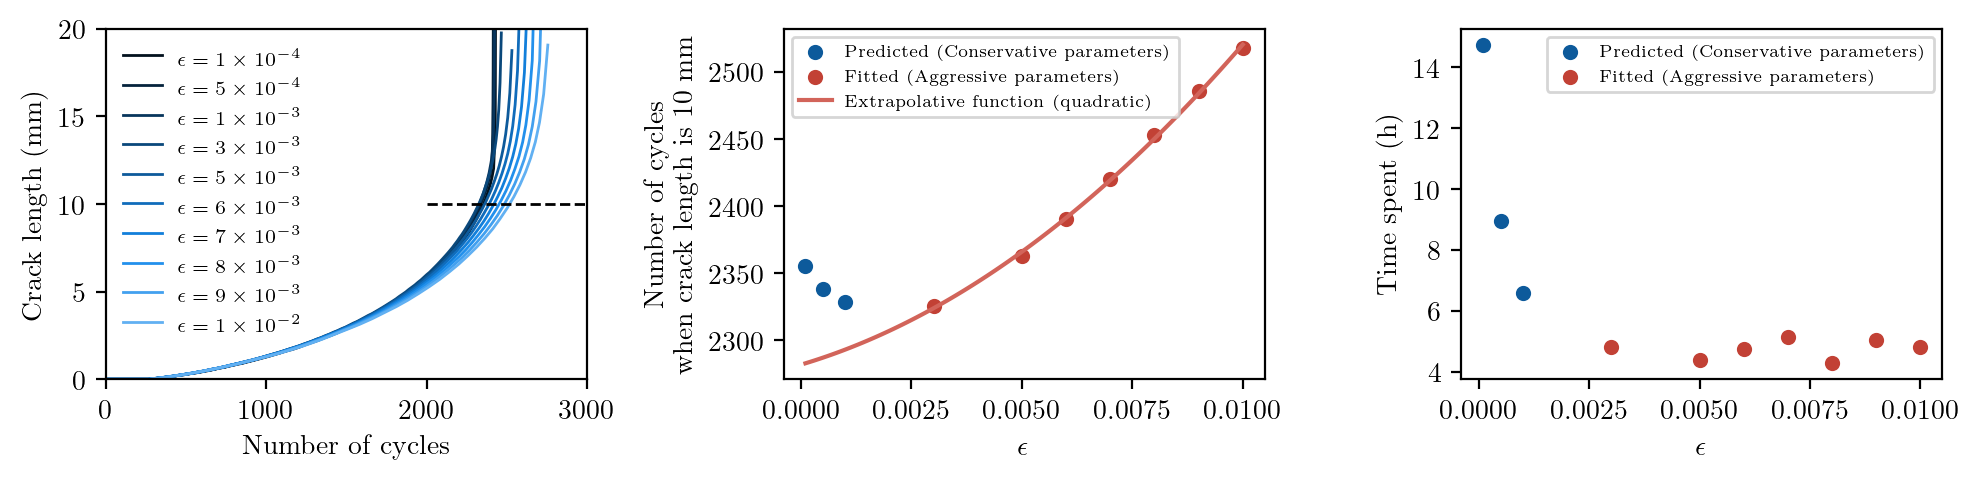

In [326]:
plt.figure(figsize=(10,2.5), dpi=200)

ax2 = plt.subplot(131)
ax2.set_ylim([0, 20])
ax2.set_xlim([0, 3000])

ax2.set_ylabel("Crack length (mm)")
ax2.set_xlabel("Number of cycles")

def plot_one(n_cycles, crack_lengths, label, color, delta_p=100, lw=2.5, **kwargs):
    ax2.plot(n_cycles, crack_lengths, color=color, ls="-", label=label, lw=lw, **kwargs)

# plot_one(n_cycles_jonas100_baseline, crack_lengths_jonas100_baseline, label=r"Baseline", color=global_palette[0], delta_p=100, lw=2.5)
plot_one(n_cycles_jonas100_yang1e4, crack_lengths_jonas100_yang1e4, label=r"$\epsilon=1\times 10^{-4}$", color=lighten_color(global_palette[2], 1.4), delta_p=100, lw=1.)
plot_one(n_cycles_jonas100_yang5e4, crack_lengths_jonas100_yang5e4, label=r"$\epsilon=5\times 10^{-4}$", color=lighten_color(global_palette[2], 1.3), delta_p=100, lw=1.)
plot_one(n_cycles_jonas100_yang1e3, crack_lengths_jonas100_yang1e3, label=r"$\epsilon=1\times 10^{-3}$", color=lighten_color(global_palette[2], 1.2), delta_p=100, lw=1.)
plot_one(n_cycles_jonas100_yang3e3, crack_lengths_jonas100_yang3e3, label=r"$\epsilon=3\times 10^{-3}$", color=lighten_color(global_palette[2], 1.1), delta_p=100, lw=1.)
plot_one(n_cycles_jonas100_yang5e3, crack_lengths_jonas100_yang5e3, label=r"$\epsilon=5\times 10^{-3}$", color=lighten_color(global_palette[2], 1.0), delta_p=100, lw=1.)
plot_one(n_cycles_jonas100_yang6e3, crack_lengths_jonas100_yang6e3, label=r"$\epsilon=6\times 10^{-3}$", color=lighten_color(global_palette[2], 0.9), delta_p=100, lw=1.)
plot_one(n_cycles_jonas100_yang7e3, crack_lengths_jonas100_yang7e3, label=r"$\epsilon=7\times 10^{-3}$", color=lighten_color(global_palette[2], 0.8), delta_p=100, lw=1.)
plot_one(n_cycles_jonas100_yang8e3, crack_lengths_jonas100_yang8e3, label=r"$\epsilon=8\times 10^{-3}$", color=lighten_color(global_palette[2], 0.7), delta_p=100, lw=1.)
plot_one(n_cycles_jonas100_yang9e3, crack_lengths_jonas100_yang9e3, label=r"$\epsilon=9\times 10^{-3}$", color=lighten_color(global_palette[2], 0.6), delta_p=100, lw=1.)
plot_one(n_cycles_jonas100_yang1e2, crack_lengths_jonas100_yang1e2, label=r"$\epsilon=1\times 10^{-2}$", color=lighten_color(global_palette[2], 0.5), delta_p=100, lw=1.)

ax2.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.7)

ax2.plot([2000, 3000], [10, 10], ls="--", lw=1, c="k")

ax = plt.subplot(132)

ax.scatter([1e-4,5e-4,1e-3,], [estimate_fatigue_life(*x, 10) for x in [[n_cycles_jonas100_yang1e4, crack_lengths_jonas100_yang1e4], [n_cycles_jonas100_yang5e4, crack_lengths_jonas100_yang5e4], [n_cycles_jonas100_yang1e3, crack_lengths_jonas100_yang1e3], ]], s=20, c=global_palette[2], label="Predicted (Conservative parameters)")
ax.scatter([3e-3, 5e-3, 6e-3,7e-3, 8e-3,9e-3,1e-2], [estimate_fatigue_life(*x, 10) for x in [[n_cycles_jonas100_yang3e3, crack_lengths_jonas100_yang3e3],[n_cycles_jonas100_yang5e3, crack_lengths_jonas100_yang5e3], [n_cycles_jonas100_yang6e3, crack_lengths_jonas100_yang6e3], [n_cycles_jonas100_yang7e3, crack_lengths_jonas100_yang7e3], [n_cycles_jonas100_yang8e3, crack_lengths_jonas100_yang8e3], [n_cycles_jonas100_yang9e3, crack_lengths_jonas100_yang9e3],[n_cycles_jonas100_yang1e2, crack_lengths_jonas100_yang1e2]]], s=20, c=global_palette[5], label="Fitted (Aggressive parameters)")
# ax.scatter([100,200,300,400,500], [estimate_fatigue_life(*x, 10) for x in [[n_cycles_jonas100_cojocaru100, crack_lengths_jonas100_cojocaru100], [n_cycles_jonas100_cojocaru200, crack_lengths_jonas100_cojocaru200], [n_cycles_jonas100_cojocaru300, crack_lengths_jonas100_cojocaru300], [n_cycles_jonas100_cojocaru400, crack_lengths_jonas100_cojocaru400], [n_cycles_jonas100_cojocaru500, crack_lengths_jonas100_cojocaru500]]], s=20, c="grey", label="Failed (Too aggressive parameters)")


def func(x, b, c, d):
    return b*x**2+c*x+d

from scipy.optimize import curve_fit

coeffs, _ = curve_fit(func, [3e-3, 5e-3, 6e-3,7e-3, 8e-3,9e-3,1e-2], [estimate_fatigue_life(*x, 10) for x in [[n_cycles_jonas100_yang3e3, crack_lengths_jonas100_yang3e3],[n_cycles_jonas100_yang5e3, crack_lengths_jonas100_yang5e3], [n_cycles_jonas100_yang6e3, crack_lengths_jonas100_yang6e3], [n_cycles_jonas100_yang7e3, crack_lengths_jonas100_yang7e3], [n_cycles_jonas100_yang8e3, crack_lengths_jonas100_yang8e3], [n_cycles_jonas100_yang9e3, crack_lengths_jonas100_yang9e3],[n_cycles_jonas100_yang1e2, crack_lengths_jonas100_yang1e2]]], p0=[1, 1, 2500])
x = np.linspace(1e-4, 1e-2, 100)
ax.plot(x, func(x, *coeffs), lw=1.5, c=lighten_color(global_palette[5], 0.8), label="Extrapolative function (quadratic)")

ax.legend(loc="upper left", fontsize=plt.rcParams["font.size"]*0.6)

# ax.set_xscale("log")
ax.set_ylabel("Number of cycles\nwhen crack length is 10 mm")
ax.set_xlabel(r"$\epsilon$")

ax = plt.subplot(133)

ax.scatter([1e-4,5e-4,1e-3,], [14.75, 8.96,6.58], s=20, c=global_palette[2], label="Predicted (Conservative parameters)")
ax.scatter([3e-3, 5e-3, 6e-3,7e-3, 8e-3,9e-3,1e-2], [4.82,4.37,4.75,5.14,4.27,5.03,4.81], s=20, c=global_palette[5], label="Fitted (Aggressive parameters)")

ax.legend(loc="upper right", fontsize=plt.rcParams["font.size"]*0.6)

ax.set_ylabel("Time spent (h)")
ax.set_xlabel(r"$\epsilon$")

plt.tight_layout()
plt.savefig(os.path.join(plot_root, "pre-sensitivity-yang.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()

## Compare with single-pass

In [8]:
n_cycles_jonas100_cla50, crack_lengths_jonas100_cla50 = get_phi_x_max("output/JonasCTParis100-2024-10-14-16-56-36-cla50", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 1.62h
n_cycles_jonas100_cla10, crack_lengths_jonas100_cla10 = get_phi_x_max("output/JonasCTParis100-2024-10-14-16-56-59-cla10", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 4.90h

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/251 [00:00<?, ?it/s]

Reaching the end of the mesh.


In [5]:
W=50
n_cycles_jonas100_cla50_single, crack_lengths_jonas100_cla50_single = get_phi_x_max("output/JonasCTParis100-2024-10-29-12-32-44-cla50-singlepass", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) 
n_cycles_jonas100_cla50_multi, crack_lengths_jonas100_cla50_multi = get_phi_x_max("output/JonasCTParis100-2024-10-29-12-32-11-cla50-multipass", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) 
n_cycles_jonas100_cla10_single, crack_lengths_jonas100_cla10_single = get_phi_x_max("output/JonasCTParis100-2024-10-29-12-30-31-cla10-singlepass", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) 
n_cycles_jonas100_cla10_multi, crack_lengths_jonas100_cla10_multi = get_phi_x_max("output/JonasCTParis100-2024-10-29-12-31-10-cla10-multipass", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) 

n_cycles_jonas100_cla_single, crack_lengths_jonas100_cla_single = get_phi_x_max("output/JonasCTParis100-2024-10-29-16-15-16-cla-singlepass", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) 
n_cycles_jonas100_cla, crack_lengths_jonas100_cla = get_phi_x_max("output/JonasCTParis100-2024-09-15-16-18-18-cla", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 11.52h

  0%|          | 0/61 [00:00<?, ?it/s]

  0%|          | 0/42 [00:00<?, ?it/s]

  0%|          | 0/301 [00:00<?, ?it/s]

  0%|          | 0/181 [00:00<?, ?it/s]

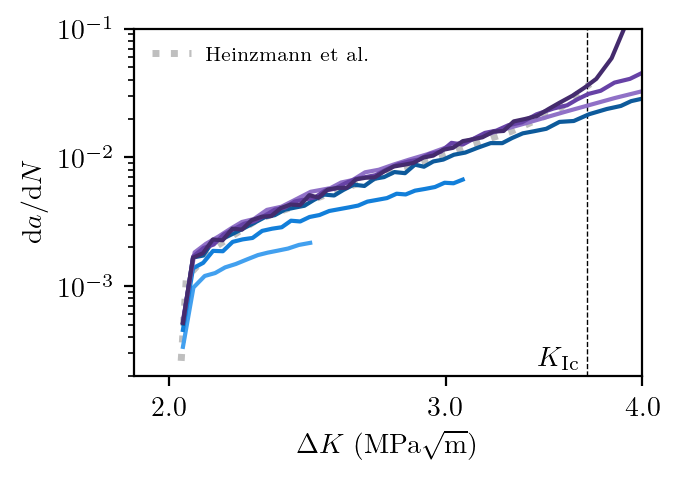

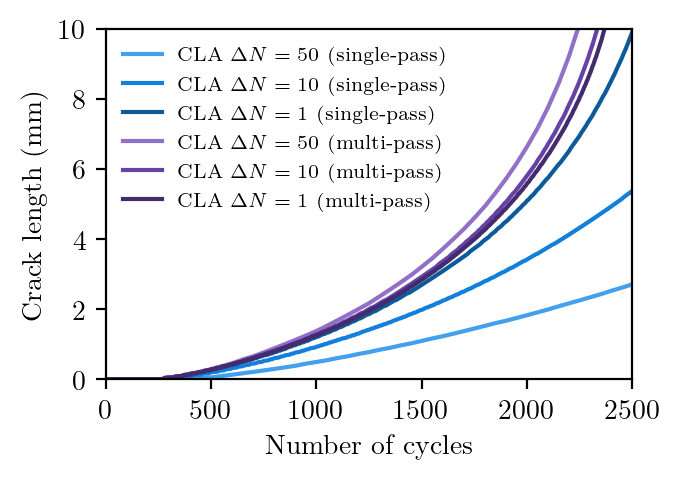

In [73]:
ref_df = pd.read_csv("ref/jonas-ct-100N.csv")

plt.figure(figsize=(3.5,2.5), dpi=200)

ax1 = plt.subplot(111)

ax1.plot(ref_df["x"], ref_df[" y"], color="grey", ls=":", alpha=0.5, label=r"Heinzmann et al.", lw=2.5)
ax1.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.7)

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlim([1.9, 4.0])

ax1.set_ylim([2e-4, 1e-1])
ylim = ax1.get_ylim()
ax1.plot([3.69, 3.69], ax1.get_ylim(), ls="--", lw=0.5, color="black")
ax1.set_ylim(ylim)
ax1.text(3.65, ylim[0]*1.1, r"$K_{\mathrm{Ic}}$", ha="right", va="bottom", transform=ax1.transData)
ax1.set_xticks([ 2.0, 3.0, 4.0])
ax1.set_xticklabels([2.0, 3.0, 4.0])
ax1.set_ylabel(r"$\mathrm{d}a/\mathrm{d}N$")
ax1.set_xlabel(r"$\Delta K$ (MPa$\sqrt{\mathrm{m}}$)")


plt.figure(figsize=(3.5,2.5), dpi=200)

ax2 = plt.subplot(111)
ax2.set_ylim([0, 10])
ax2.set_xlim([0, 2500])

ax2.set_ylabel("Crack length (mm)")
ax2.set_xlabel("Number of cycles")


def plot_one(n_cycles, crack_lengths, label, color, delta_p=100, lw=2.5, **kwargs):
    recorded_cycle, lengths, da_dn, delta_k = incremental_growth(n_cycles, crack_lengths, delta_p=delta_p, T=1, W=50)
    ax1.plot(delta_k, da_dn, color=color, ls="-", label=label, lw=lw, **kwargs)
    ax2.plot(n_cycles, crack_lengths, color=color, ls="-", label=label, lw=lw, **kwargs)

plot_one(n_cycles_jonas100_cla50_single, crack_lengths_jonas100_cla50_single, label=r"CLA $\Delta N=50$ (single-pass)", color=lighten_color(global_palette[2], 0.6), delta_p=100, lw=1.5)
plot_one(n_cycles_jonas100_cla10_single, crack_lengths_jonas100_cla10_single, label=r"CLA $\Delta N=10$ (single-pass)", color=lighten_color(global_palette[2], 0.8), delta_p=100, lw=1.5)
plot_one(n_cycles_jonas100_cla_single, crack_lengths_jonas100_cla_single, label=r"CLA $\Delta N=1$ (single-pass)", color=lighten_color(global_palette[2], 1.0), delta_p=100, lw=1.5)
plot_one(n_cycles_jonas100_cla50, crack_lengths_jonas100_cla50, label=r"CLA $\Delta N=50$ (multi-pass)", color=lighten_color(global_palette[4], 0.5), delta_p=100, lw=1.5)
plot_one(n_cycles_jonas100_cla10, crack_lengths_jonas100_cla10, label=r"CLA $\Delta N=10$ (multi-pass)", color=lighten_color(global_palette[4], 0.7), delta_p=100, lw=1.5)
plot_one(n_cycles_jonas100_cla, crack_lengths_jonas100_cla, label=r"CLA $\Delta N=1$ (multi-pass)", color=lighten_color(global_palette[4], 0.9), delta_p=100, lw=1.5)
# plot_one(n_cycles_jonas100_cla50_multi, crack_lengths_jonas100_cla50_multi, label=r"CLA $\Delta N=50$ (multi-pass)", color=global_palette[2], delta_p=100, lw=1.5)
# plot_one(n_cycles_jonas100_cla10_multi, crack_lengths_jonas100_cla10_multi, label=r"CLA $\Delta N=10$ (multi-pass)", color=global_palette[5], delta_p=100, lw=1.5)

ax2.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.7)

# ax1.figure.savefig(os.path.join(plot_root, "jonas100-growthrate-compare.pdf"), dpi=500, bbox_inches="tight")
# ax2.figure.savefig(os.path.join(plot_root, "jonas100-cracklength-compare.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()

# Order of elements

In [13]:
W=50
n_cycles_jonas100_cla_1order, crack_lengths_jonas100_cla_1order = get_phi_x_max("output/JonasCTParis100-2024-10-29-07-48-07", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) 
n_cycles_jonas100_cla_1orderlabotto, crack_lengths_jonas100_cla_1orderlabotto = get_phi_x_max("output/JonasCTParis100-2024-10-29-16-43-17-cla-1storderlabotto", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) 

FileNotFoundError: [Errno 2] No such file or directory: 'output/JonasCTParis100-2024-10-29-07-48-07'

In [8]:
n_cycles_jonas100_cla, crack_lengths_jonas100_cla = get_phi_x_max("output/JonasCTParis100-2024-09-15-16-18-18-cla", crack_tip=(0.25+0.22)*W, cycle_per_file=1, infer_cycle_by_name=True) # 11.52h

  0%|          | 0/613 [00:00<?, ?it/s]

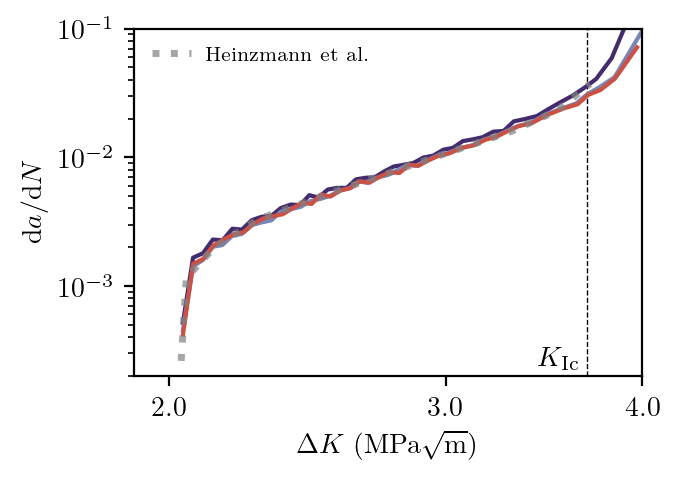

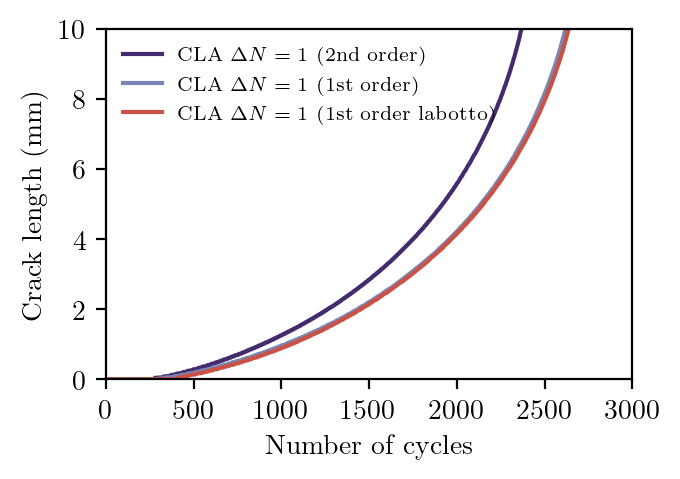

In [9]:
ref_df = pd.read_csv("ref/jonas-ct-100N.csv")

plt.figure(figsize=(3.5,2.5), dpi=200)

ax1 = plt.subplot(111)

ax1.plot(ref_df["x"], ref_df[" y"], color="grey", ls=":", alpha=0.7, label=r"Heinzmann et al.", lw=2.5, zorder=10)
ax1.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.7)

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlim([1.9, 4.0])

ax1.set_ylim([2e-4, 1e-1])
ylim = ax1.get_ylim()
ax1.plot([3.69, 3.69], ax1.get_ylim(), ls="--", lw=0.5, color="black")
ax1.set_ylim(ylim)
ax1.text(3.65, ylim[0]*1.1, r"$K_{\mathrm{Ic}}$", ha="right", va="bottom", transform=ax1.transData)
ax1.set_xticks([ 2.0, 3.0, 4.0])
ax1.set_xticklabels([2.0, 3.0, 4.0])
ax1.set_ylabel(r"$\mathrm{d}a/\mathrm{d}N$")
ax1.set_xlabel(r"$\Delta K$ (MPa$\sqrt{\mathrm{m}}$)")


plt.figure(figsize=(3.5,2.5), dpi=200)

ax2 = plt.subplot(111)
ax2.set_ylim([0, 10])
ax2.set_xlim([0, 3000])

ax2.set_ylabel("Crack length (mm)")
ax2.set_xlabel("Number of cycles")


def plot_one(n_cycles, crack_lengths, label, color, delta_p=100, lw=2.5, **kwargs):
    recorded_cycle, lengths, da_dn, delta_k = incremental_growth(n_cycles, crack_lengths, delta_p=delta_p, T=1, W=50)
    ax1.plot(delta_k, da_dn, color=color, ls="-", label=label, lw=lw, **kwargs)
    ax2.plot(n_cycles, crack_lengths, color=color, ls="-", label=label, lw=lw, **kwargs)

plot_one(n_cycles_jonas100_cla, crack_lengths_jonas100_cla, label=r"CLA $\Delta N=1$ (2nd order)", color=lighten_color(global_palette[4], 0.9), delta_p=100, lw=1.5)
plot_one(n_cycles_jonas100_cla_1order, crack_lengths_jonas100_cla_1order, label=r"CLA $\Delta N=1$ (1st order)", color=lighten_color(global_palette[3], 0.9), delta_p=100, lw=1.5)
plot_one(n_cycles_jonas100_cla_1orderlabotto, crack_lengths_jonas100_cla_1orderlabotto, label=r"CLA $\Delta N=1$ (1st order labotto)", color=lighten_color(global_palette[5], 0.9), delta_p=100, lw=1.5)

ax2.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.7)

# ax1.figure.savefig(os.path.join(plot_root, "jonas100-growthrate-compare.pdf"), dpi=500, bbox_inches="tight")
# ax2.figure.savefig(os.path.join(plot_root, "jonas100-cracklength-compare.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()

In [25]:
ref_df = pd.read_csv("ref/carrara-singlenotch-spectral.csv")
n_cycles_1st, crack_lengths_1st = get_phi_x_max("output/singleNotchTensionFatigueCarrara-2024-10-31-10-31-59-1storder", crack_tip=0.5, cycle_per_file=1)
n_cycles_2nd, crack_lengths_2nd = get_phi_x_max("output/singleNotchTensionFatigueCarrara-2024-10-31-10-32-10-2ndorder", crack_tip=0.5, cycle_per_file=1)

  0%|          | 0/401 [00:00<?, ?it/s]

Reaching the end of the mesh.
Reaching the end of the mesh.
Reaching the end of the mesh.
Reaching the end of the mesh.
Reaching the end of the mesh.
Reaching the end of the mesh.
Reaching the end of the mesh.
Reaching the end of the mesh.
Reaching the end of the mesh.
Reaching the end of the mesh.
Reaching the end of the mesh.


  0%|          | 0/401 [00:00<?, ?it/s]

Reaching the end of the mesh.
Reaching the end of the mesh.
Reaching the end of the mesh.
Reaching the end of the mesh.
Reaching the end of the mesh.
Reaching the end of the mesh.
Reaching the end of the mesh.
Reaching the end of the mesh.
Reaching the end of the mesh.
Reaching the end of the mesh.
Reaching the end of the mesh.
Reaching the end of the mesh.
Reaching the end of the mesh.
Reaching the end of the mesh.
Reaching the end of the mesh.
Reaching the end of the mesh.
Reaching the end of the mesh.
Reaching the end of the mesh.
Reaching the end of the mesh.
Reaching the end of the mesh.
Reaching the end of the mesh.
Reaching the end of the mesh.
Reaching the end of the mesh.
Reaching the end of the mesh.
Reaching the end of the mesh.
Reaching the end of the mesh.
Reaching the end of the mesh.


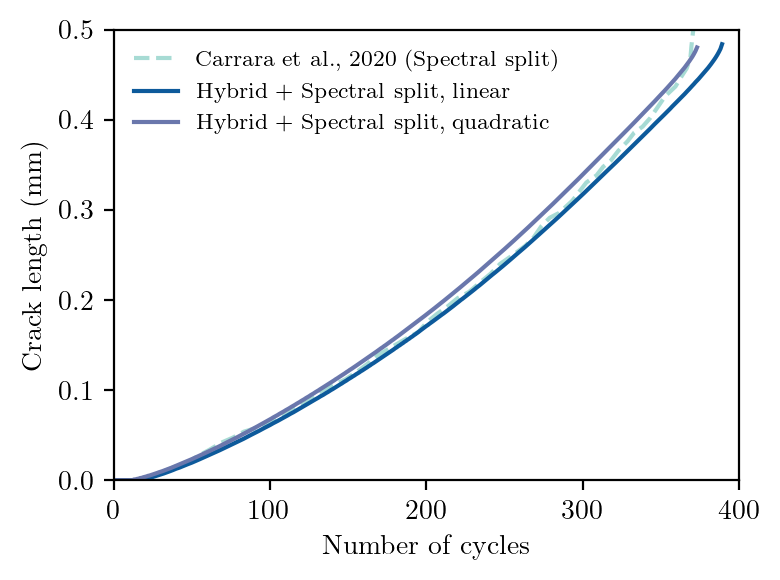

In [26]:
plt.figure(figsize=(4,3), dpi=200)

ax = plt.subplot(111)
ax.plot(ref_df["x"], ref_df[" y"], ls="--", color=global_palette[1], label="Carrara et al., 2020 (Spectral split)", alpha=0.5)
ax.plot(n_cycles_1st, crack_lengths_1st, ls="-", color=global_palette[2], label="Hybrid + Spectral split, linear")
ax.plot(n_cycles_2nd, crack_lengths_2nd, ls="-", color=global_palette[3], label="Hybrid + Spectral split, quadratic")
# ax.plot(np.array(n_cycles_no_tension), np.array(crack_lengths_no_tension), ls="-", color=global_palette[1], label="My code (No-tension split)")
ax.legend(loc="upper left", fancybox=False, frameon=False, fontsize=plt.rcParams["font.size"]*0.8)
ax.set_xlim([0, 400])
ax.set_ylim([0, 0.5])
ax.set_xlabel("Number of cycles")
ax.set_ylabel("Crack length (mm)")
plt.savefig(os.path.join(plot_root, "carrara-singlenotch-spectral-order.pdf"), dpi=500, bbox_inches="tight")
plt.show()
plt.close()

# Automatic program test

In [17]:
scheme_parameter = {
    "JonasCLA": ("Adaptive timestep parameters", 5, r"$\lambda_{\mathrm{II}}=\lambda_{\mathrm{III}}$"),
    "Jonas": ("Adaptive timestep parameters", 5, r"$\lambda_{\mathrm{II}}=\lambda_{\mathrm{III}}$"),
    "KristensenCLA": ("Adaptive timestep parameters", 3, r"$\Delta N$"),
    "Cojocaru": ("Adaptive timestep parameters", 3, r"$q_{\mathrm{jump}}=N_{\mathrm{maxjump}}$"),
    "CojocaruCLA": ("Adaptive timestep parameters", 3, r"$q_{\mathrm{jump}}=N_{\mathrm{maxjump}}$"),
    "Yang": ("Adaptive timestep parameters", 2, r"$\epsilon$"),
    "Jaccon": ("Adaptive timestep parameters", 2, r"$\Delta N$"),
}

In [65]:
def plot_one_scheme(path, fig_name=None, log_x=False):
    import re
    with open(path, "r") as file:
        s = file.read()
    scheme = re.findall(r"Using acceleration scheme: (.*?)\n", s)[0]

    lifes = [int(x) for x in re.findall(r"Cycle: (.*?). Crack length: .*?\n.*? \b(?:Process|Rough|Spike|Stationary)\b", s)]
    times = [float(x) for x in re.findall(r"Time spent: .*?min, (.*?) h", s)]
    parameters = [float(eval(x)[scheme_parameter[scheme][0]].split(" ")[scheme_parameter[scheme][1]-1]) for x in re.findall(r"Parameters: (.*?)\n", s)]

    fig = plt.figure(figsize=(6,2.5), dpi=200)

    ax = plt.subplot(121)
    print(parameters, lifes, sum(times))
    ax.scatter(parameters, lifes, s=20, c=global_palette[2])
    
    if log_x:
        ax.set_xscale("log")
        
    # xlim = ax.get_xlim()
    # ax.plot(xlim, [3000]*2, lw=1.5, c="grey", zorder=0, alpha=0.7)
    # ax.set_xlim(xlim)
    
    ax.set_ylabel("Number of cycles\nwhen the job is terminated")
    ax.set_xlabel(scheme_parameter[scheme][2])

    ax = plt.subplot(122)

    ax.scatter(parameters, times, s=20, c=global_palette[2])

    ax.set_ylabel("Time spent (h)")
    ax.set_xlabel(scheme_parameter[scheme][2])
    if log_x:
        ax.set_xscale("log")

    plt.tight_layout()
    if fig_name is None:
        return fig
    else:
        plt.savefig(os.path.join(plot_root, fig_name), dpi=500, bbox_inches="tight")

[10.0, 5.0, 2.5, 1.25] [3264, 2940, 2776, 2714] 2.394482430683242


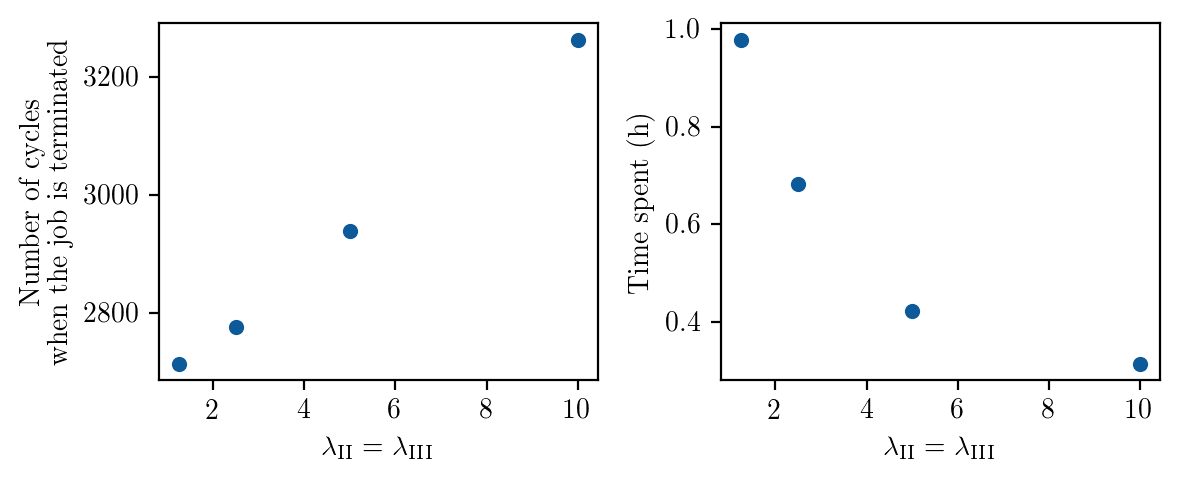

In [72]:
plot_one_scheme("output/monitor-log-JonasCTParis100JonasCLA1st-2025-05-18-20-46-42.txt", "auto-program-test-jonascla.pdf")
plt.show()
plt.close()

[10.0, 5.0, 2.5] [2966, 2791, 2699] 1.4352250393893984


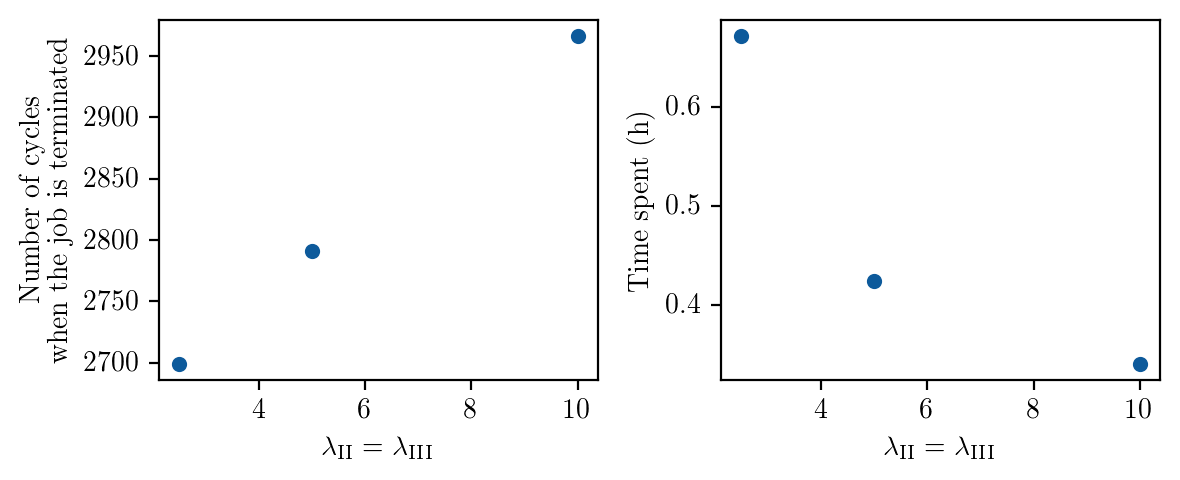

In [71]:
plot_one_scheme("output/monitor-log-JonasCTParis100Jonas1st-2025-05-18-13-21-49.txt", "auto-program-test-jonas.pdf")
plt.show()
plt.close()

[266.0, 133.0, 66.0] [1331, 2528, 2641] 0.34940125306447345


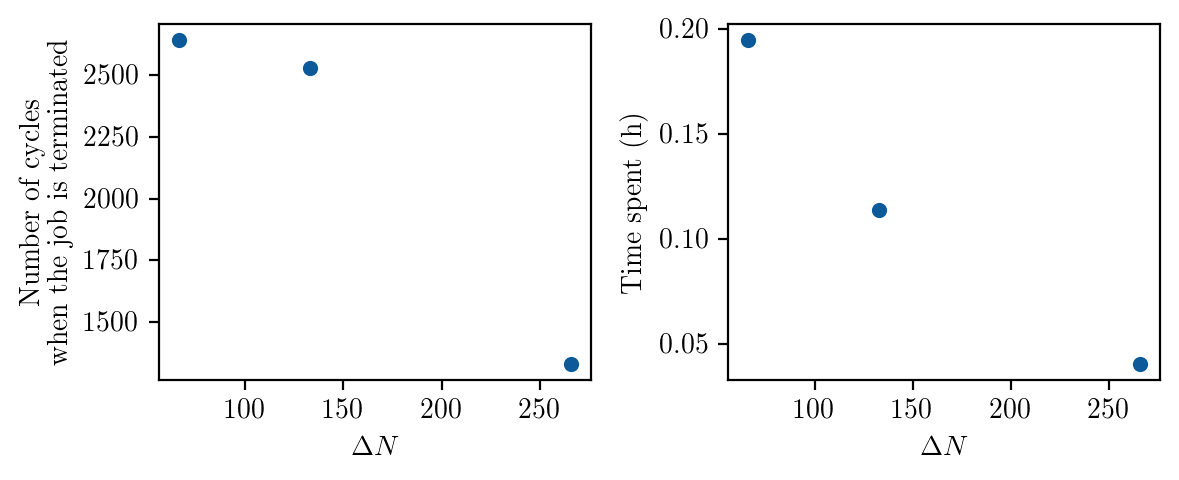

In [67]:
plot_one_scheme("output/monitor-log-JonasCTParis100CLA1st-2025-05-18-11-34-37.txt", "auto-program-test-cla.pdf")
plt.show()
plt.close()

[1.0, 0.5, 0.25, 0.125, 0.0625, 0.03125, 0.015625, 0.0078125, 0.00390625, 0.001953125] [8297, 7657, 6055, 5119, 4386, 3758, 3317, 2963, 2777, 2702] 4.584388327863481


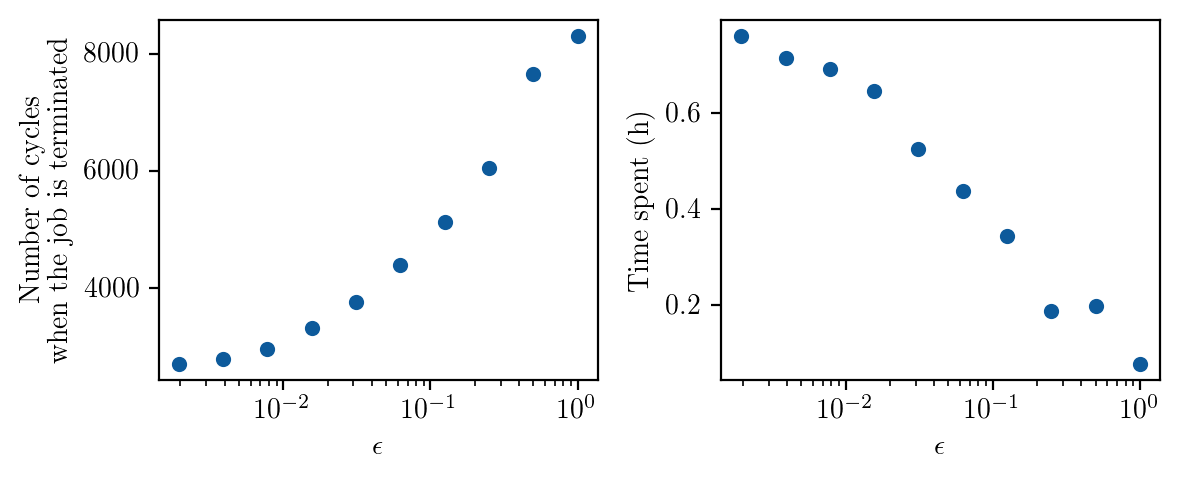

In [70]:
plot_one_scheme("output/monitor-log-JonasCTParis100Yang1st-2025-05-18-20-47-14.txt", "auto-program-test-yang.pdf", log_x=True)
plt.show()
plt.close()

[1330.0, 665.0, 332.0, 166.0] [6133, 3232, 2952, 2837] 0.8091386402315563


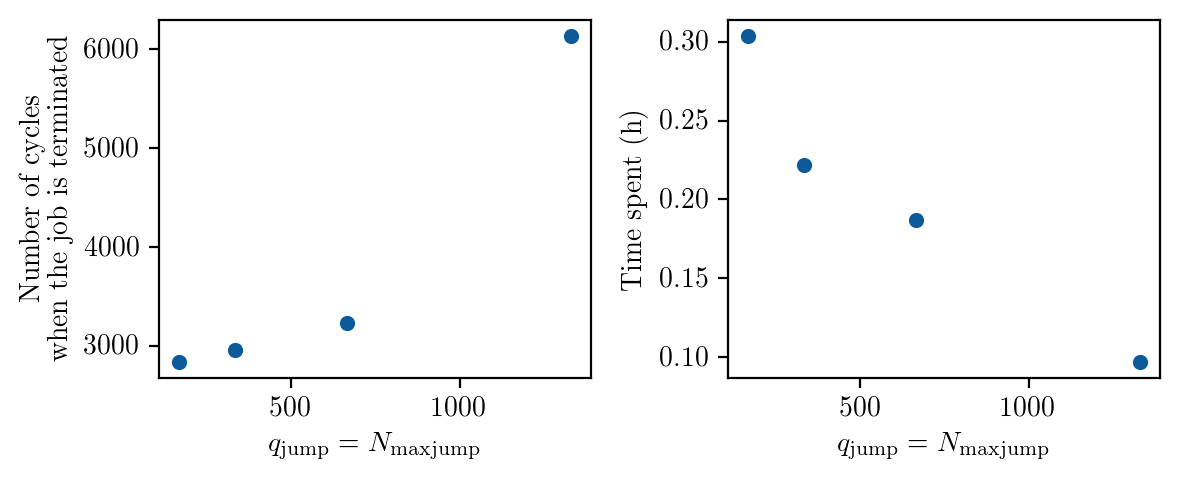

In [68]:
plot_one_scheme("output/monitor-log-JonasCTParis100Cojocaru1st-2025-05-18-20-47-49.txt", "auto-program-test-cojocaru.pdf")
plt.show()
plt.close()

[1330.0, 665.0, 332.0, 166.0] [5131, 3377, 3037, 2891] 0.6124948100911246


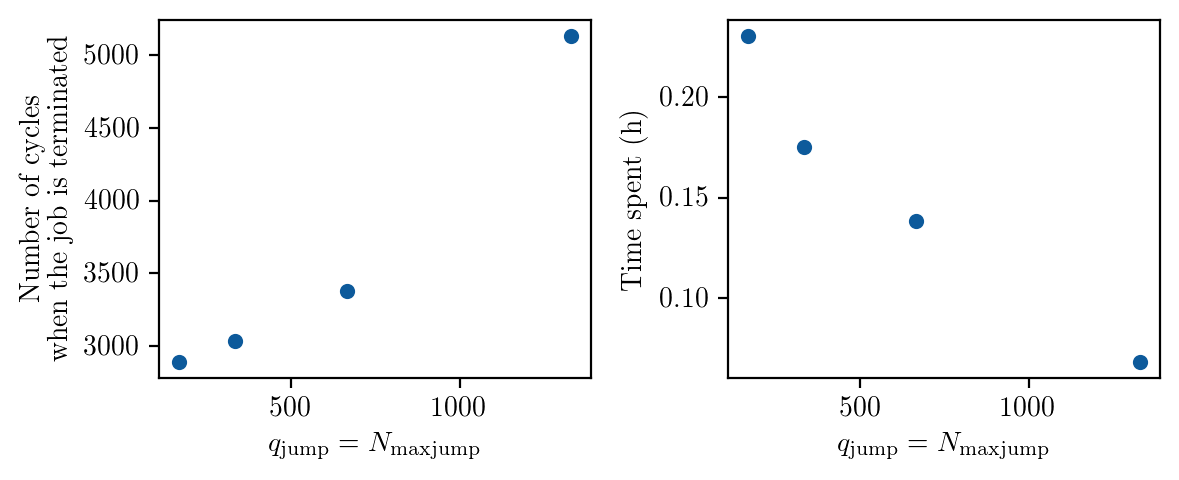

In [69]:
plot_one_scheme("output/monitor-log-JonasCTParis100CojocaruCLA1st-2025-05-18-20-48-28.txt", "auto-program-test-cojocarucla.pdf")
plt.show()
plt.close()

[266.0, 133.0, 66.0, 33.0, 16.0, 8.0] [533, 1464, 2179, 2509, 2753, 2737] 12.451203348702855


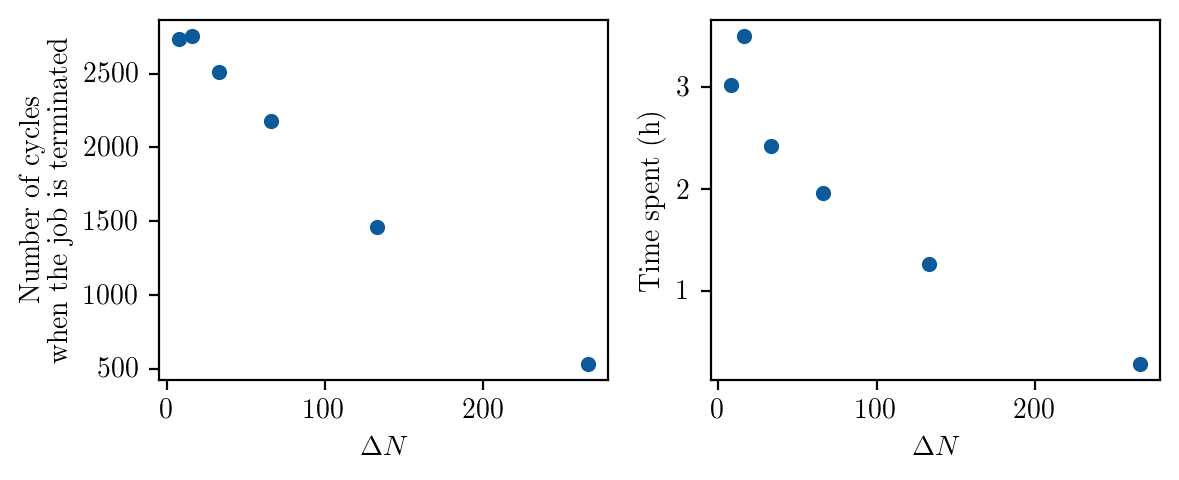

In [73]:
plot_one_scheme("output/monitor-log-JonasCTParis100Jaccon1st-2025-05-18-11-33-38.txt", "auto-program-test-jaccon.pdf")
plt.show()
plt.close()